In [1]:
import os
import json
import baltic as bt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta, date
from collections import OrderedDict
import numpy as np
import matplotlib.lines as mlines
import plotly.express as px
from matplotlib.ticker import ScalarFormatter
from collections import defaultdict, Counter

In [2]:
#todays date for exporting with date tag
todays_date = str(date.today())
print(todays_date)

2026-06-30


In [3]:
def extract_subtrees(tree, traitName):
    
    tree_strings = defaultdict(list)
    subtype_trees = defaultdict(list)
    transitions = Counter()

    for t in tree.Objects:  # Iterate over branches
        k = t  # branch
        kp = t.parent  # branch's parent

        # Get current node's and its parent's trait states
        kloc = k.traits.get(traitName, 'ancestor')
        kploc = kp.traits.get(traitName, 'ancestor')
        kc = kloc  # Current branch trait value
        kpc = kploc  # Parent branch trait value
        # kconf = float(k.traits[traitName]["confidence"][kloc])
        # kpconf = float(kp.traits[traitName]["confidence"][kploc])
        # print(kconf, kpconf)

        # Debug: print current and parent trait states
        # print(f"Node: {k} - Trait: {kc} | Parent: {kp} - Trait: {kpc}")

        # Count transitions
        if kpc != kc:
            transitions[(kpc, kc)] += 1
            # print(f"Transition detected: {kpc} -> {kc}")

        # If states do not match, extract subtree
        if kc != kpc:
            traverse_condition = lambda w: w.traits.get(traitName, 'ancestor') == kc
            subtree = tree.subtree(k, traverse_condition=traverse_condition)
            
            if subtree:
                # print(f"Subtree extracted for transition: {kpc} -> {kc}")
                subtree.traverse_tree()  
                subtree.sortBranches()
                tree_strings[kc].append(subtree.toString())
                subtype_trees[kc].append((kpc, subtree))
            else:
                print(f"Subtree extraction failed for {kpc} -> {kc}")
                print(kc, k.traits)
                print(kpc, kp.traits) 
                print(len(k.leaves), len(kp.leaves))
                print(k.leaves)

    # # Debug: Print final structures
    # print(f"Tree Strings: {dict(tree_strings)}")
    # print(f"Subtype Trees: {dict(subtype_trees)}")
    # print(f"Transitions: {dict(transitions)}")

    return tree_strings, subtype_trees, dict(transitions)

In [4]:
def subtree_to_dataframe_with_origin(subtype_trees, traitName):
    # List to hold all subtree data
    all_subtree_data = []

    # Iterate over each subtype and its associated subtrees
    for subtype, subtree_list in subtype_trees.items():
        for i, (origin, subtree) in enumerate(subtree_list):
            # Extract the origin date, assuming it's the root's absoluteTime minus its length
            origin_date = subtree.root.absoluteTime - subtree.root.length
            
            # Iterate through nodes in the subtree
            for node in subtree.Objects:
                # Collect relevant information from each node
                node_info = {
                    'branchType': node.branchType,  # 'leaf' or 'internal'
                    'absoluteTime': node.absoluteTime,
                    'length': node.length,
                    'origin': origin,  # Include the origin trait
                    'origin_date': origin_date,  # Add the origin date here
                    'subtree_name': f"{subtype}_{i}",  # Unique name for the subtree
                    'traits': node.traits  # This is a dictionary; we can expand it later if needed
                }
                
                # Expand the traits dictionary into individual columns
                for trait, value in node.traits.items():
                    node_info[trait] = value  # Each trait becomes its own column

                # Add this node's information to the list
                all_subtree_data.append(node_info)
    
    # Convert the list of dictionaries into a DataFrame
    df = pd.DataFrame(all_subtree_data)
    
    # Drop the node_attrs column if it exists (assuming it may not be needed)
    if 'node_attrs' in df.columns:
        df.drop(columns=['node_attrs', 'traits'], inplace=True)

    return df

In [5]:
def make_subtree_df(combined_df):
    # Function to convert decimal year to date
    def decimal_year_to_date(decimal_year):
        year = int(decimal_year)
        decimal_part = decimal_year - year
        days_in_year = 365.25  # Average including leap years
        day_of_year = int(decimal_part * days_in_year)
        return datetime(year, 1, 1) + timedelta(days=day_of_year)

    # Make a new DataFrame that pulls out only leaf nodes and groups by subtree_name
    tip_counts = combined_df[combined_df['branchType'] == 'leaf'].groupby('subtree_name').size().reset_index(name='leaf_count')

    # Make separate sub DataFrame that pulls out the origin date, origin, and trait of tips of each subtree
    origin_info = combined_df[['subtree_name', 'origin_date', 'origin', 'pa_status', 'wild_dom_lbm', 'border_state', 'source_tree']].drop_duplicates()

    # Merge origin sub DataFrame into tip_counts
    tip_counts = pd.merge(tip_counts, origin_info, on='subtree_name')

    # Filter to only include leaf nodes
    leaf_nodes = combined_df[combined_df['branchType'] == 'leaf']

    # Group by 'subtree_name' and get the max absoluteTime for each subtree
    last_tip_dates = leaf_nodes.groupby('subtree_name')['absoluteTime'].max().reset_index()

    # Rename the column to 'last_tip_date'
    last_tip_dates.rename(columns={'absoluteTime': 'last_tip_date'}, inplace=True)

    # Merge more recent tip dates into the tip_counts sub DataFrame
    tip_counts = tip_counts.merge(last_tip_dates, on='subtree_name', how='left')

    # Convert origin_date and last_tip_date to datetime
    tip_counts['origin_date'] = tip_counts['origin_date'].apply(decimal_year_to_date)
    tip_counts['last_tip_date'] = tip_counts['last_tip_date'].apply(decimal_year_to_date)

    # Now calculate and add persistence times in days
    tip_counts['subtree_duration_days'] = (tip_counts['last_tip_date'] - tip_counts['origin_date']).dt.days

    # Round the persistence times
    tip_counts['subtree_duration_days'] = tip_counts['subtree_duration_days'].round(1)

    # Return the final DataFrame
    return tip_counts

In [6]:
def get_transitions_df(transitions):
    # Prepare lists to store transitions and their counts
    transition_list = []
    counts_list = []

    # Loop through the transitions dictionary
    for (from_state, to_state), count in transitions.items():
        transition_list.append(f"{from_state}_{to_state}")  # Format as From_To
        counts_list.append(count)  # Get the corresponding count

    # Create a DataFrame
    transitions_df = pd.DataFrame({
        'Transition': transition_list,
        'Count': counts_list
    })

    transitions_df['source_tree'] = treename

    return transitions_df

In [43]:
#define key things- tree_path and traitName will need to be configured
# folder_path = '/Users/asjaeger/Desktop/project_source/hpai-PA/phylo/2026-04-03_largeNorthAm_withPA_wild25/auspice/json_parse'
# folder_path = '../phylo/2026-05-28_largeNorthAm_withPA_wild25_rmdupes/auspice/json_for_parse'
folder_path = '../../phylo/2026-06-11_largeNorthAm_withPA_wild25_rmdupes_rerun/auspice/json_parse'

traitName = "border_state"

all_trees = {}

# Initialize lists to hold all DataFrames and tip counts and transitions
combined_dfs = []
tip_counts_dfs = []
all_transitions_dfs = []


# Loop through each JSON file in the specified folder
for filename in os.listdir(folder_path):
    if filename.endswith('.json'):
        tree_path = os.path.join(folder_path, filename)  # Create full path to the JSON file
        treename = filename.replace('.json', '')  # Extract the name without extension
        
        try:
            json_translation={'absoluteTime':lambda k: k.traits['node_attrs']['num_date']['value'],'name':'name'} ## allows baltic to find correct attributes in JSON, height and name are required at a minimum
            branchWidth=2
    
            # Load the tree
            tree, meta = bt.loadJSON(tree_path, json_translation=json_translation)
            
            # Call the extract_subtrees function
            tree_strings, subtype_trees, transitions = extract_subtrees(tree, traitName)

            # Store the subtype trees in the all_trees dictionary using the tree name as the key
            all_trees[treename] = subtype_trees
            
            # Convert subtype_trees to a DataFrame
            subtree_df = subtree_to_dataframe_with_origin(subtype_trees, traitName)
            
            # Optionally add a column to identify the source tree
            subtree_df['source_tree'] = treename
            
            # Call the make_subtree_df function to get the final DataFrame for this tree
            tip_counts_df = make_subtree_df(subtree_df)
            
            # Append the resulting DataFrame to the respective lists
            combined_dfs.append(subtree_df)
            tip_counts_dfs.append(tip_counts_df)
            
            # Process transitions for the current tree
            transitions_df = get_transitions_df(transitions)
            all_transitions_dfs.append(transitions_df)  # Append to the list

            print(f"Successfully processed tree: {treename}")

        except Exception as e:
            print(f"Failed to load tree from {tree_path}: {e}")

# Concatenate all DataFrames into one combined DataFrame
combined_df = pd.concat(combined_dfs, ignore_index=True)
combined_tip_counts_df = pd.concat(tip_counts_dfs, ignore_index=True)
combined_transitions_df = pd.concat(all_transitions_dfs, ignore_index=True)


# Optionally, display the first few rows of the combined DataFrames
print("Combined DataFrame:")
print(combined_df.head())

print("\nCombined Tip Counts DataFrame:")
print(combined_tip_counts_df.head())

print("\nCombined Transitions DataFrame:")
print(combined_transitions_df.head())


Tree height: 26.917000
Tree length: 1474.269000
annotations present

Numbers of objects in tree: 11458 (4823 nodes and 6635 leaves)

Successfully processed tree: h5nx_pa

Tree height: 14.464000
Tree length: 1538.558000
annotations present

Numbers of objects in tree: 11808 (5147 nodes and 6661 leaves)

Successfully processed tree: h5nx_ns

Tree height: 17.031000
Tree length: 1712.230000
annotations present

Numbers of objects in tree: 11545 (4952 nodes and 6593 leaves)

Successfully processed tree: h5nx_pb1

Tree height: 146.085000
Tree length: 1606.824000
annotations present

Numbers of objects in tree: 11721 (5068 nodes and 6653 leaves)

Successfully processed tree: h5nx_na

Tree height: 4.067000
Tree length: 1270.336000
annotations present

Numbers of objects in tree: 11749 (5083 nodes and 6666 leaves)

Successfully processed tree: h5nx_ha

Tree height: 4.948000
Tree length: 2393.456000
annotations present

Numbers of objects in tree: 12193 (5523 nodes and 6670 leaves)

Successfull

In [ ]:
all_trees

In [44]:
combined_tip_counts_df.head(25)

,subtree_name,leaf_count,origin_date,origin,pa_status,wild_dom_lbm,border_state,source_tree,last_tip_date,subtree_duration_days
0,PA_0,2,2023-08-16,non-border,Pennsylvania,domestic,PA,h5nx_pa,2024-02-03,171
1,PA_1,1,2023-09-18,non-border,Pennsylvania,NaN,PA,h5nx_pa,2023-12-21,94
2,PA_10,4,2024-10-17,border,Pennsylvania,domestic,PA,h5nx_pa,2025-03-11,145
3,PA_10,4,2024-10-17,border,Pennsylvania,lbm,PA,h5nx_pa,2025-03-11,145
4,PA_11,8,2024-10-17,border,Pennsylvania,NaN,PA,h5nx_pa,2025-03-24,158
5,PA_11,8,2024-10-17,border,Pennsylvania,wild,PA,h5nx_pa,2025-03-24,158
6,PA_11,8,2024-10-17,border,Pennsylvania,lbm,PA,h5nx_pa,2025-03-24,158
7,PA_12,1,2024-10-23,border,Pennsylvania,lbm,PA,h5nx_pa,2025-03-11,139
8,PA_13,2,2024-12-27,border,Pennsylvania,lbm,PA,h5nx_pa,2025-03-10,73
9,PA_14,3,2025-01-24,border,Pennsylvania,domestic,PA,h5nx_pa,2025-03-16,51


In [45]:
combined_transitions_df.head(20)

,Transition,Count,source_tree
0,ancestor_non-border,1,h5nx_pa
1,non-border_border,131,h5nx_pa
2,non-border_PA,43,h5nx_pa
3,border_PA,34,h5nx_pa
4,PA_border,8,h5nx_pa
5,border_non-border,66,h5nx_pa
6,PA_non-border,2,h5nx_pa
7,ancestor_non-border,1,h5nx_ns
8,non-border_border,144,h5nx_ns
9,non-border_PA,37,h5nx_ns


In [46]:
# #for exporting dfs to csvs
# folder_path = folder_path.replace('/', '_')
# folder_path = 'larger_delta'
# combined_df.to_csv(f"../phylo_scripts_analysis/output_dfs/subtree_df1_{traitName}_{todays_date}.csv", index=False)
# combined_tip_counts_df.to_csv(f"../phylo_scripts_analysis/output_dfs/subtree_df2_{traitName}_{todays_date}.csv", index=False)
# combined_transitions_df.to_csv(f"../phylo_scripts_analysis/output_dfs/transitions_df_{traitName}_{todays_date}.csv", index=False)
combined_df.to_csv(f"../output_dfs/subtree_df1_{traitName}_{todays_date}.csv", index=False)
combined_tip_counts_df.to_csv(f"../output_dfs/subtree_df2_{traitName}_{todays_date}.csv", index=False)
combined_transitions_df.to_csv(f"../output_dfs/transitions_df_{traitName}_{todays_date}.csv", index=False)

In [142]:
# def plot_clusters_over_time(combined_tip_counts_df):
#     """
#     Plot leaf counts over time, colored by Urban/Rural classification.

#     Parameters:
#     - tip_counts: DataFrame containing 'origin_date', 'leaf_count', 
#                   and 'Urban_or_Rural_Classification'.
#     - title: Title of the plot.
#     - x_label: Label for the X-axis.
#     - y_label: Label for the Y-axis.
#     - fig_size: Size of the figure.
#     - palette: Custom color palette for the classifications.
#     """
    
#     # # Filter the DataFrame to exclude non-Wisconsin
#     # filtered_tip_counts = combined_tip_counts_df[combined_tip_counts_df[traitName] != 'non-Wisconsin']
#     filtered_tip_counts = combined_tip_counts_df[combined_tip_counts_df['origin'] != 'ancestor']


#     # Set default color palette if not provideda
#     palette = {
#         'Pennsylvania': 'hotpink',
#         'non_PA': 'cornflowerblue'
#     }
#     # palette = {
#     #     'PA': 'hotpink',
#     #     'border': 'cornflowerblue',
#     #     'non-border': 'goldenrod'
#     # }
    
#     # Calculate x-axis limits based on data range in 'origin_date'
#     x_min = filtered_tip_counts['origin_date'].min()
#     x_max = filtered_tip_counts['origin_date'].max()
#     padding = (x_max - x_min) * 0.05  # Add 5% padding on each side
#     x_limits = (x_min - padding, x_max + padding)
    
#     # Create the plot
#     plt.figure(figsize=(10, 6))
#     sns.scatterplot(
#         data=filtered_tip_counts,
#         x='origin_date',
#         y='leaf_count',
#         hue='pa_status',
#         palette=palette,
#         s=75,  # Marker size
#         edgecolor='w'
#     )
    
#     # Customize the plot
#     plt.title('Cluster size overtime for ' + str(treename))
#     plt.xlabel('Cluster Origin Date')
#     plt.ylabel('Cluster Size')
#     # plt.yscale('log')
#     plt.xlim(x_limits)  # Set x-axis limits based on data range
#     plt.legend(title='Trait')
#     plt.grid(True)

#     # output_filename = "output/clusters_over_time_" + treename + "_" + todays_date + ".png"
#     output_filename = "output/clusters_over_time_wistatus_" + treename + "_" + todays_date + ".png"

#     # plt.savefig(output_filename, format='png')  # Save plot to 'output' folder
    
#     # Show the plot
#     plt.show()

In [108]:
# def plot_persistence_boxplots(combined_tip_counts_df, trait_column=traitName, fig_size=(10, 6)):
#     """
#     Plots box plots of persistence time grouped by trait with individual points.

#     Parameters:
#     - tip_counts: DataFrame containing the 'subtree_duration_days' and the trait column.
#     - trait_column: The column name in tip_counts representing the trait (e.g., 'Urban_or_Rural_USDA_Classification').
#     - fig_size: Tuple defining the size of the figure.
#     """
#     # filtered_tip_counts = combined_tip_counts_df[combined_tip_counts_df[traitName] != 'non-Wisconsin']
#     filtered_tip_counts = combined_tip_counts_df[combined_tip_counts_df['origin'] != 'ancestor']

#     # Initialize the plot
#     plt.figure(figsize=fig_size)
    
#     # Create the box plot with individual points overlaid
#     sns.boxplot(x=trait_column, y="subtree_duration_days", data=combined_tip_counts_df, hue='source_tree', palette="Set2", showfliers=False)
#     sns.stripplot(data=filtered_tip_counts, x="pa_status", y='subtree_duration_days', color='black', jitter=True, alpha=0.5)

  
#     # Set labels and title
#     plt.xlabel('Trait')
#     plt.ylabel('Cluster Persistence Time (Days)')
#     plt.title('Persistence Time by Trait for ' + str(treename))
#     # Show the plot
#     plt.tight_layout()

#     # output_filename = "output/persistence_boxplot_urbrur_" + treename + "_" + todays_date + ".png"
#     output_filename = "output/persistence_boxplot_wistatus_" + treename + "_" + todays_date + ".png"

#     # plt.savefig(output_filename, format='png')  # Save plot to 'output' folder
    
#     plt.show()

Generating plots for h5nx_ha...


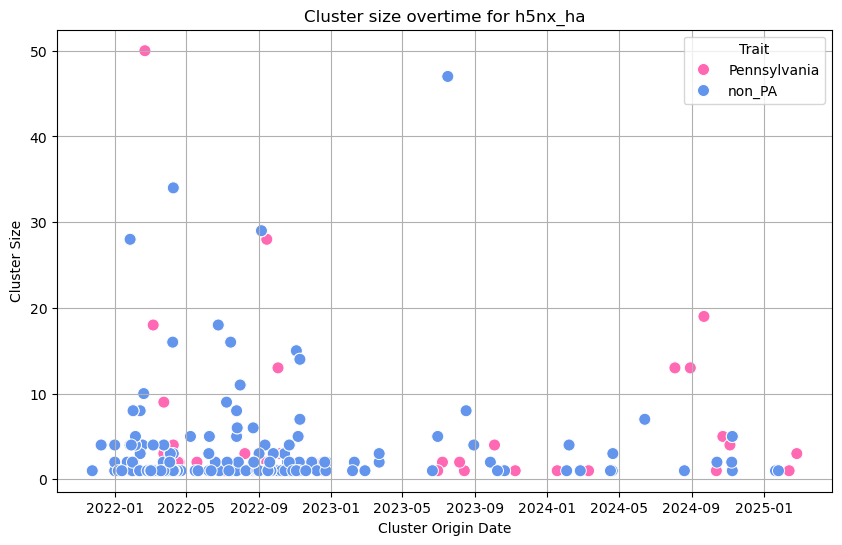

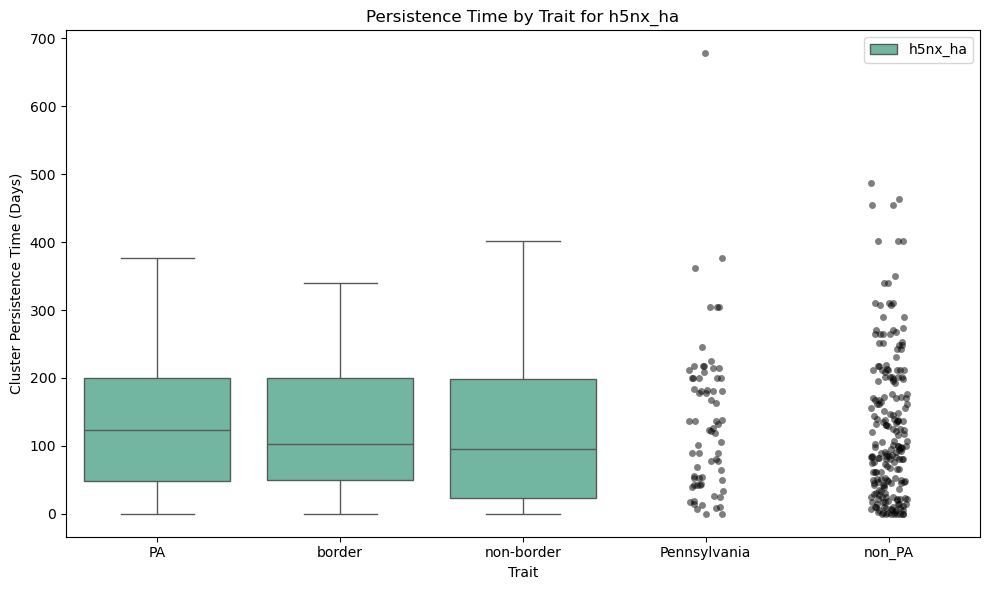

Generating plots for mini_ha...


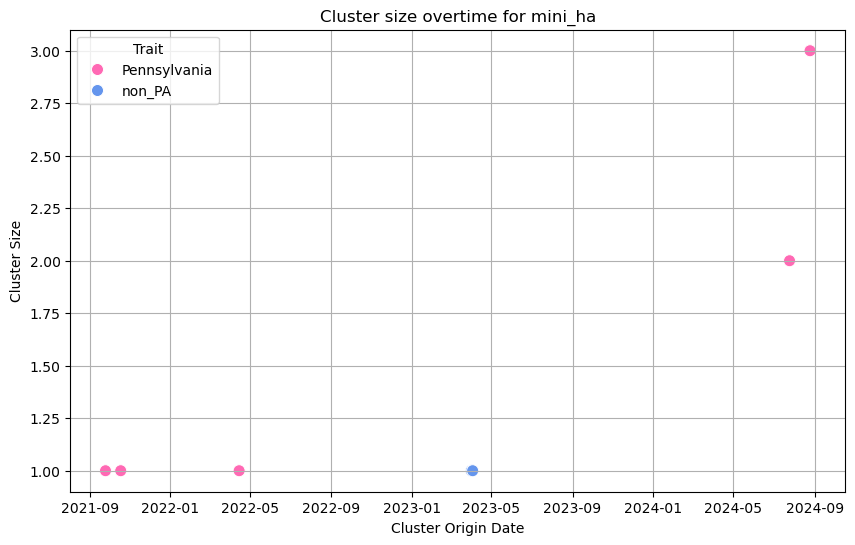

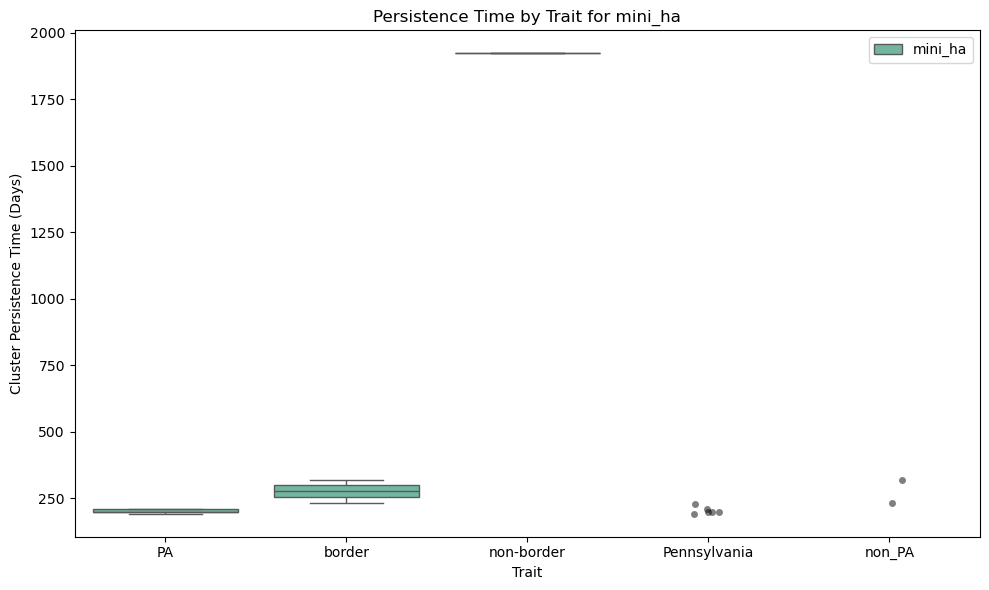

In [109]:
# # Set today's date for file naming
# todays_date = str(date.today())

# # Loop through each unique source_tree in combined_tip_counts_df and plot
# for tree_name in combined_tip_counts_df['source_tree'].unique():
#     # Filter the DataFrame for the current source_tree
#     tree_tip_counts = combined_tip_counts_df[combined_tip_counts_df['source_tree'] == tree_name]
    
#     # Set the global tree name variable for plot titles
#     treename = tree_name  # Used in plot title and file saving

#     print(f"Generating plots for {tree_name}...")

#     # Plot clusters over time
#     plot_clusters_over_time(tree_tip_counts)
    
#     # Plot persistence boxplots
#     plot_persistence_boxplots(tree_tip_counts, trait_column=traitName)


In [110]:
# def plot_tree(subtype_trees, traitName, tree, 
#               tip_size=15, fig_size=(10, 10), legend_loc='lower left'):
   
#     # Define color scheme for traits
#     # colors = {
#     #     'PA': 'hotpink',
#     #     'non-PA': 'cornflowerblue'
#     # }
    
#     palette = {
#         'PA': 'hotpink',
#         'border': 'cornflowerblue',
#         'non-border': 'goldenrod'
#     }
    
#     # Color function based on traits
#     c_func = lambda k: palette.get(k.traits[traitName], 'whitesmoke')
    
#     # Initialize figure and cumulative y offset
#     fig = plt.figure(figsize=fig_size, facecolor='w')
#     gs = gridspec.GridSpec(1, 1, wspace=0.0)
#     ax = plt.subplot(gs[0], facecolor='w')
#     cumulative_y = 0

#     # Iterate over each trait and its subtrees
#     for subtype in palette.keys():
#         for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
#             origin, loc_tree = tr
            
#             # # Skip plotting subtrees with origin "ancestor"
#             # if origin == "ancestor":
#             #     continue
#             # Get trait of the subtree's root
#             subtree_trait = loc_tree.root.traits.get(traitName)
            
#             # Skip unwanted origin/trait pairs
#             unwanted_pairs = {('non-border', 'border'), ('border', 'non-border')}
#             if origin == "ancestor" or (origin, subtree_trait) in unwanted_pairs:
#                 continue
            
#             y_attr = lambda k: k.y + cumulative_y  # Update y-attribute with cumulative offset
            
#             # Plot the subtree branches and tips
#             loc_tree.plotTree(ax, x_attr=lambda k: k.absoluteTime, y_attr=y_attr, colour=c_func)
#             loc_tree.plotPoints(ax, x_attr=lambda k: k.absoluteTime, y_attr=y_attr, size=tip_size, colour=c_func, zorder=100)
            
#             # Origin point for each subtree
#             oriC = c_func(loc_tree.root.parent)
#             oriX = loc_tree.root.absoluteTime - loc_tree.root.length
#             oriY = loc_tree.root.y + cumulative_y
#             ax.scatter(oriX, oriY, 50, facecolor=oriC, edgecolor='w', lw=1, zorder=200)  # Origin circle
            
#             cumulative_y += loc_tree.ySpan + 5  # Update cumulative y for next subtree

#     # Axis and plot styling
#     ax.xaxis.tick_bottom()
#     ax.yaxis.tick_left()
#     [ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left']]
#     ax.tick_params(axis='x', size=0, labelsize=15)
#     ax.tick_params(axis='y', size=0)
#     ax.grid(axis='x', ls='--')
    
#     # Set y-axis limits and remove labels
#     ax.set_yticklabels([])
#     ax.set_ylim(-15, cumulative_y + 15)
#     # Determine the min and max dates in the tree
#     min_date = min(node.absoluteTime for node in tree.Objects)
#     max_date = max(node.absoluteTime for node in tree.Objects)
    
#     # Set x-axis limits with some padding
#     padding = 0.5  # Adjust padding as desired
#     ax.set_xlim(min_date, max_date + padding)    
#     # Legend setup
#     handles = [
#         plt.Line2D([0], [0], marker='o', color='w', label=label,
#                    markersize=10, markerfacecolor=color)
#         for label, color in palette.items()
#     ]
#     plt.legend(handles=handles, title='Traits', loc=legend_loc)
    
#     # Adjust layout and show plot
#     plt.gcf().subplots_adjust(right=0.88)
#     plt.title(treename + "_" + todays_date)
#     output_filename = "../phylo_scripts_analysis/output_figs/subtree_plots_" + str(treename) + "_" + todays_date + ".png"
#     output_filename = "subtree_plots_" + str(treename) + "_" + todays_date + ".png"

#     # plt.savefig(output_filename, format='png')
#     plt.show()


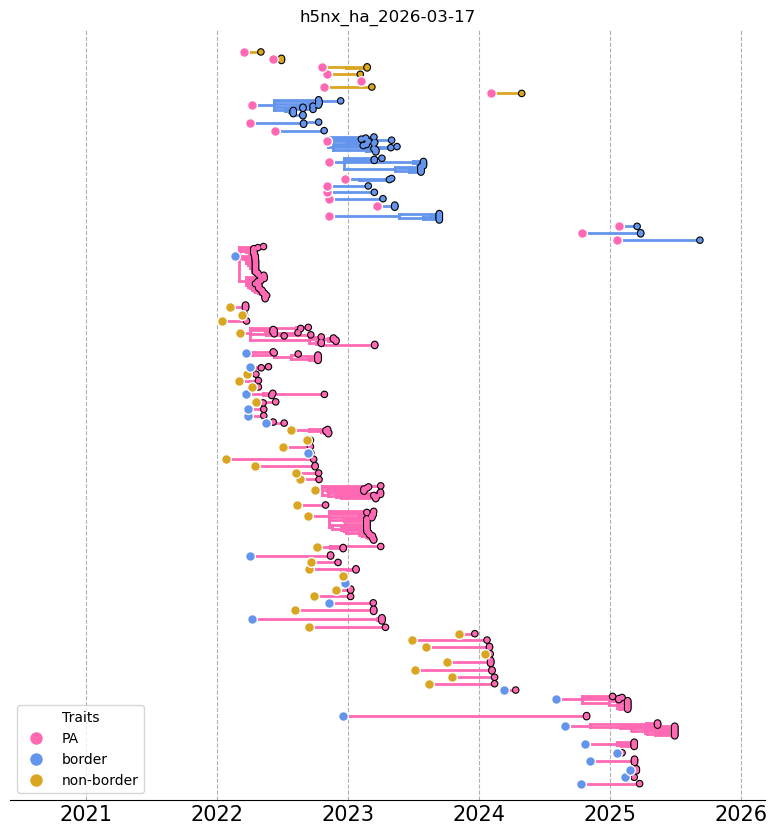

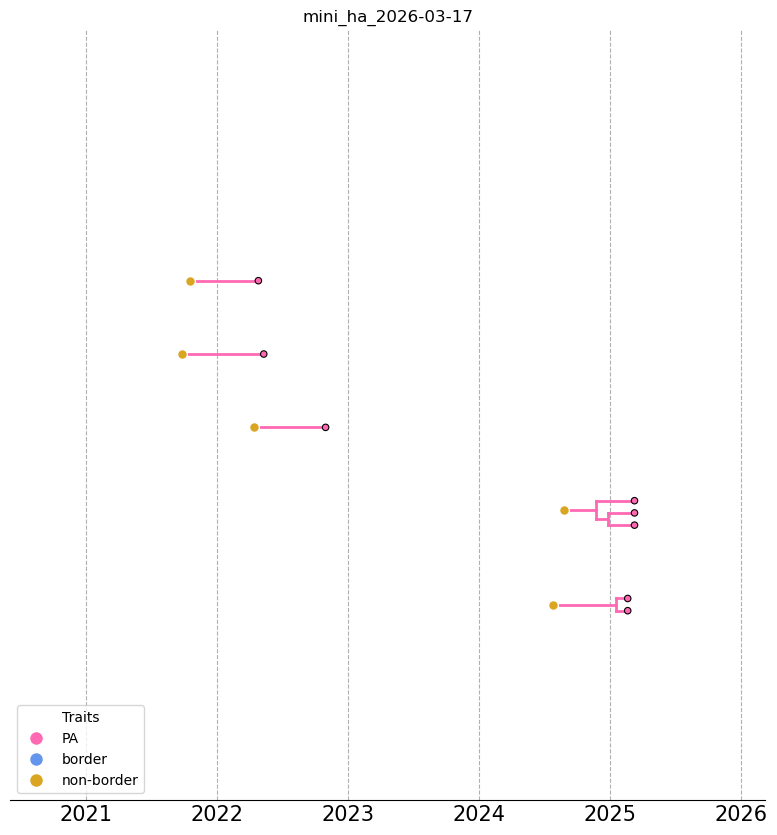

In [111]:
# # Execute plotting for each tree
# for treename, subtype_trees in all_trees.items():
#     plot_tree(subtype_trees, traitName, tree)  # Pass the tree if needed


AttributeError: 'leaf' object has no attribute 'leaf'

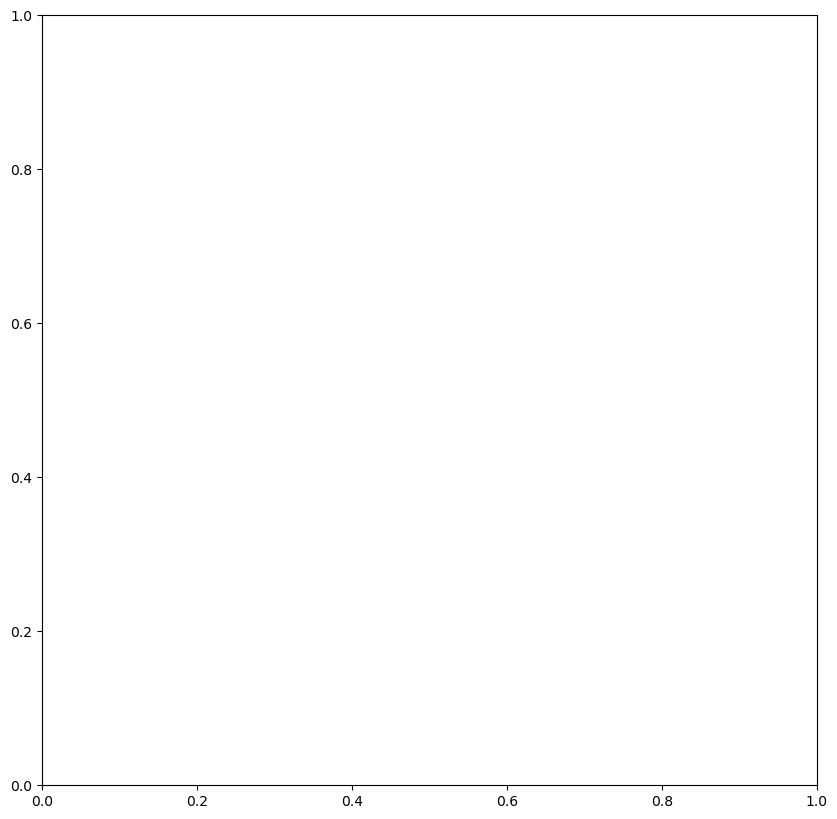

In [83]:
# def plot_tree(subtype_trees, traitName, tree, 
#               tip_size=15, fig_size=(10, 10), legend_loc='lower left'):
   
#     # Define color scheme for traits
#     # colors = {
#     #     'PA': 'hotpink',
#     #     'non-PA': 'cornflowerblue'
#     # }

#     shape_map = {
#     'wild': 'o',     # circle
#     'domestic': '^',   # triangle
#     'unknown': 's',      # square
#     # Add or adjust as needed
# }

    
#     palette = {
#         'PA': 'hotpink',
#         'border': 'cornflowerblue',
#         'non-border': 'goldenrod'
#     }
    
#     # Color function based on traits
#     c_func = lambda k: palette.get(k.traits[traitName], 'whitesmoke')
    
#     # Initialize figure and cumulative y offset
#     fig = plt.figure(figsize=fig_size, facecolor='w')
#     gs = gridspec.GridSpec(1, 1, wspace=0.0)
#     ax = plt.subplot(gs[0], facecolor='w')
#     cumulative_y = 0

#     # Iterate over each trait and its subtrees
#     for subtype in palette.keys():
#         for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
#             origin, loc_tree = tr
            
#             # # Skip plotting subtrees with origin "ancestor"
#             # if origin == "ancestor":
#             #     continue
#             # Get trait of the subtree's root
#             subtree_trait = loc_tree.root.traits.get(traitName)
            
#             # Skip unwanted origin/trait pairs
#             unwanted_pairs = {('non-border', 'border'), ('border', 'non-border')}
#             if origin == "ancestor" or (origin, subtree_trait) in unwanted_pairs:
#                 continue
            
#             y_attr = lambda k: k.y + cumulative_y  # Update y-attribute with cumulative offset
            
#             # Plot the subtree branches and tips
#             loc_tree.plotTree(ax, x_attr=lambda k: k.absoluteTime, y_attr=y_attr, colour=c_func)
#             # loc_tree.plotPoints(ax, x_attr=lambda k: k.absoluteTime, y_attr=y_attr, size=tip_size, colour=c_func, zorder=100)
#             for node in loc_tree.Objects:
#                 if node.leaf:  # This is a tip node
#                     x = node.absoluteTime
#                     y = y_attr(node)
#                     color = c_func(node)
#                     dom_stat = node.traits.get('dom_stat', 'unknown')
#                     marker = shape_map.get(dom_stat, 'X')  # default shape if unknown
#                     ax.scatter(x, y, s=tip_size, c=color, marker=marker,
#                                edgecolor='k', linewidth=0.5, zorder=100)

            
#             # Origin point for each subtree
#             oriC = c_func(loc_tree.root.parent)
#             oriX = loc_tree.root.absoluteTime - loc_tree.root.length
#             oriY = loc_tree.root.y + cumulative_y
#             ax.scatter(oriX, oriY, 50, facecolor=oriC, edgecolor='w', lw=1, zorder=200)  # Origin circle
            
#             cumulative_y += loc_tree.ySpan + 5  # Update cumulative y for next subtree

#     # Axis and plot styling
#     ax.xaxis.tick_bottom()
#     ax.yaxis.tick_left()
#     [ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left']]
#     ax.tick_params(axis='x', size=0, labelsize=15)
#     ax.tick_params(axis='y', size=0)
#     ax.grid(axis='x', ls='--')
    
#     # Set y-axis limits and remove labels
#     ax.set_yticklabels([])
#     ax.set_ylim(-15, cumulative_y + 15)
#     # Determine the min and max dates in the tree
#     min_date = min(node.absoluteTime for node in tree.Objects)
#     max_date = max(node.absoluteTime for node in tree.Objects)
    
#     # Set x-axis limits with some padding
#     padding = 0.5  # Adjust padding as desired
#     ax.set_xlim(min_date, max_date + padding)    
#     # Legend setup
#     handles = [
#         plt.Line2D([0], [0], marker='o', color='w', label=label,
#                    markersize=10, markerfacecolor=color)
#         for label, color in palette.items()
#     ]
#     plt.legend(handles=handles, title='Traits', loc=legend_loc)
    
#     # Adjust layout and show plot
#     plt.gcf().subplots_adjust(right=0.88)
#     plt.title(treename + "_" + todays_date)
#     output_filename = "../analysis_phylo/subtree_plots_" + str(treename) + "_" + todays_date + ".png"
#     output_filename = "subtree_plots_" + str(treename) + "_" + todays_date + ".png"

#     # plt.savefig(output_filename, format='png')
#     plt.show()
# # Execute plotting for each tree
# for treename, subtype_trees in all_trees.items():
#     plot_tree(subtype_trees, traitName, tree)  # Pass the tree if needed

In [9]:
# Path to the folder containing JSON files
# folder_path = '../phylo/ha_for_parse/update' #check for end backslash- will mess up folderpath in filenames!
# folder_path = '../../phylo/2026-05-18_largeNorthAm_withPA_wild25_minifortest/auspice/json_parse'
# folder_path = '../phylo/2026-05-28_largeNorthAm_withPA_wild25_rmdupes/auspice/json_for_parse'
# folder_path = '../../phylo/2026-06-11_largeNorthAm_withPA_wild25_rmdupes_rerun/auspice/json_parse'
folder_path = '../phylo/2026-06-11_largeNorthAm_withPA_wild25_rmdupes_rerun/auspice/json_parse/two_trees'


# Function to extract the relevant part of the filename
def extract_tree_name(filename):
    return filename.replace('ncov_', '').replace('.json', '')

# JSON translation dictionary
json_translation = {
    'absoluteTime': lambda k: k.traits['node_attrs']['num_date']['value'],
    'name': 'name'
}

# Dictionary to store trees
trees = {}

# Loop through all JSON files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith('.json'):
        # Construct the full path to the JSON file
        json_path = os.path.join(folder_path, filename)
        
        # Load the JSON file and create the tree
        tree_name = 'tree' + extract_tree_name(filename)
        tree, meta = bt.loadJSON(json_path, json_translation=json_translation)
        
        # Store the tree in the dictionary
        trees[tree_name] = tree
        trees = OrderedDict(sorted(trees.items()))


Tree height: 4.067000
Tree length: 1270.336000
annotations present

Numbers of objects in tree: 11749 (5083 nodes and 6666 leaves)


Tree height: 4.948000
Tree length: 2393.456000
annotations present

Numbers of objects in tree: 12193 (5523 nodes and 6670 leaves)



In [7]:
#import metadata and pull out columns of interest

# metadata_path = '../phylo/2025-05-20_allgenes_NorthAm_PA/data/2025_05_06_meta_merged_northam_PA_fornextstrain.tsv'
# metadata_path = '../phylo/2026-04-02-fullnortham-meta-w-gtypes-ctys.tsv'
metadata_path = '../sample_data/2026-04-02-fullnortham-meta-w-gtypes-ctys.tsv'

metadata = pd.read_csv(metadata_path, sep='\t')
metadata = metadata[['strain', 'division', 'county', 'host', 'originating_lab', 'domestic_status', 'wild_dom_lbm', 'flyway', 'order', 'date', 'border_state']]
metadata

,strain,division,county,host,originating_lab,domestic_status,wild_dom_lbm,flyway,order,date,border_state
0,A/TrumpeterSwan/BritishColumbia/AIVPHL775/2022,British Columbia,NaN,Avian,B.c. Centre For Disease Control,wild,wild,Pacific Flyway,anseriformes,2022-11-28,non-border
1,A/Americanwigeon/NorthCarolina/AH0182517/2022,North Carolina,NaN,Avian,Usda Nwrc Wildlife Services,wild,wild,Atlantic Flyway,anseriformes,2022-01-08,non-border
2,A/turkey/BritishColumbia/AIVPHL128/2022,British Columbia,NaN,Avian,B.c. Centre For Disease Control,unknown,NaN,Pacific Flyway,galliformes,2022-05-18,non-border
3,A/turkey/Minnesota/USDA011789003/2022,Minnesota,NaN,Avian,?,unknown,NaN,Mississippi Flyway,galliformes,2022-04-17,non-border
4,A/BlackVulture/Florida/USDA012636001/2022,Florida,NaN,Avian,?,wild,wild,Atlantic Flyway,accipitriformes,2022-04-22,non-border
...,...,...,...,...,...,...,...,...,...,...,...
12709,A/red_tailedhawk/Pennsylvania/rth_w4/2025,Pennsylvania,Erie,Avian,UPENN,wild,wild,Atlantic Flyway,accipitriformes,2025-03-06,PA
12710,A/snowyowl/Pennsylvania/so_w1/2025,Pennsylvania,Erie,Avian,UPENN,wild,wild,Atlantic Flyway,strigiformes,2025-03-06,PA
12711,A/turkeyvulture/Pennsylvania/tv_w2/2025,Pennsylvania,Erie,Avian,UPENN,wild,wild,Atlantic Flyway,accipitriformes,2025-03-05,PA
12712,A/turkeyvulture/Pennsylvania/tv_w3/2025,Pennsylvania,Cumberland,Avian,UPENN,wild,wild,Atlantic Flyway,accipitriformes,2025-03-24,PA


In [10]:
# Function to attach metadata to the tree nodes
def attach_metadata(tree, metadata):
    # Create a dictionary from the metadata DataFrame for fast lookup
    metadata_dict = metadata.set_index('strain').to_dict('index')
    
    for node in tree.Objects:
        if node.name in metadata_dict:
            node.metadata = metadata_dict[node.name]
        else:
            node.metadata = {}  # Default to an empty dictionary if no metadata is found

# Attach metadata to each tree
for tree_name, tree in trees.items():
    attach_metadata(tree, metadata)

In [11]:
# Sample code to print metadata for the first few nodes
for tree_name, tree in trees.items():
    print(f"Metadata for nodes in tree: {tree_name}")
    count = 0
    for node in tree.Objects:
        if hasattr(node, 'metadata'):
            print(f"Node: {node.name}, Metadata: {node.metadata}")
        else:
            print(f"Node: {node.name}, No metadata found.")
        count += 1
        if count > 15:  # Print metadata for only the first 10 nodes
            break

Metadata for nodes in tree: treeh5nx_ha
Node: NODE_0000000, Metadata: {}
Node: NODE_0002611, Metadata: {}
Node: A/CanadaGoose/PE/FAV00681/2023, Metadata: {'division': 'Prince Edward Island', 'county': nan, 'host': 'Avian', 'originating_lab': 'Atlantic Veterinary College, University Of Prince Edward Island', 'domestic_status': 'unknown', 'wild_dom_lbm': 'wild', 'flyway': 'Atlantic Flyway', 'order': 'anseriformes', 'date': '2023-01-31', 'border_state': 'non-border'}
Node: NODE_0002612, Metadata: {}
Node: A/CommonGoldeneye/QC/FAV14533/2022, Metadata: {'division': 'Quebec', 'county': nan, 'host': 'Avian', 'originating_lab': "Laboratoire De Santé Animale Ministère De L'agriculture, Des Pêcheries Et De L'a", 'domestic_status': 'unknown', 'wild_dom_lbm': 'wild', 'flyway': 'Atlantic Flyway', 'order': 'anseriformes', 'date': '2022-10-20', 'border_state': 'non-border'}
Node: A/CanadaGoose/NS/FAV01224/2023, Metadata: {'division': 'Nova Scotia', 'county': nan, 'host': 'Avian', 'originating_lab': '

In [12]:
# Trait name and branch width
traitName = "border_state"
branchWidth = 2

Processing and plotting subtrees for treeh5nx_ha


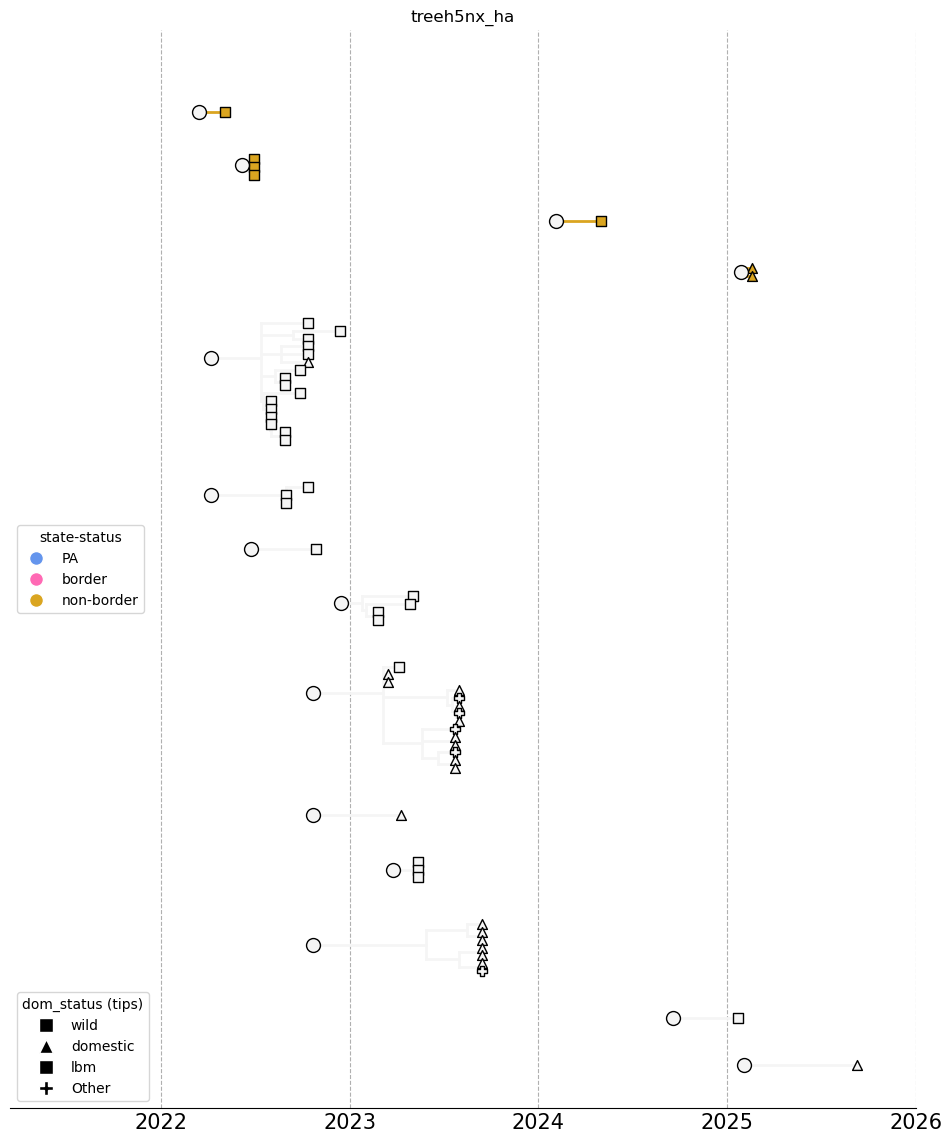

Processing and plotting subtrees for treeh5nx_mp


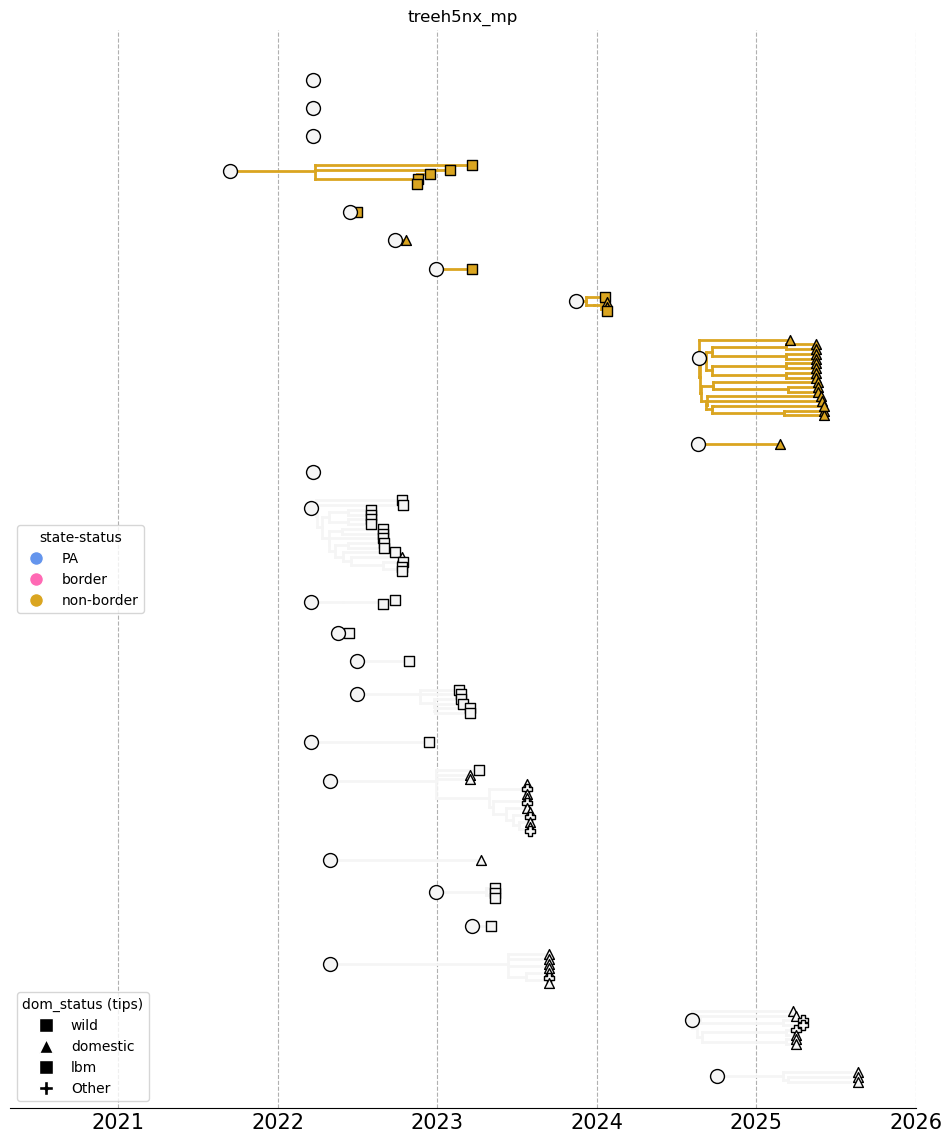


Unique Counts DataFrames:
Unique counts for treeh5nx_ha:
   origin_trait tip_trait  count  frequency
0            PA    border      1          4
1            PA    border      3          2
2            PA    border      4          1
3            PA    border      7          1
4            PA    border     14          1
..          ...       ...    ...        ...
57   non-border    border     16          1
58   non-border    border     19          2
59   non-border    border     23          1
60   non-border    border     24          1
61   non-border    border     28          1

[62 rows x 4 columns]


Unique counts for treeh5nx_mp:
   origin_trait tip_trait  count  frequency
0            PA    border      1          6
1            PA    border      2          1
2            PA    border      3          2
3            PA    border      6          1
4            PA    border      7          1
..          ...       ...    ...        ...
57   non-border    border     13          1
58   n

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import pandas as pd
from collections import defaultdict, Counter
from datetime import datetime

# Function to find the newest tip date for a given subtree
def return_newest_tip(subtree):
    all_tipDates = [k.absoluteTime for k in subtree.Objects if k.branchType == "leaf"]
    return max(all_tipDates) if all_tipDates else None

# Function to retrieve all tip dates for a given subtree
def retrieve_tip_dates(subtree):
    return [k.absoluteTime for k in subtree.Objects if k.branchType == "leaf"]

# Function to process each tree and count tips and transitions
def process_tree(tree, traitName):
    tree_strings = defaultdict(list)
    subtype_trees = defaultdict(list)
    tip_counts = []
    transitions = Counter()
    
    for t in tree.Objects:  # Iterate over branches
        k = t  # branch
        kp = t.parent  # branch's parent
        
        # Get current node's and its parent's trait states
        kloc = k.traits.get(traitName, 'ancestor')
        kploc = kp.traits.get(traitName, 'ancestor')
        
        kc = kloc  # kc is branch trait value
        kpc = kploc  # kpc is branch parent trait value
        
        # Count transitions
        if kpc != kc:
            transitions[(kpc, kc)] += 1
            
        # If states do not match
        if kc != kpc:
            traverse_condition = lambda w: w.traits.get(traitName, 'ancestor') == kc  # only traverse tree for as long as branches are in the branch state
            subtree = tree.subtree(k, traverse_condition=traverse_condition)  # get the conditional subtree
            
            if subtree:  # if the conditional subtree traversal succeeded
                subtree.traverse_tree()  # traverse subtree
                subtree.sortBranches()  # sort branches
                tree_strings[kc].append(subtree.toString())  # remember subtree string
                subtype_trees[kc].append((kpc, subtree))  # add parental state and subtree to list
                
                # Count tips in the subtree and store the counts
                tip_traits = [node.traits.get(traitName, 'ancestor')
                              for node in subtree.Objects if node.branchType == "leaf"]
                tip_count = Counter(tip_traits)
                tip_counts.extend([(kpc, tip_trait, count) for tip_trait, count in tip_count.items()])

    # Convert transitions Counter to regular dictionary
    transitions_dict = dict(transitions)
    
    return tree_strings, subtype_trees, tip_counts, transitions_dict

# Shape mapping based on county
shape_mapping = {
    'wild': 's',   # Circle
    'domestic': '^',    # Triangle up
    'lbm': "s", #square
    'Other': 'P'

}

def get_marker_shape(node):
    # Check if the node has the 'metadata' attribute and 'county' in it
    if hasattr(node, 'metadata') and 'wild_dom_lbm' in node.metadata:
        return shape_mapping.get(node.metadata['wild_dom_lbm'], shape_mapping['Other'])
    return shape_mapping['Other']

# Function to plot each tree's subtrees
def plot_tree(tree_name, tree, tree_strings, subtype_trees, traitName):
    fig = plt.figure(figsize=(12, 14), facecolor='w')  # create figure
    gs = gridspec.GridSpec(1, 1, wspace=0.0)  # using gridspec by default
    ax = plt.subplot(gs[0], facecolor='w')  # create axes
    
    tipSize = 50
    cumulative_y = 0.05
    
    x_attr = lambda k: k.absoluteTime
    c_func = lambda k: ('cornflowerblue' if k.traits[traitName] == 'Pennsylvania' 
                        else 'hotpink' if k.traits[traitName] == 'non_PA'
                        else 'goldenrod' if k.traits[traitName] == 'non-border'
                        else 'whitesmoke')


    
    for subtype in ['Pennsylvania', 'border', 'non-border']:
        for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
            origin, loc_tree = tr  # get origin of subtree, subtree itself

            subtree_trait = loc_tree.root.traits.get(traitName)
            
            # Skip unwanted origin/trait pairs
            unwanted_pairs = {('non-border', 'border'), ('border', 'non-border')}
            if origin == "ancestor" or (origin, subtree_trait) in unwanted_pairs:
                continue
            
            y_attr = lambda k: k.y + cumulative_y  # subtree y values will be offset
            
            loc_tree.plotTree(ax, x_attr=x_attr, y_attr=y_attr, colour=c_func)  # plot subtree
            
            # Plot points with different shapes based on county
            for node in loc_tree.Objects:
                if node.branchType == "leaf":
                    marker = get_marker_shape(node)
                    ax.scatter(node.absoluteTime, y_attr(node), s=tipSize, facecolor=c_func(node), edgecolor='black', marker=marker, zorder=150)

            oriC = 'dimgrey' if origin == 'ancestor' else c_func(loc_tree.root.parent)  # origin of subtree
            
            oriX = loc_tree.root.absoluteTime - loc_tree.root.length
            oriY = loc_tree.root.y + cumulative_y
            
            ax.scatter(oriX, oriY, 100, facecolor=oriC, edgecolor='black', lw=1, zorder=150)  # add big circle at base of tree to indicate origin
            cumulative_y += loc_tree.ySpan + 5  # increment y displacement
    
    ax.xaxis.tick_bottom()
    ax.yaxis.tick_left()
    
    [ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left']]
    
    ax.tick_params(axis='x', size=0, labelsize=15)  # no x axis ticks or labels
    ax.tick_params(axis='y', size=0)
    
    ax.grid(axis='x', ls='--')
    
    ax.set_yticklabels([])
    ax.set_ylim(-5, cumulative_y + 5)
    ax.set_xlim(tree.root.absoluteTime - 0.5, 2026)  # limit x axis
    
    # Create handles for traits legend
    # trait_legend_labels = {
    #     'border': 'cornflowerblue',
    #     'PA': 'hotpink',
    #     'non-border': 'goldenrod'
    # }
    trait_legend_labels = {
        'PA': 'cornflowerblue',
        'border': 'hotpink',
        'non-border': 'goldenrod'
    }
    
    trait_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=10, markerfacecolor=color)
                     for label, color in trait_legend_labels.items()]
    
    # Create handles for county legend
    county_handles = [mlines.Line2D([0], [0], marker=shape, color='w', label=label, markerfacecolor='black', markersize=10)
                      for label, shape in shape_mapping.items()]

    # Add legends to the plot
    trait_legend = plt.legend(handles=trait_handles, title='state-status', loc='center left')
    ax.add_artist(trait_legend)  # Add the trait legend first
    plt.legend(handles=county_handles, title='dom_status (tips)', loc='lower left')
    
    # Add plot title
    plt.title(tree_name)
    output_filename = "../phylo_scripts_analysis/output_figs/subtree_plots_" + str(tree_name) + "_" + todays_date + ".png"
    plt.gcf().subplots_adjust(right=0.88)
    # plt.savefig(output_filename, format='png')
    plt.show()

# Create dictionaries to hold transitions, oriX values, and latest tip dates for each tree
transitions_dict = {}
oriX_values = defaultdict(lambda: defaultdict(list))
latest_tip_dates = defaultdict(lambda: defaultdict(list))
unique_counts_dict = {}

# Process and plot each tree
for tree_name, tree in trees.items():
    print(f"Processing and plotting subtrees for {tree_name}")
    tree_strings, subtype_trees, tip_counts, transitions = process_tree(tree, traitName)
    
    # Convert the list of tuples into a DataFrame
    df_counts = pd.DataFrame(tip_counts, columns=['origin_trait', 'tip_trait', 'count'])
    
    # Group by 'origin_trait', 'tip_trait', and 'count' and get the size of each group
    unique_counts = df_counts.groupby(['origin_trait', 'tip_trait', 'count']).size().reset_index(name='frequency')
    
    # Store the unique counts DataFrame in the dictionary
    unique_counts_dict[tree_name] = unique_counts
    
    # Store the transitions in the dictionary
    transitions_dict[tree_name] = transitions
    
    # Calculate oriX values and latest tip dates and store them
    # for subtype in ['PA', 'border', 'non-border']:
    for subtype in ['Pennsylvania', 'non-PA']:

        for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
            origin, loc_tree = tr  # get origin of subtree, subtree itself
            oriX = loc_tree.root.absoluteTime - loc_tree.root.length
            oriX_values[tree_name][(origin, subtype)].append(oriX)
            
            # Find the latest tip date using the return_newest_tip function
            latest_tip_date = return_newest_tip(loc_tree)
            latest_tip_dates[tree_name][(origin, subtype)].append(latest_tip_date)
    
    # Plot the tree
    plot_tree(tree_name, tree, tree_strings, subtype_trees, traitName)

# Print the DataFrames for unique counts
print("\nUnique Counts DataFrames:")
for tree_name, unique_counts in unique_counts_dict.items():
    print(f"Unique counts for {tree_name}:")
    print(unique_counts)
    print("\n")

# Print the transitions
print("Transition counts for each tree:")
for tree_name, transitions in transitions_dict.items():
    print(f"{tree_name}: {transitions}")

# Create a list to store the data for the duration DataFrame
data = []

# Collect oriX values and latest tip dates for each tree and transition type
for tree_name, oriX_dict in oriX_values.items():
    for transition, oriX_list in oriX_dict.items():
        for oriX, latest_tip_date in zip(oriX_list, latest_tip_dates[tree_name][transition]):
            data.append({
                'tree': tree_name,
                'transition_type': transition,
                'origin_date': oriX,
                'latest_tip_date': latest_tip_date
            })

# Convert the list to a DataFrame
df_duration = pd.DataFrame(data, columns=['tree', 'transition_type', 'origin_date', 'latest_tip_date'])

# Calculate the duration in days between the Origin Date and Latest Tip Date
df_duration['subtree_duration_days'] = (df_duration['latest_tip_date'] - df_duration['origin_date']) * 365.25
df_duration['subtree_duration_days'] = df_duration['subtree_duration_days'].round(1)
df_duration['transition_type'] = df_duration['transition_type'].astype(str)\
                                             .str.replace(r'\(|\)', '', regex=True)\
                                             .str.replace(', ', '_')\
                                             .str.replace(',', '_')\
                                             .str.replace("'", '')

# Print the Subtree Duration DataFrame
print("\nSubtree Duration DataFrame:")
print(df_duration.head(10))


Processing and plotting subtrees for treeh5nx_ha


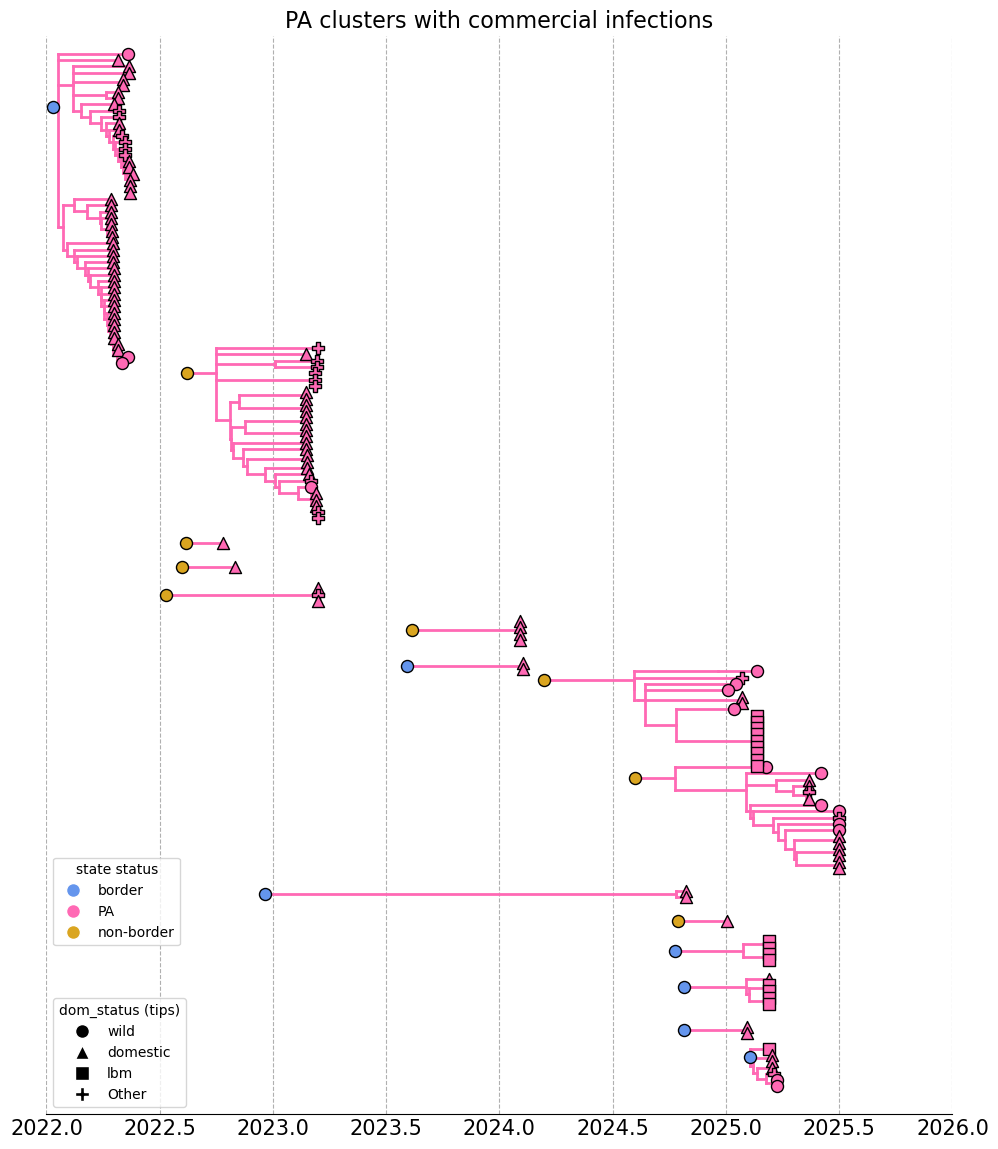

Processing and plotting subtrees for treeh5nx_mp


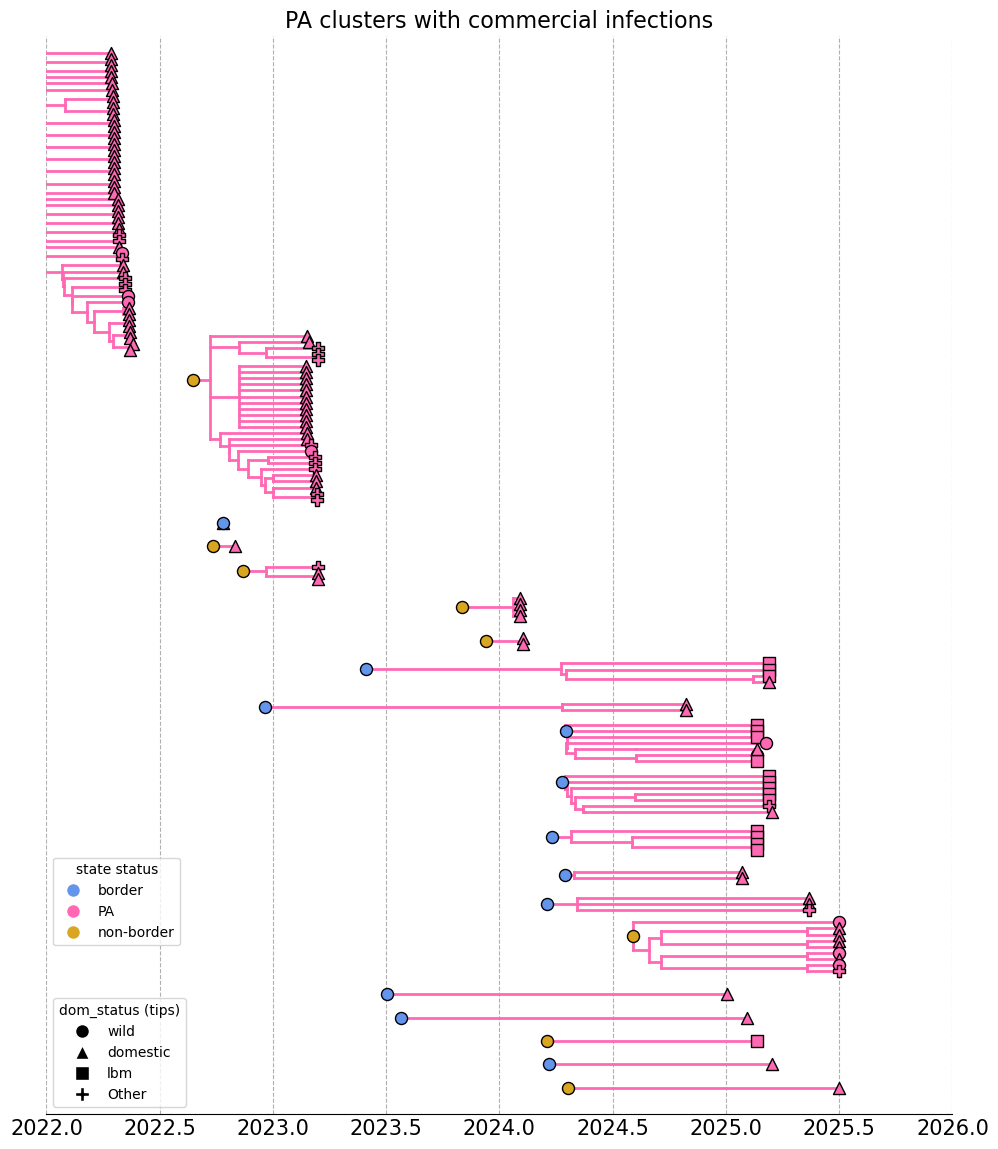

Processing and plotting subtrees for treeh5nx_na


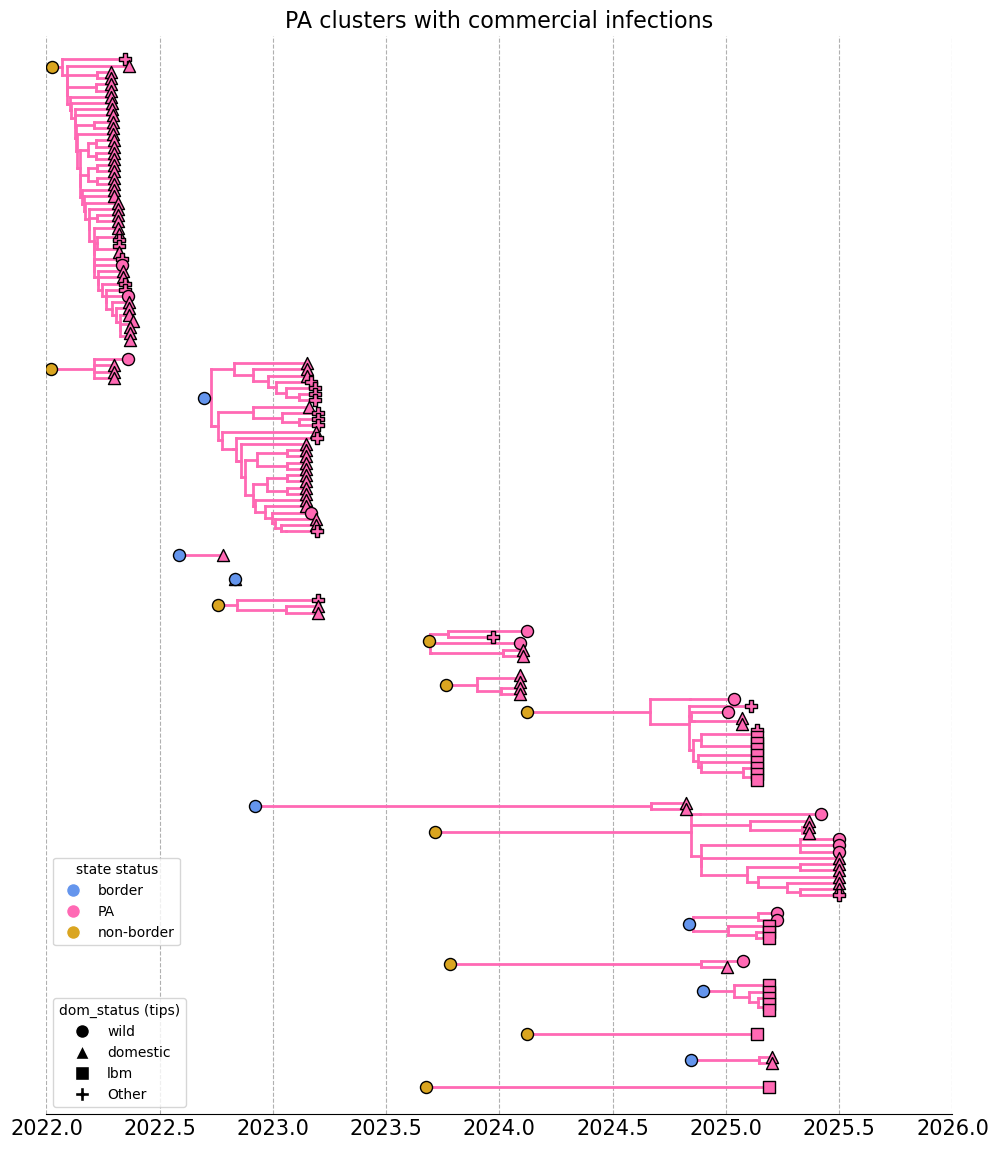

Processing and plotting subtrees for treeh5nx_np


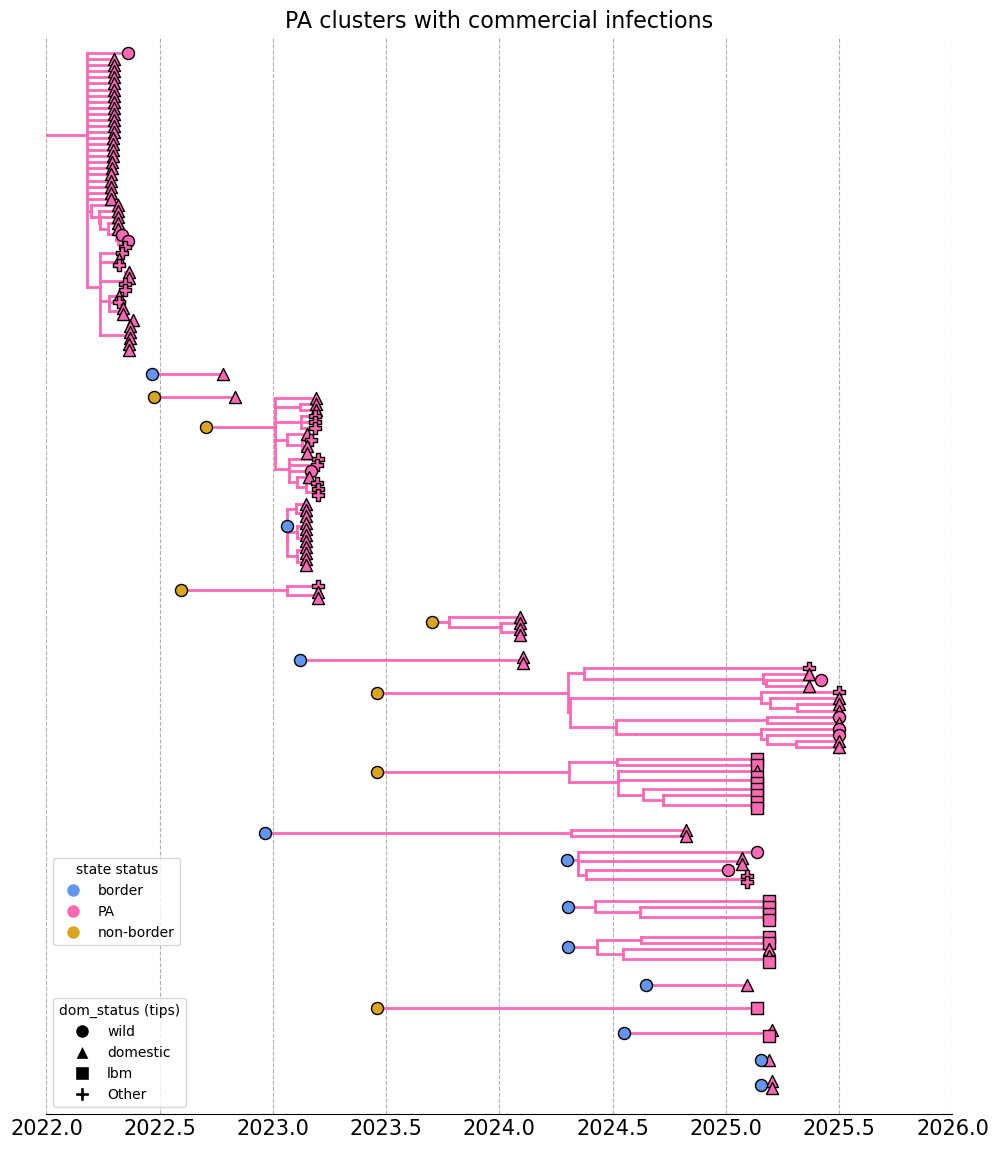

Processing and plotting subtrees for treeh5nx_ns


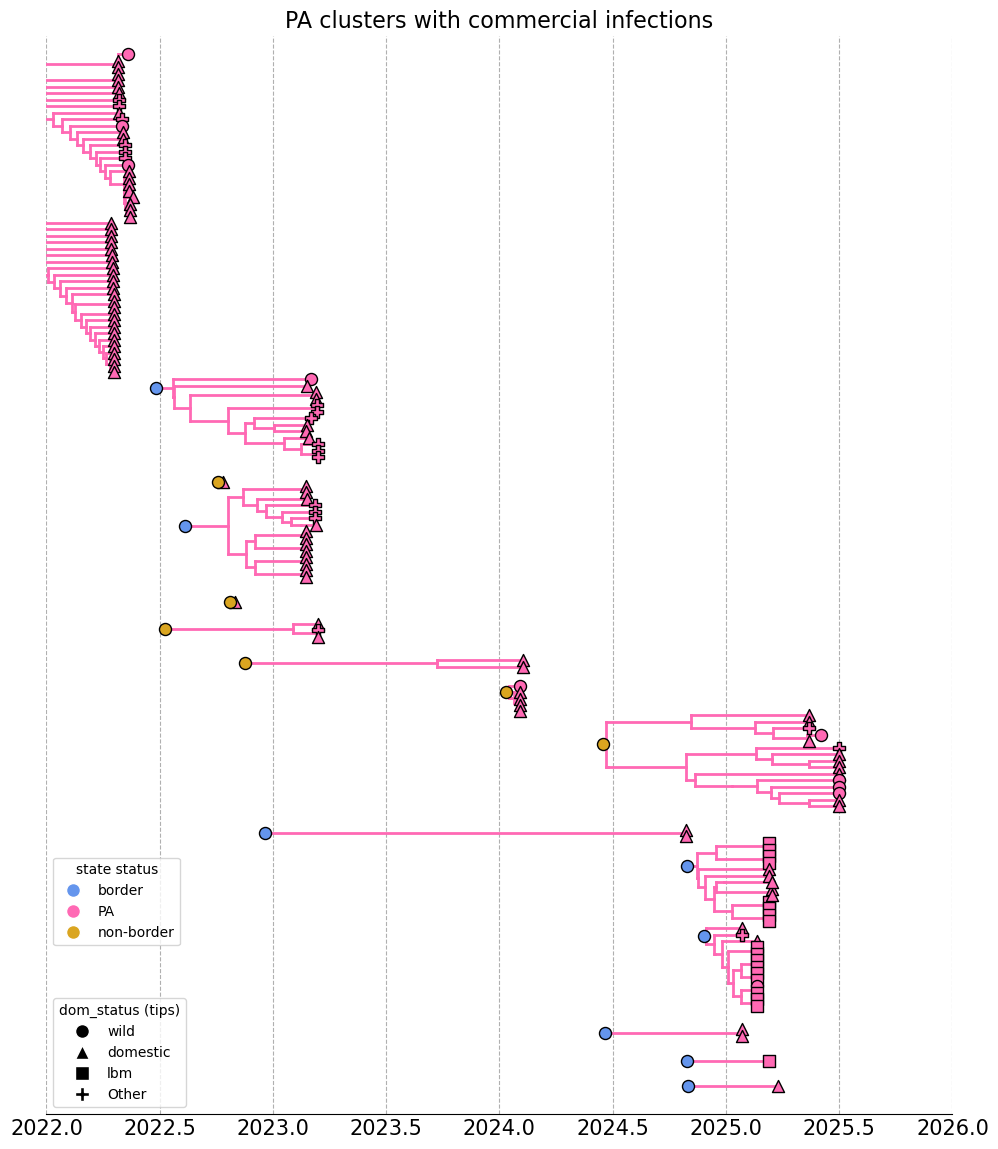

Processing and plotting subtrees for treeh5nx_pa


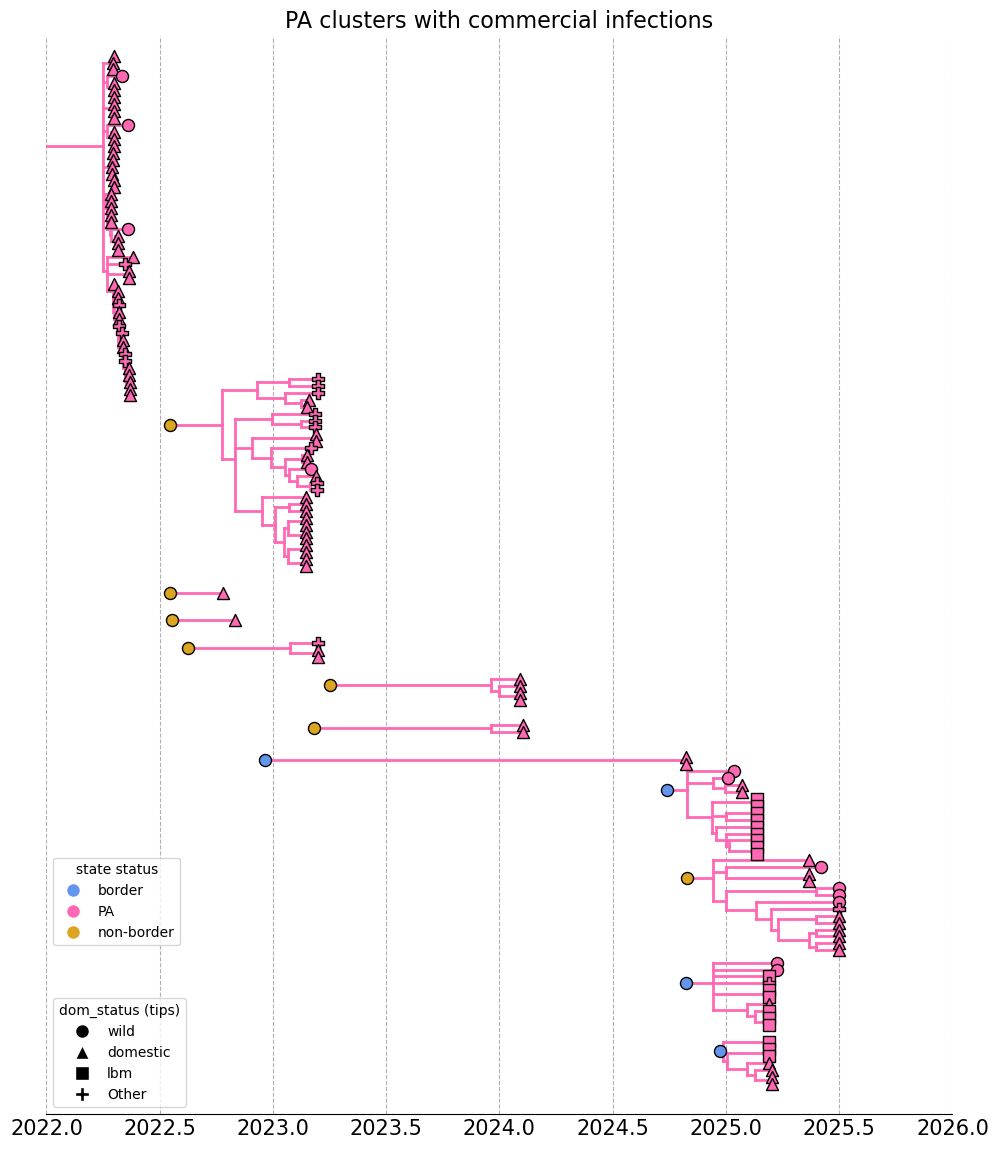

Processing and plotting subtrees for treeh5nx_pb1


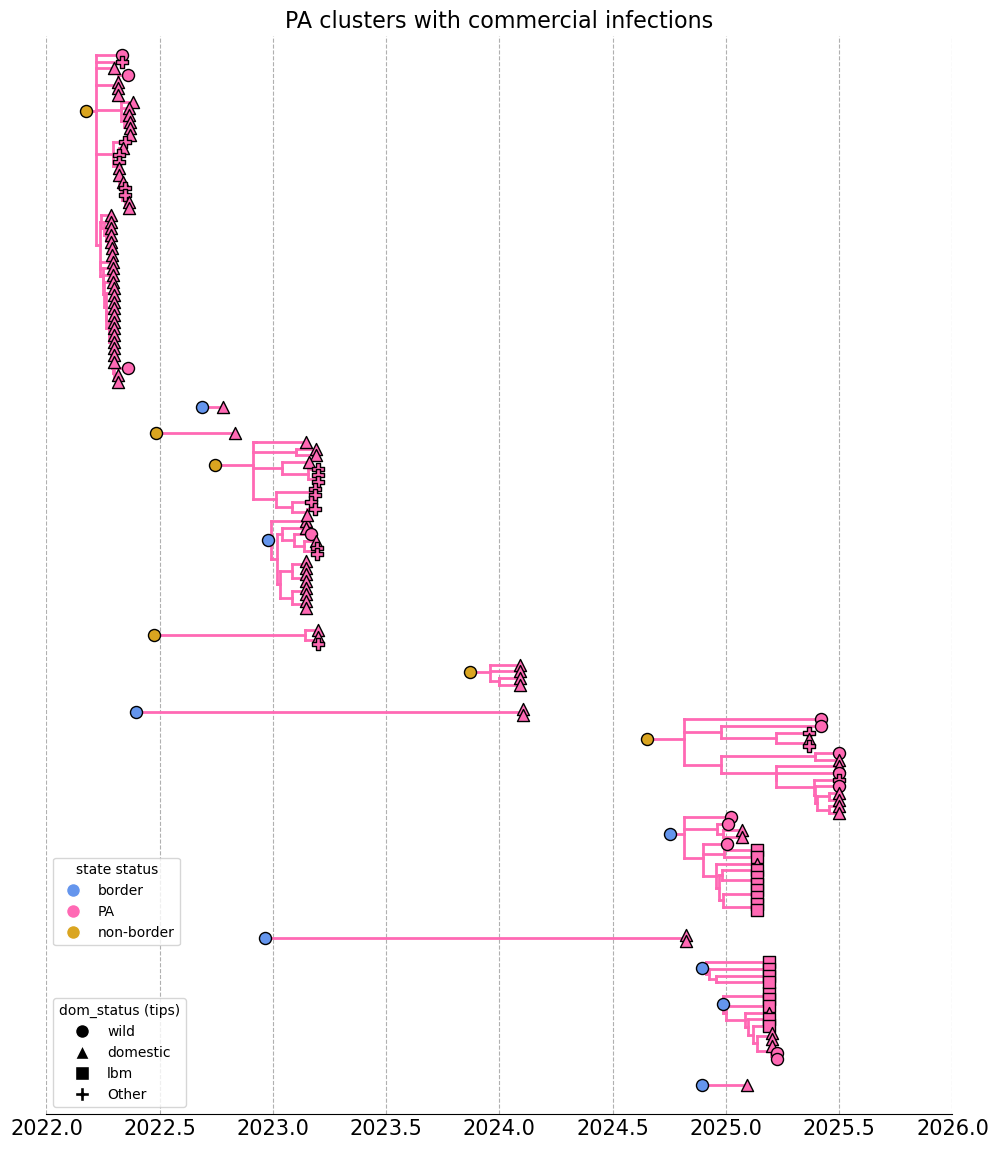

Processing and plotting subtrees for treeh5nx_pb2


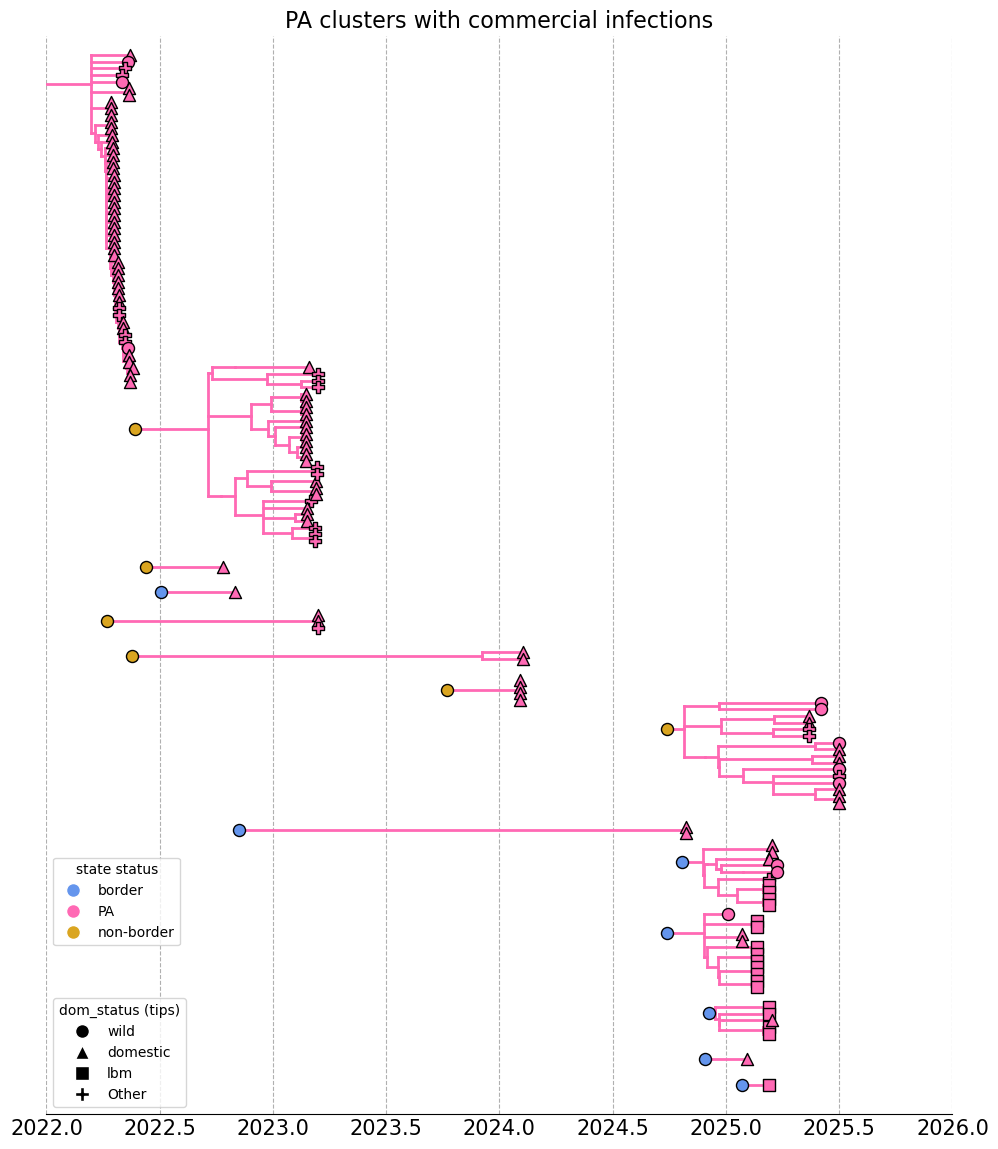

In [149]:
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import matplotlib.lines as mlines
# import pandas as pd
# from collections import defaultdict, Counter
# from datetime import datetime


# # Shape mapping based on county
# # shape_mapping = {
# #     'wild': 's',   # Circle
# #     'domestic': '^',    # Triangle up
# #     'Other': 'P'

# # }
# shape_mapping = {
#     'wild': "o",   # Circle
#     'domestic': '^',    # Triangle up
#     'lbm': "s", #square
#     'Other': 'P'

# }

# def get_marker_shape(node):
#     # Check if the node has the 'metadata' attribute and 'county' in it
#     if hasattr(node, 'metadata') and 'wild_dom_lbm' in node.metadata:
#         return shape_mapping.get(node.metadata['wild_dom_lbm'], shape_mapping['Other'])
#     return shape_mapping['Other']

# # Function to plot each tree's subtrees
# def plot_tree(tree_name, tree, tree_strings, subtype_trees, traitName):
#     fig = plt.figure(figsize=(12, 14), facecolor='w')  # create figure
#     gs = gridspec.GridSpec(1, 1, wspace=0.0)  # using gridspec by default
#     ax = plt.subplot(gs[0], facecolor='w')  # create axes
    
#     tipSize = 75
#     cumulative_y = 0.05
    
#     x_attr = lambda k: k.absoluteTime
#     c_func = lambda k: ('cornflowerblue' if k.traits[traitName] == 'border' 
#                         else 'hotpink' if k.traits[traitName] == 'PA'
#                         else 'goldenrod' if k.traits[traitName] == 'non-border'
#                         else 'whitesmoke')
#     # c_func = lambda k: ('cornflowerblue' if k.traits[traitName] == 'Pennsylvania' 
#     #                     else 'hotpink' if k.traits[traitName] == 'non_PA'
#     #                     # else 'goldenrod' if k.traits[traitName] == 'non-border'
#     #                     else 'whitesmoke')

    
#     for subtype in ['PA', 'border', 'non-border']:
#     # for subtype in ['Pennsylvania', 'non_PA']:

#         for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
#             origin, loc_tree = tr
        
#             # # ---- NEW FILTER- eliminates singletons that are wild status ----
#             # leaf_nodes = [node for node in loc_tree.Objects if node.branchType == "leaf"]
        
#             # if len(leaf_nodes) == 1:
#             #     only_tip = leaf_nodes[0]
#             #     if hasattr(only_tip, "metadata") and only_tip.metadata.get("wild_dom_lbm") == "wild":
#             #         continue
#             # # ---------------------
        
#             # subtree_trait = loc_tree.root.traits.get(traitName)
#             # # Get all leaf nodes
#             leaf_nodes = [node for node in loc_tree.Objects if node.branchType == "leaf"]
            
#             # Get dom_stat values for all tips
#             tip_statuses = [
#                 node.metadata.get("wild_dom_lbm")
#                 for node in leaf_nodes
#                 if hasattr(node, "metadata")
#             ]

#     # If ALL tips are wild → skip this subtree
#             # if len(tip_statuses) > 0 and (all(status == "wild" for status in tip_statuses) or all(status == "unknown" for status in tip_statuses)):
       
#     # Skip subtree if it does NOT contain at least one lbm or domestic tip
#             if not any(status in {"lbm", "domestic"} for status in tip_statuses):
#                 continue

#      #  #for regular including all subtrees  
#         # for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
#         #     origin, loc_tree = tr  # get origin of subtree, subtree itself

#             subtree_trait = loc_tree.root.traits.get(traitName)
            
#             # Skip unwanted origin/trait pairs
#             unwanted_pairs = {('non-border', 'border'), ('border', 'non-border'), ('PA', 'border'), ('PA', 'non-border'), ('Pennsylvania', 'non_PA')}
#             if origin == "ancestor" or (origin, subtree_trait) in unwanted_pairs:
#                 continue
            
#             # y_attr = lambda k: k.y + cumulative_y  # subtree y values will be offset
#             y_attr = lambda k: (k.y * 1.3) + cumulative_y ## multiplication factor for spreading branches out
            
#             loc_tree.plotTree(ax, x_attr=x_attr, y_attr=y_attr, colour=c_func)  # plot subtree
            
#             # Plot points with different shapes based on county
#             for node in loc_tree.Objects:
#                 if node.branchType == "leaf":
#                     marker = get_marker_shape(node)
#                     ax.scatter(node.absoluteTime, y_attr(node), s=tipSize, facecolor=c_func(node), edgecolor='black', marker=marker, zorder=150)

#             oriC = 'dimgrey' if origin == 'ancestor' else c_func(loc_tree.root.parent)  # origin of subtree
            
#             oriX = loc_tree.root.absoluteTime - loc_tree.root.length
#             oriY = (loc_tree.root.y *1.3) + cumulative_y ##adding same spacing so it aligns with yattr
            
#             ax.scatter(oriX, oriY, 75, facecolor=oriC, edgecolor='black', lw=1, zorder=150)  # add big circle at base of tree to indicate origin
#             cumulative_y += loc_tree.ySpan + 4  # increment y displacement BETWEEN subtrees
    
#     ax.xaxis.tick_bottom()
#     ax.yaxis.tick_left()
    
#     [ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left']]
    
#     ax.tick_params(axis='x', size=0, labelsize=15)  # no x axis ticks or labels
#     ax.tick_params(axis='y', size=0)
    
#     ax.grid(axis='x', ls='--')
    
#     ax.set_yticklabels([])
#     ax.set_ylim(-5, cumulative_y + 14) ##adding more buffer here (10) bc spacing on yattr resulted in cutting it off
#     # ax.set_xlim(tree.root.absoluteTime - 0.5, 2026)  # limit x axis
#     ax.set_xlim(2022, 2026)  # limit x axis

    
#     # Create handles for traits legend
#     trait_legend_labels = {
#         'border': 'cornflowerblue',
#         'PA': 'hotpink',
#         'non-border': 'goldenrod'
#     }
#     # trait_legend_labels = {
#     #     'Pennsylvania': 'cornflowerblue',
#     #     'non_PA': 'hotpink'
#     # }
    
#     trait_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=10, markerfacecolor=color)
#                      for label, color in trait_legend_labels.items()]
    
#     # Create handles for county legend
#     county_handles = [mlines.Line2D([0], [0], marker=shape, color='w', label=label, markerfacecolor='black', markersize=10)
#                       for label, shape in shape_mapping.items()]

#     # Add legends to the plot
#     trait_legend = plt.legend(handles=trait_handles, title='state status', loc='lower left', bbox_to_anchor=(0, 0.15))
#     ax.add_artist(trait_legend)  # Add the trait legend first
#     plt.legend(handles=county_handles, title='dom_status (tips)', loc='lower left')
    
#     # Add plot title
#     # plt.title(tree_name)
#     plt.title('PA clusters with commercial infections', fontsize=16)
#     output_filename = "../phylo_scripts_analysis/output_figs/subtree_plots_" + str(tree_name) + "_" + todays_date + ".png"
#     plt.gcf().subplots_adjust(right=0.88)
#     plt.savefig(output_filename, format='png')
#     plt.show()

# # # Create dictionaries to hold transitions, oriX values, and latest tip dates for each tree
# # transitions_dict = {}
# # oriX_values = defaultdict(lambda: defaultdict(list))
# # latest_tip_dates = defaultdict(lambda: defaultdict(list))
# # unique_counts_dict = {}

# # Process and plot each tree
# for tree_name, tree in trees.items():
#     print(f"Processing and plotting subtrees for {tree_name}")
#     tree_strings, subtype_trees, tip_counts, transitions = process_tree(tree, traitName)
    
#     # Convert the list of tuples into a DataFrame
#     df_counts = pd.DataFrame(tip_counts, columns=['origin_trait', 'tip_trait', 'count'])
    
#     # Group by 'origin_trait', 'tip_trait', and 'count' and get the size of each group
#     unique_counts = df_counts.groupby(['origin_trait', 'tip_trait', 'count']).size().reset_index(name='frequency')
    
#     # Store the unique counts DataFrame in the dictionary
#     unique_counts_dict[tree_name] = unique_counts
    
#     # Store the transitions in the dictionary
#     transitions_dict[tree_name] = transitions
    
#     # Calculate oriX values and latest tip dates and store them
#     for subtype in ['PA', 'border', 'non-border']:
#         for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
#             origin, loc_tree = tr  # get origin of subtree, subtree itself
#             oriX = loc_tree.root.absoluteTime - loc_tree.root.length
#             oriX_values[tree_name][(origin, subtype)].append(oriX)
            
#             # Find the latest tip date using the return_newest_tip function
#             latest_tip_date = return_newest_tip(loc_tree)
#             latest_tip_dates[tree_name][(origin, subtype)].append(latest_tip_date)
    
#     # Plot the tree
#     plot_tree(tree_name, tree, tree_strings, subtype_trees, traitName)



Processing and plotting subtrees for treeh5nx_ha


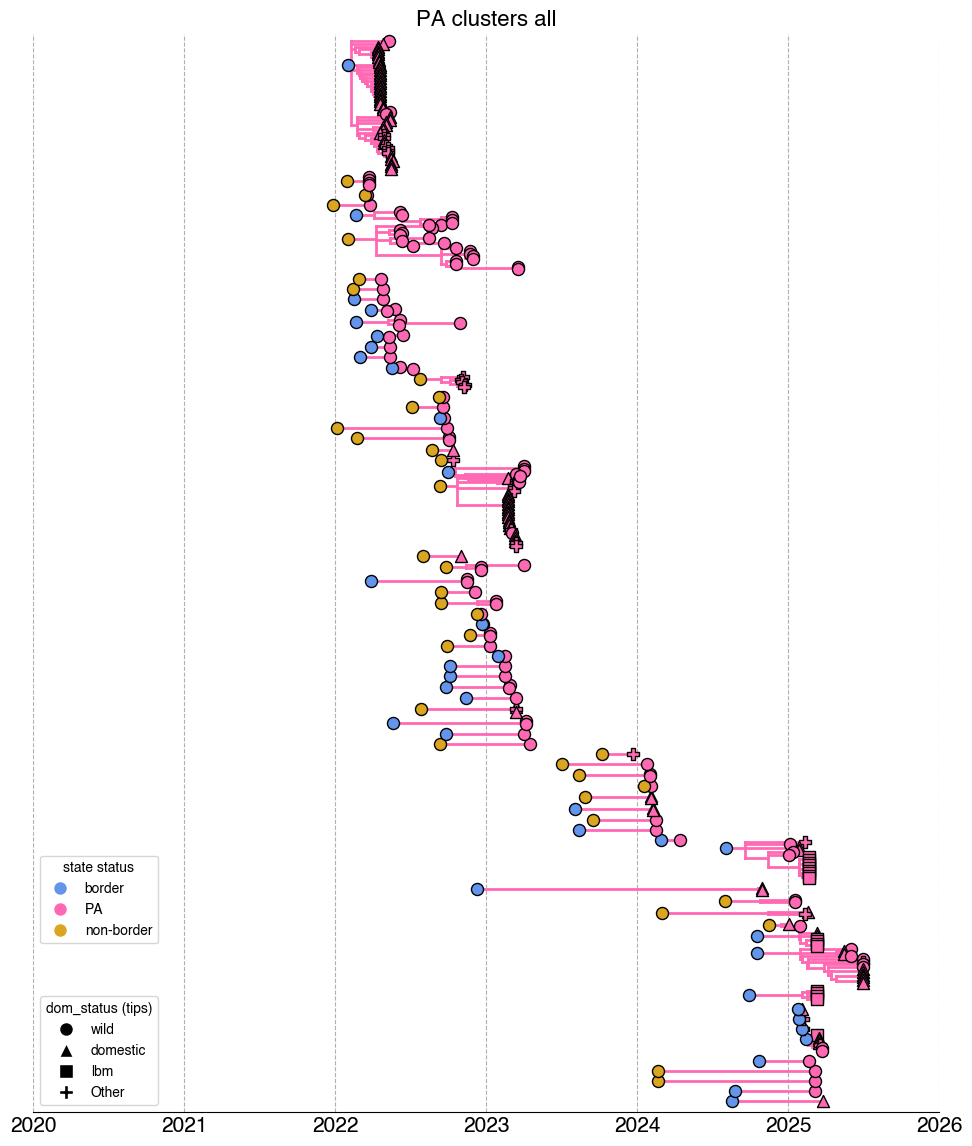

Processing and plotting subtrees for treeh5nx_mp


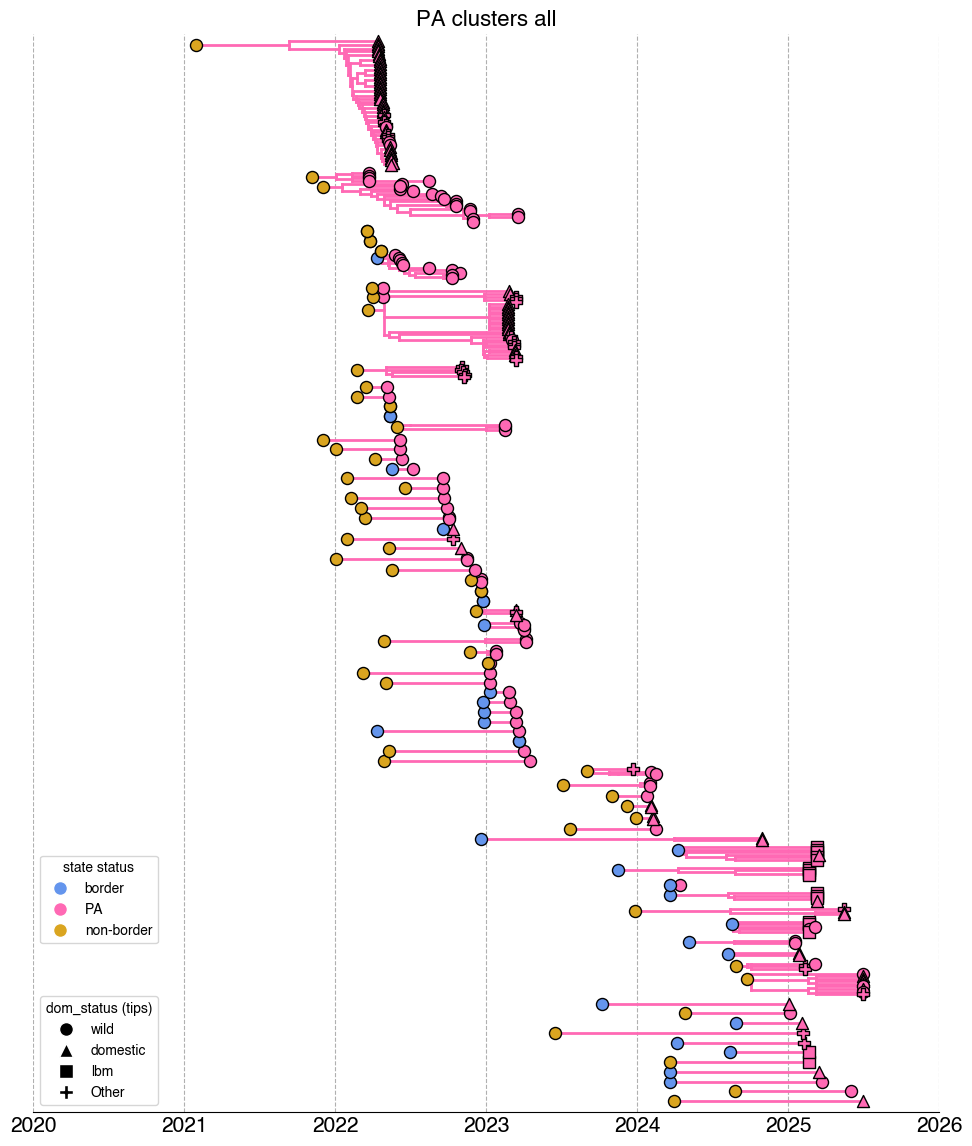

In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import pandas as pd
from collections import defaultdict, Counter
from datetime import datetime

##adding in helvetica font param
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text', usetex='false') 

# Shape mapping based on county
# shape_mapping = {
#     'wild': 's',   # Circle
#     'domestic': '^',    # Triangle up
#     'Other': 'P'

# }
shape_mapping = {
    'wild': "o",   # Circle
    'domestic': '^',    # Triangle up
    'lbm': "s", #square
    'Other': 'P'

}

def get_marker_shape(node):
    # Check if the node has the 'metadata' attribute and 'county' in it
    if hasattr(node, 'metadata') and 'wild_dom_lbm' in node.metadata:
        return shape_mapping.get(node.metadata['wild_dom_lbm'], shape_mapping['Other'])
    return shape_mapping['Other']

# Function to plot each tree's subtrees
def plot_tree(tree_name, tree, tree_strings, subtype_trees, traitName):
    fig = plt.figure(figsize=(12, 14), facecolor='w')  # create figure
    gs = gridspec.GridSpec(1, 1, wspace=0.0)  # using gridspec by default
    ax = plt.subplot(gs[0], facecolor='w')  # create axes
    
    tipSize = 75
    cumulative_y = 0.05
    
    x_attr = lambda k: k.absoluteTime
    c_func = lambda k: ('cornflowerblue' if k.traits[traitName] == 'border' 
                        else 'hotpink' if k.traits[traitName] == 'PA'
                        else 'goldenrod' if k.traits[traitName] == 'non-border'
                        else 'whitesmoke')
    # c_func = lambda k: ('cornflowerblue' if k.traits[traitName] == 'Pennsylvania' 
    #                     else 'hotpink' if k.traits[traitName] == 'non_PA'
    #                     # else 'goldenrod' if k.traits[traitName] == 'non-border'
    #                     else 'whitesmoke')

    
    for subtype in ['PA', 'border', 'non-border']:
    # for subtype in ['Pennsylvania', 'non_PA']:

        for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
            origin, loc_tree = tr
        
            # # ---- NEW FILTER- eliminates singletons that are wild status ----
            # leaf_nodes = [node for node in loc_tree.Objects if node.branchType == "leaf"]
        
            # if len(leaf_nodes) == 1:
            #     only_tip = leaf_nodes[0]
            #     if hasattr(only_tip, "metadata") and only_tip.metadata.get("wild_dom_lbm") == "wild":
            #         continue
            # # ---------------------
        
            # subtree_trait = loc_tree.root.traits.get(traitName)
            # # Get all leaf nodes
            leaf_nodes = [node for node in loc_tree.Objects if node.branchType == "leaf"]
            
            # Get dom_stat values for all tips
            tip_statuses = [
                node.metadata.get("wild_dom_lbm")
                for node in leaf_nodes
                if hasattr(node, "metadata")
            ]

    # If ALL tips are wild → skip this subtree
            # if len(tip_statuses) > 0 and (all(status == "wild" for status in tip_statuses) or all(status == "unknown" for status in tip_statuses)):
       
    # # Skip subtree if it does NOT contain at least one lbm or domestic tip
    #         if not any(status in {"lbm", "domestic"} for status in tip_statuses):
    #             continue

     #  #for regular including all subtrees  
        # for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
        #     origin, loc_tree = tr  # get origin of subtree, subtree itself

            subtree_trait = loc_tree.root.traits.get(traitName)
            
            # Skip unwanted origin/trait pairs
            unwanted_pairs = {('non-border', 'border'), ('border', 'non-border'), ('PA', 'border'), ('PA', 'non-border'), ('Pennsylvania', 'non_PA')}
            if origin == "ancestor" or (origin, subtree_trait) in unwanted_pairs:
                continue
            
            # y_attr = lambda k: k.y + cumulative_y  # subtree y values will be offset
            y_attr = lambda k: (k.y * 1.3) + cumulative_y ## multiplication factor for spreading branches out
            
            loc_tree.plotTree(ax, x_attr=x_attr, y_attr=y_attr, colour=c_func)  # plot subtree
            
            # Plot points with different shapes based on county
            for node in loc_tree.Objects:
                if node.branchType == "leaf":
                    marker = get_marker_shape(node)
                    ax.scatter(node.absoluteTime, y_attr(node), s=tipSize, facecolor=c_func(node), edgecolor='black', marker=marker, zorder=150)

            oriC = 'dimgrey' if origin == 'ancestor' else c_func(loc_tree.root.parent)  # origin of subtree
            
            oriX = loc_tree.root.absoluteTime - loc_tree.root.length
            oriY = (loc_tree.root.y *1.3) + cumulative_y ##adding same spacing so it aligns with yattr
            
            ax.scatter(oriX, oriY, 75, facecolor=oriC, edgecolor='black', lw=1, zorder=150)  # add big circle at base of tree to indicate origin
            cumulative_y += loc_tree.ySpan + 4  # increment y displacement BETWEEN subtrees
    
    ax.xaxis.tick_bottom()
    ax.yaxis.tick_left()
    
    [ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left']]
    
    ax.tick_params(axis='x', size=0, labelsize=15)  # no x axis ticks or labels
    ax.tick_params(axis='y', size=0)
    
    ax.grid(axis='x', ls='--')
    
    ax.set_yticklabels([])
    ax.set_ylim(-5, cumulative_y + 14) ##adding more buffer here (10) bc spacing on yattr resulted in cutting it off
    # ax.set_xlim(tree.root.absoluteTime - 0.5, 2026)  # limit x axis
    ax.set_xlim(2020, 2026)  # limit x axis

    
    # Create handles for traits legend
    trait_legend_labels = {
        'border': 'cornflowerblue',
        'PA': 'hotpink',
        'non-border': 'goldenrod'
    }
    # trait_legend_labels = {
    #     'Pennsylvania': 'cornflowerblue',
    #     'non_PA': 'hotpink'
    # }
    
    trait_handles = [plt.Line2D([0], [0], marker='o', color='w', label=label, markersize=10, markerfacecolor=color)
                     for label, color in trait_legend_labels.items()]
    
    # Create handles for county legend
    county_handles = [mlines.Line2D([0], [0], marker=shape, color='w', label=label, markerfacecolor='black', markersize=10)
                      for label, shape in shape_mapping.items()]

    # Add legends to the plot
    trait_legend = plt.legend(handles=trait_handles, title='state status', loc='lower left', bbox_to_anchor=(0, 0.15))
    ax.add_artist(trait_legend)  # Add the trait legend first
    plt.legend(handles=county_handles, title='dom_status (tips)', loc='lower left')
    
    # Add plot title
    # plt.title(tree_name)
    plt.title('PA clusters all', fontsize=16)
    output_filename = "../output_plots/_" + str(tree_name) + "_" + todays_date + ".png"
    plt.gcf().subplots_adjust(right=0.88)
    # plt.savefig(output_filename, format='png')
    plt.show()

# # Create dictionaries to hold transitions, oriX values, and latest tip dates for each tree
# transitions_dict = {}
# oriX_values = defaultdict(lambda: defaultdict(list))
# latest_tip_dates = defaultdict(lambda: defaultdict(list))
# unique_counts_dict = {}

# Process and plot each tree
for tree_name, tree in trees.items():
    print(f"Processing and plotting subtrees for {tree_name}")
    tree_strings, subtype_trees, tip_counts, transitions = process_tree(tree, traitName)
    
    # Convert the list of tuples into a DataFrame
    df_counts = pd.DataFrame(tip_counts, columns=['origin_trait', 'tip_trait', 'count'])
    
    # Group by 'origin_trait', 'tip_trait', and 'count' and get the size of each group
    unique_counts = df_counts.groupby(['origin_trait', 'tip_trait', 'count']).size().reset_index(name='frequency')
    
    # Store the unique counts DataFrame in the dictionary
    unique_counts_dict[tree_name] = unique_counts
    
    # Store the transitions in the dictionary
    transitions_dict[tree_name] = transitions
    
    # Calculate oriX values and latest tip dates and store them
    for subtype in ['PA', 'border', 'non-border']:
        for t, tr in enumerate(sorted(subtype_trees[subtype], key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
            origin, loc_tree = tr  # get origin of subtree, subtree itself
            oriX = loc_tree.root.absoluteTime - loc_tree.root.length
            oriX_values[tree_name][(origin, subtype)].append(oriX)
            
            # Find the latest tip date using the return_newest_tip function
            latest_tip_date = return_newest_tip(loc_tree)
            latest_tip_dates[tree_name][(origin, subtype)].append(latest_tip_date)
    
    # Plot the tree
    plot_tree(tree_name, tree, tree_strings, subtype_trees, traitName)



Processing and plotting subtrees for treeh5nx_ha
oriX=2024.6260  root.absoluteTime=2025.2290  root.length=0.6030  origin=border  subtree_trait=PA
oriX=2024.6450  root.absoluteTime=2025.1770  root.length=0.5320  origin=border  subtree_trait=PA
oriX=2024.1400  root.absoluteTime=2025.1770  root.length=1.0370  origin=non-border  subtree_trait=PA
oriX=2024.1400  root.absoluteTime=2025.1740  root.length=1.0340  origin=non-border  subtree_trait=PA
oriX=2024.8050  root.absoluteTime=2025.1380  root.length=0.3330  origin=border  subtree_trait=PA
oriX=2025.1170  root.absoluteTime=2025.1280  root.length=0.0110  origin=border  subtree_trait=PA
oriX=2025.0890  root.absoluteTime=2025.0970  root.length=0.0080  origin=border  subtree_trait=PA
oriX=2025.0740  root.absoluteTime=2025.0950  root.length=0.0210  origin=border  subtree_trait=PA
oriX=2025.0670  root.absoluteTime=2025.0890  root.length=0.0220  origin=border  subtree_trait=PA
oriX=2024.7430  root.absoluteTime=2025.0890  root.length=0.3460  origi

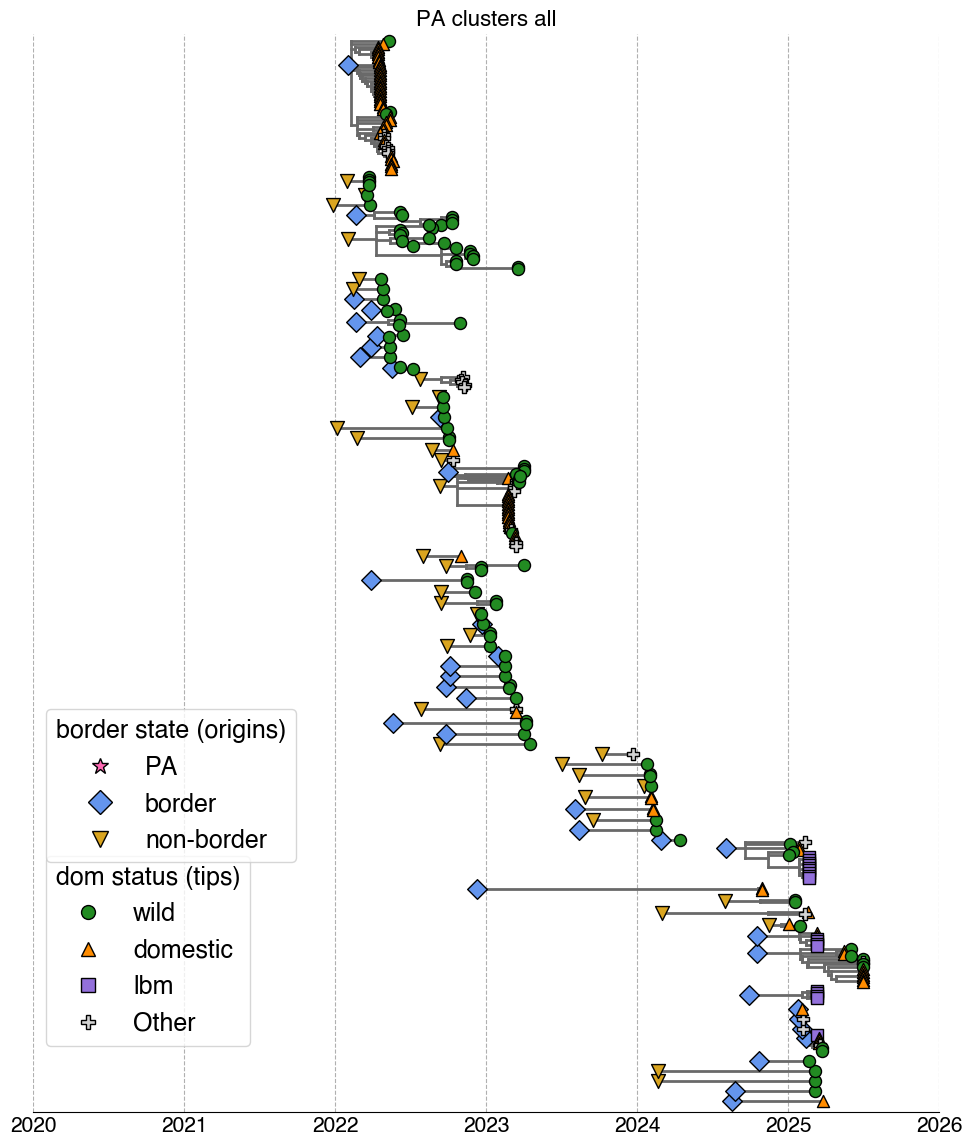

Processing and plotting subtrees for treeh5nx_mp
oriX=2024.2450  root.absoluteTime=2025.4970  root.length=1.2520  origin=non-border  subtree_trait=PA
oriX=2024.6490  root.absoluteTime=2025.4180  root.length=0.7690  origin=non-border  subtree_trait=PA
oriX=2024.2140  root.absoluteTime=2025.2260  root.length=1.0120  origin=border  subtree_trait=PA
oriX=2024.2140  root.absoluteTime=2025.2040  root.length=0.9900  origin=border  subtree_trait=PA
oriX=2024.2140  root.absoluteTime=2025.1380  root.length=0.9240  origin=non-border  subtree_trait=PA
oriX=2024.6110  root.absoluteTime=2025.1380  root.length=0.5270  origin=border  subtree_trait=PA
oriX=2024.2620  root.absoluteTime=2025.1050  root.length=0.8430  origin=border  subtree_trait=PA
oriX=2023.4580  root.absoluteTime=2025.0950  root.length=1.6370  origin=non-border  subtree_trait=PA
oriX=2024.6530  root.absoluteTime=2025.0920  root.length=0.4390  origin=border  subtree_trait=PA
oriX=2024.3160  root.absoluteTime=2025.0100  root.length=0.694

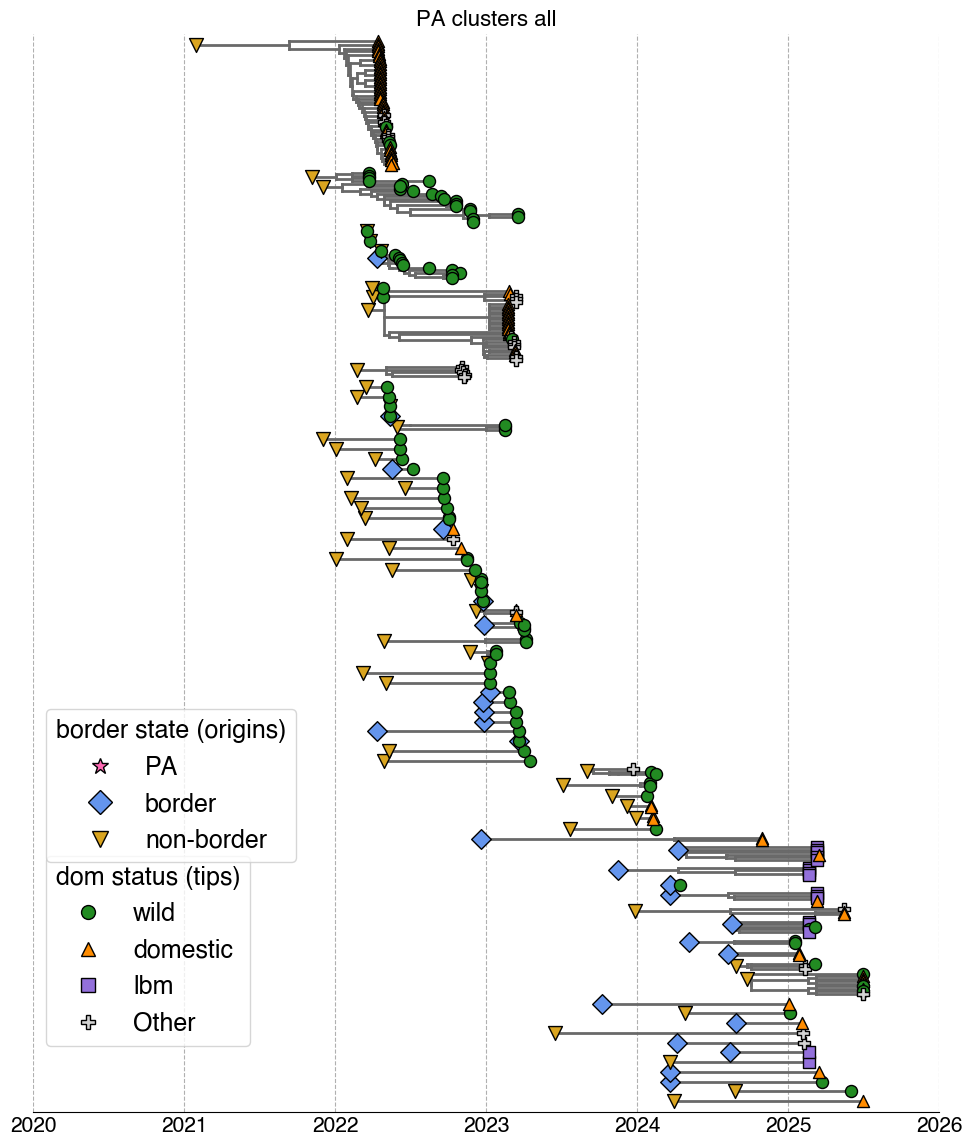

In [16]:
###updated colorings/marker shapes

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import pandas as pd
from collections import defaultdict, Counter
from datetime import datetime

##adding in helvetica font param
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text', usetex='false') 
plt.rcParams.update({'font.size': 18})


# Tip color mapping by wild_dom_lbm status
tip_color_mapping = {
    'wild':     'forestgreen',
    'domestic': 'darkorange',
    'lbm':      'mediumpurple',
    'Other':    'lightgray'
}

# Tip shape mapping (unchanged — used for tips only)
shape_mapping = {
    'wild':     'o',   # Circle
    'domestic': '^',   # Triangle up
    'lbm':      's',   # Square
    'Other':    'P'
}

# Origin shape mapping by border state trait
origin_shape_mapping = {
    'PA':         '*',   # Star
    'border':     'D',   # Diamond
    'non-border': 'v',   # Triangle down
    'ancestor':   'o'    # Fallback
}

# Origin color mapping by border state trait (kept subtle)
origin_color_mapping = {
    'PA':         'hotpink',
    'border':     'cornflowerblue',
    'non-border': 'goldenrod',
    'ancestor':   'dimgrey'
}


def get_tip_color(node):
    if hasattr(node, 'metadata') and 'wild_dom_lbm' in node.metadata:
        return tip_color_mapping.get(node.metadata['wild_dom_lbm'], tip_color_mapping['Other'])
    return tip_color_mapping['Other']

def get_marker_shape(node):
    if hasattr(node, 'metadata') and 'wild_dom_lbm' in node.metadata:
        return shape_mapping.get(node.metadata['wild_dom_lbm'], shape_mapping['Other'])
    return shape_mapping['Other']


def plot_tree(tree_name, tree, tree_strings, subtype_trees, traitName):
    fig = plt.figure(figsize=(12, 14), facecolor='w')
    gs = gridspec.GridSpec(1, 1, wspace=0.0)
    ax = plt.subplot(gs[0], facecolor='w')

    tipSize   = 75
    oriSize   = 100   # larger origin points
    cumulative_y = 0.08

    x_attr = lambda k: k.absoluteTime

    # Branches are flat dark gray — no trait coloring
    branch_color = lambda k: 'dimgray'

    for subtype in ['PA', 'border', 'non-border']:
        for t, tr in enumerate(sorted(subtype_trees[subtype],
                                      key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
            origin, loc_tree = tr



            leaf_nodes = [node for node in loc_tree.Objects if node.branchType == "leaf"]
            tip_statuses = [
                node.metadata.get("wild_dom_lbm")
                for node in leaf_nodes
                if hasattr(node, "metadata")
            ]

            subtree_trait = loc_tree.root.traits.get(traitName)

            unwanted_pairs = {
                ('non-border', 'border'), ('border', 'non-border'),
                ('PA', 'border'), ('PA', 'non-border'),
                ('PA', 'non_PA')
            }
            if origin == "ancestor" or (origin, subtree_trait) in unwanted_pairs:
                continue

            y_attr = lambda k: (k.y * 1.3) + cumulative_y  ##spread within subtrees??

            # Plot branches in dark gray
            loc_tree.plotTree(ax, x_attr=x_attr, y_attr=y_attr, colour=branch_color)

            # Plot tips colored by wild_dom_lbm, shaped by wild_dom_lbm
            for node in loc_tree.Objects:
                if node.branchType == "leaf":
                    marker = get_marker_shape(node)
                    color  = get_tip_color(node)
                    ax.scatter(node.absoluteTime, y_attr(node),
                               s=tipSize, facecolor=color, edgecolor='black',
                               marker=marker, zorder=150)


            parent_trait = (loc_tree.root.parent.traits.get(traitName)
                            if loc_tree.root.parent is not None else None)
            ori_trait    = parent_trait if parent_trait in origin_shape_mapping else 'ancestor'
            ori_marker   = origin_shape_mapping.get(ori_trait, 'o')
            ori_color    = origin_color_mapping.get(ori_trait, 'dimgrey')
            # # Origin: larger point, shaped + colored by border state trait
            # ori_trait  = subtree_trait if subtree_trait in origin_shape_mapping else 'ancestor'
            # ori_marker = origin_shape_mapping.get(ori_trait, 'o')
            # ori_color  = origin_color_mapping.get(ori_trait, 'dimgrey')

            oriX = loc_tree.root.absoluteTime - loc_tree.root.length
            oriY = (loc_tree.root.y * 1.3) + cumulative_y
           ##DEBUGGING LINE TO SEE IF IT'S MATCHING NEXT TREE
            print(f"oriX={oriX:.4f}  root.absoluteTime={loc_tree.root.absoluteTime:.4f}  root.length={loc_tree.root.length:.4f}  origin={origin}  subtree_trait={subtree_trait}")

            ax.scatter(oriX, oriY, s=oriSize, facecolor=ori_color, edgecolor='black',
                       marker=ori_marker, lw=1, zorder=100)

            cumulative_y += loc_tree.ySpan + 4

    ax.xaxis.tick_bottom()
    ax.yaxis.tick_left()
    [ax.spines[loc].set_visible(False) for loc in ['top', 'right', 'left']]
    ax.tick_params(axis='x', size=0, labelsize=17)
    ax.tick_params(axis='y', size=0)
    ax.grid(axis='x', ls='--')
    ax.set_yticklabels([])
    ax.set_ylim(-5, cumulative_y + 14)
    ax.set_xlim(2020, 2026)

    # --- Tip legend: color + shape by wild_dom_lbm ---
    tip_handles = [
        mlines.Line2D([0], [0], marker=shape_mapping[label], color='w',
                      label=label, markerfacecolor=tip_color_mapping[label],
                      markeredgecolor='black', markersize=10)
        for label in ['wild', 'domestic', 'lbm', 'Other']
    ]

    # --- Origin legend: shape + color by border state ---
    ori_handles = [
        mlines.Line2D([0], [0], marker=origin_shape_mapping[label], color='w',
                      label=label, markerfacecolor=origin_color_mapping[label],
                      markeredgecolor='black', markersize=12)
        for label in ['PA', 'border', 'non-border']
    ]

    tip_legend = plt.legend(handles=tip_handles, title='dom status (tips)',
                            loc='lower left', bbox_to_anchor=(0, 0.05))
    ax.add_artist(tip_legend)
    plt.legend(handles=ori_handles, title='border state (origins)',
               loc='lower left', bbox_to_anchor=(0, 0.22))

    plt.title('PA clusters all', fontsize=16)
    output_filename = "../output_plots/pa_clusters_all_" + str(tree_name) + "_" + todays_date + ".png"
    plt.gcf().subplots_adjust(right=0.88)
    # plt.savefig(output_filename, format='png')
    plt.show()


# Process and plot each tree (unchanged)
for tree_name, tree in trees.items():
    print(f"Processing and plotting subtrees for {tree_name}")
    tree_strings, subtype_trees, tip_counts, transitions = process_tree(tree, traitName)

    df_counts = pd.DataFrame(tip_counts, columns=['origin_trait', 'tip_trait', 'count'])
    unique_counts = df_counts.groupby(['origin_trait', 'tip_trait', 'count']).size().reset_index(name='frequency')
    unique_counts_dict[tree_name] = unique_counts
    transitions_dict[tree_name] = transitions

    for subtype in ['PA', 'border', 'non-border']:
        for t, tr in enumerate(sorted(subtype_trees[subtype],
                                      key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects)))):
            origin, loc_tree = tr
            oriX = loc_tree.root.absoluteTime - loc_tree.root.length
            oriX_values[tree_name][(origin, subtype)].append(oriX)
            latest_tip_date = return_newest_tip(loc_tree)
            latest_tip_dates[tree_name][(origin, subtype)].append(latest_tip_date)

    plot_tree(tree_name, tree, tree_strings, subtype_trees, traitName)

In [17]:
wild_pivot = pd.read_csv('../output_dfs/wild_pivot.csv', index_col=0,)
# comm_pivot = pd.read_csv('../output_dfs/comm_nolbm_pivot.csv', index_col=0,)
comm_pivot = pd.read_csv('../output_dfs/comm_pivot.csv', index_col=0,)

# lbm_pivot = pd.read_csv('../output_dfs/lbm_pivot.csv', index_col=0,)
# lbm_pivot

In [37]:
# # def make_weekly_pivot(df):
# #     weekly = (
# #         df.groupby(['State', pd.Grouper(key='Collection Date', freq='W-MON')])
# #         .size()
# #         .reset_index(name='cases')
# #     )
# #     pivot = weekly.pivot_table(index='Collection Date', columns='State', values='cases', fill_value=0)
# #     full_range = pd.date_range(
# #         start=min(wild_pivot.index.min(), comm_pivot.index.min()).replace(day=1),
# #         end=max(wild_pivot.index.max(), comm_pivot.index.max()) + pd.offsets.MonthEnd(1),
# #         freq='W-MON'
# #     )
# #     return pivot.reindex(full_range, fill_value=0)

# # wild_pivot = make_weekly_pivot(pa_wild)
# # comm_pivot = make_weekly_pivot(pa_comm)

# # Align both to the same full date range
# full_range = pd.date_range(
#     start=min(wild_pivot.index.min(), comm_pivot.index.min()),
#     end=max(wild_pivot.index.max(), comm_pivot.index.max()),
#     freq='W-MON'
# )
# wild_pivot = wild_pivot.reindex(full_range, fill_value=0)
# comm_pivot = comm_pivot.reindex(full_range, fill_value=0)

In [21]:
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import pandas as pd

# ── Utility ──────────────────────────────────────────────────────────────────
def date_to_decimal_year(d):
    """Convert a datetime/Timestamp to a decimal year (e.g. 2023-07-02 → 2023.50)."""
    year  = d.year
    start = datetime(year,     1, 1)
    end   = datetime(year + 1, 1, 1)
    return year + (d - start).days / (end - start).days


# ── Core tree-drawing logic (extracted so it accepts an ax) ──────────────────
def draw_tree_on_ax(ax, subtype_trees, traitName):
    tipSize      = 75
    oriSize      = 100
    cumulative_y = 0.08

    x_attr = lambda k: k.absoluteTime

    for subtype in ['PA', 'border', 'non-border']:
        for t, tr in enumerate(sorted(subtype_trees[subtype],
                                      key=lambda x: (-x[1].root.absoluteTime,
                                                     len(x[1].Objects)))):
            origin, loc_tree = tr

            subtree_trait = loc_tree.root.traits.get(traitName)
            unwanted_pairs = {
                ('non-border', 'border'), ('border', 'non-border'),
                ('PA', 'border'), ('PA', 'non-border'),
                ('PA', 'non_PA')
            }
            if origin == "ancestor" or (origin, subtree_trait) in unwanted_pairs:
                continue

            y_attr = lambda k: (k.y * 1.3) + cumulative_y

            # Branches in dark gray
            loc_tree.plotTree(ax, x_attr=x_attr, y_attr=y_attr,
                              colour=lambda k: 'dimgray')

            # Tips: color + shape by wild_dom_lbm
            for node in loc_tree.Objects:
                if node.branchType == "leaf":
                    ax.scatter(node.absoluteTime, y_attr(node),
                               s=tipSize,
                               facecolor=get_tip_color(node),
                               edgecolor='black',
                               marker=get_marker_shape(node),
                               zorder=150)

            # Origin marker
            parent_trait = (loc_tree.root.parent.traits.get(traitName)
                            if loc_tree.root.parent is not None else None)
            ori_trait  = parent_trait if parent_trait in origin_shape_mapping else 'ancestor'
            ori_marker = origin_shape_mapping.get(ori_trait, 'o')
            ori_color  = origin_color_mapping.get(ori_trait, 'dimgrey')

            oriX = loc_tree.root.absoluteTime - loc_tree.root.length
            oriY = (loc_tree.root.y * 1.3) + cumulative_y
            ax.scatter(oriX, oriY, s=oriSize, facecolor=ori_color,
                       edgecolor='black', marker=ori_marker, lw=1, zorder=100)

            cumulative_y += loc_tree.ySpan + 4

    return cumulative_y   # caller needs this for ylim


# ── Combined figure ───────────────────────────────────────────────────────────
def plot_tree_with_cases(tree_name, tree, tree_strings, subtype_trees, traitName,
                         wild_pivot, comm_pivot):

    # Convert weekly date index → decimal years (shared x-axis units)
    # decimal_dates = [date_to_decimal_year(d) for d in full_range]
    
    # Derive full_range from the pivot index directly
    full_range    = wild_pivot.index  # already aligned in your case script
    decimal_dates = [date_to_decimal_year(d) for d in full_range]
    ...
    # ── Layout ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 16), facecolor='w')
    gs  = gridspec.GridSpec(
        2, 1,
        height_ratios=[5, 1],   # tree tall, cases short
        hspace=0.04             # tight gap so axes look connected
    )

    ax_tree  = fig.add_subplot(gs[0])
    ax_cases = fig.add_subplot(gs[1], sharex=ax_tree)   # ← shared x!

    # ── Tree panel ────────────────────────────────────────────────────────────
    cumulative_y = draw_tree_on_ax(ax_tree, subtype_trees, traitName)

    ax_tree.set_xlim(2020, 2026)
    ax_tree.set_ylim(-5, cumulative_y + 14)
    ax_tree.set_yticklabels([])
    ax_tree.tick_params(axis='y', size=0)
    ax_tree.tick_params(axis='x', labelbottom=False)   # hide — shared with bottom panel
    ax_tree.grid(axis='x', ls='--', alpha=0.5)
    [ax_tree.spines[s].set_visible(False) for s in ['top', 'right', 'left']]
    ax_tree.set_title('PA clusters all', fontsize=16)

    # Tip legend
    tip_handles = [
        mlines.Line2D([0], [0], marker=shape_mapping[lbl], color='w', label=lbl,
                      markerfacecolor=tip_color_mapping[lbl],
                      markeredgecolor='black', markersize=10)
        for lbl in ['wild', 'domestic', 'lbm', 'Other']
    ]
    ori_handles = [
        mlines.Line2D([0], [0], marker=origin_shape_mapping[lbl], color='w', label=lbl,
                      markerfacecolor=origin_color_mapping[lbl],
                      markeredgecolor='black', markersize=12)
        for lbl in ['PA', 'border', 'non-border']
    ]
    tip_leg = ax_tree.legend(handles=tip_handles, title='dom status (tips)',
                             loc='lower left', bbox_to_anchor=(0, 0.05))
    ax_tree.add_artist(tip_leg)
    ax_tree.legend(handles=ori_handles, title='border state (origins)',
                   loc='lower left', bbox_to_anchor=(0, 0.22))

    # ── Cases panel ───────────────────────────────────────────────────────────
    ax_cases.plot(decimal_dates, wild_pivot.sum(axis=1).values,
                  color='forestgreen', label='Wild', linewidth=1.5)
    ax_cases.plot(decimal_dates, comm_pivot.sum(axis=1).values,
                  color='darkorange',  label='Domestic', linewidth=1.5)

    ax_cases.set_ylabel('Weekly\nDetections', fontsize=12)
    ax_cases.tick_params(axis='y', labelsize=11)
    ax_cases.grid(axis='x', ls='--', alpha=0.5)
    ax_cases.legend(fontsize=11, loc='upper left')
    [ax_cases.spines[s].set_visible(False) for s in ['top', 'right']]

    # X-tick labels: integer years on the shared axis
    # Place a tick at each whole year; gridlines from the tree will align perfectly.
    year_ticks  = [y for y in range(2020, 2027)]
    ax_cases.set_xticks(year_ticks)
    ax_cases.set_xticklabels([str(y) for y in year_ticks], fontsize=13)
    ax_cases.tick_params(axis='x', which='major', length=6, width=1.2)

    # ── Save ─────────────────────────────────────────────────────────────────
    fig.subplots_adjust(right=0.90)
    output_filename = f"../output_plots/_{tree_name}_{todays_date}.png"
    # plt.savefig(output_filename, format='png', bbox_inches='tight')
    plt.show()


# ── Main loop ────────────────────────────────────────────────────────────────
for tree_name, tree in trees.items():
    print(f"Processing and plotting subtrees for {tree_name}")
    tree_strings, subtype_trees, tip_counts, transitions = process_tree(tree, traitName)

    df_counts    = pd.DataFrame(tip_counts, columns=['origin_trait', 'tip_trait', 'count'])
    unique_counts = df_counts.groupby(['origin_trait', 'tip_trait', 'count']).size().reset_index(name='frequency')
    unique_counts_dict[tree_name]  = unique_counts
    transitions_dict[tree_name]    = transitions

    for subtype in ['PA', 'border', 'non-border']:
        for t, tr in enumerate(sorted(subtype_trees[subtype],
                                      key=lambda x: (-x[1].root.absoluteTime,
                                                     len(x[1].Objects)))):
            origin, loc_tree = tr
            oriX = loc_tree.root.absoluteTime - loc_tree.root.length
            oriX_values[tree_name][(origin, subtype)].append(oriX)
            latest_tip_date = return_newest_tip(loc_tree)
            latest_tip_dates[tree_name][(origin, subtype)].append(latest_tip_date)

    plot_tree_with_cases(
        tree_name, tree, tree_strings, subtype_trees, traitName,
        wild_pivot, comm_pivot        # ← pass your precomputed pivots
    )

Processing and plotting subtrees for treeh5nx_ha


AttributeError: 'str' object has no attribute 'year'

In [18]:
def monthly_decimal_ticks(xlim):
    """Generate decimal-year tick positions and labels for every month in xlim."""
    ticks, labels = [], []
    start_year = int(xlim[0])
    for year in range(start_year, int(xlim[1]) + 2):
        for month in range(1, 13):
            dt = datetime(year, month, 1)
            dy = date_to_decimal_year(dt)
            if xlim[0] <= dy <= xlim[1]:
                ticks.append(dy)
                labels.append(dt.strftime('%b %Y'))
    return ticks, labels

In [19]:
def plot_tree_with_cases(tree_name, tree, tree_strings, subtype_trees, traitName,
                         wild_pivot, comm_pivot,
                         xlim=(2020, 2026),
                         tree_height=28,
                         cases_height=4,
                         max_cases=None):

    # ── 1. build decimal-year x-values for case bars ──────────────────────────
    full_range    = pd.to_datetime(wild_pivot.index)
    bar_width     = 7 / 365.25   # one week in decimal-year units
    week_decimal  = np.array([
        date_to_decimal_year(d + pd.Timedelta(days=3))   # Wed midpoint
        for d in full_range
    ])

    wild_vals = wild_pivot.sum(axis=1).values
    comm_vals = comm_pivot.sum(axis=1).values

    # ── 2. figure layout ──────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, tree_height + cases_height), facecolor='w')
    gs  = gridspec.GridSpec(2, 1,
                            height_ratios=[tree_height, cases_height],
                            hspace=0.005)

    ax_tree  = fig.add_subplot(gs[0])
    ax_cases = fig.add_subplot(gs[1], sharex=ax_tree)

    # ── 3. draw subtrees (your existing logic) ────────────────────────────────
    tipSize      = 75
    oriSize      = 100
    cumulative_y = 0.08

    x_attr = lambda k: k.absoluteTime

    for subtype in ['PA', 'border', 'non-border']:
        for t, tr in enumerate(sorted(subtype_trees[subtype],
                                      key=lambda x: (-x[1].root.absoluteTime,
                                                     len(x[1].Objects)))):
            origin, loc_tree = tr

            subtree_trait = loc_tree.root.traits.get(traitName)
            unwanted_pairs = {
                ('non-border', 'border'), ('border', 'non-border'),
                ('PA', 'border'), ('PA', 'non-border'),
                ('PA', 'non_PA')
            }
            if origin == "ancestor" or (origin, subtree_trait) in unwanted_pairs:
                continue

            y_attr = lambda k: (k.y * 1.3) + cumulative_y

            loc_tree.plotTree(ax_tree, x_attr=x_attr, y_attr=y_attr,
                              colour=lambda k: 'dimgray')

            for node in loc_tree.Objects:
                if node.branchType == "leaf":
                    ax_tree.scatter(node.absoluteTime, y_attr(node),
                                    s=tipSize,
                                    facecolor=get_tip_color(node),
                                    edgecolor='black',
                                    marker=get_marker_shape(node),
                                    zorder=150)

            parent_trait = (loc_tree.root.parent.traits.get(traitName)
                            if loc_tree.root.parent is not None else None)
            ori_trait  = parent_trait if parent_trait in origin_shape_mapping else 'ancestor'
            ori_marker = origin_shape_mapping.get(ori_trait, 'o')
            ori_color  = origin_color_mapping.get(ori_trait, 'dimgrey')

            oriX = loc_tree.root.absoluteTime - loc_tree.root.length
            oriY = (loc_tree.root.y * 1.3) + cumulative_y
            ax_tree.scatter(oriX, oriY, s=oriSize, facecolor=ori_color,
                            edgecolor='black', marker=ori_marker, lw=1, zorder=100)

            cumulative_y += loc_tree.ySpan + 4

    ax_tree.set_xlim(xlim)
    ax_tree.set_ylim(-5, cumulative_y + 14)
    ax_tree.set_yticklabels([])
    ax_tree.tick_params(axis='y', size=0)
    ax_tree.tick_params(axis='x', labelbottom=False, size=0)
    ax_tree.grid(axis='x', ls='--', color='lightgrey', alpha=0.7, zorder=1)
    [ax_tree.spines[s].set_visible(False) for s in ['top', 'right', 'left', 'bottom']]
    ax_tree.set_title('PA clusters all', fontsize=16)

    # vertical month gridlines on tree (mirrors reference script)
    month_ticks, month_labels = monthly_decimal_ticks(xlim)
    for t in month_ticks:
        ax_tree.axvline(t,  color='lightgrey', lw=0.8, ls='--', zorder=1)
        ax_cases.axvline(t, color='lightgrey', lw=0.8, ls='--', zorder=1)

    # tree legends
    tip_handles = [
        mlines.Line2D([0], [0], marker=shape_mapping[lbl], color='w', label=lbl,
                      markerfacecolor=tip_color_mapping[lbl],
                      markeredgecolor='black', markersize=10)
        for lbl in ['wild', 'domestic', 'lbm', 'Other']
    ]
    ori_handles = [
        mlines.Line2D([0], [0], marker=origin_shape_mapping[lbl], color='w', label=lbl,
                      markerfacecolor=origin_color_mapping[lbl],
                      markeredgecolor='black', markersize=12)
        for lbl in ['PA', 'border', 'non-border']
    ]
    tip_leg = ax_tree.legend(handles=tip_handles, title='dom status (tips)',
                             loc='lower left', bbox_to_anchor=(0, 0.05))
    ax_tree.add_artist(tip_leg)
    ax_tree.legend(handles=ori_handles, title='border state (origins)',
                   loc='lower left', bbox_to_anchor=(0, 0.22))

    # ── 4. case count bars ────────────────────────────────────────────────────
    ax_cases.bar(week_decimal, wild_vals,
                 width=bar_width, color='forestgreen', label='Wild', align='center')
    ax_cases.bar(week_decimal, comm_vals,
                 width=bar_width, bottom=wild_vals,
                 color='darkorange', label='Domestic', align='center')

    if max_cases:
        ax_cases.set_ylim(0, max_cases)
    ax_cases.set_ylabel('Weekly\nDetections', fontsize=12)
    ax_cases.tick_params(axis='y', labelsize=11)
    ax_cases.legend(fontsize=11, loc='upper left')
    [ax_cases.spines[s].set_visible(False) for s in ['top', 'right']]

    # ── 5. shared x-axis ticks ────────────────────────────────────────────────
    from matplotlib.ticker import FixedLocator, FixedFormatter
    ax_cases.xaxis.set_major_locator(FixedLocator(month_ticks))
    ax_cases.xaxis.set_major_formatter(FixedFormatter(month_labels))
    ax_cases.tick_params(axis='x', labelsize=12, rotation=30)

    # ── 6. save ───────────────────────────────────────────────────────────────
    output_filename = f"../output_plots/_{tree_name}_{todays_date}.png"
    # plt.savefig(output_filename, bbox_inches='tight', pad_inches=0.1)
    plt.show()

In [20]:
plot_tree_with_cases(tree_name, tree, tree_strings, subtype_trees, traitName,
                         wild_pivot, comm_pivot,
                         xlim=(2020, 2026),
                         tree_height=28,
                         cases_height=4,
                         max_cases=None)

NameError: name 'date_to_decimal_year' is not defined

In [80]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from datetime import datetime


# ── HELPER FUNCTIONS ──────────────────────────────────────────────────────────

def date_to_decimal_year(dt):
    """Convert a datetime/Timestamp to a decimal year float."""
    if isinstance(dt, str):
        dt = pd.to_datetime(dt)
    if hasattr(dt, 'to_pydatetime'):
        dt = dt.to_pydatetime()
    year  = dt.year
    start = datetime(year, 1, 1)
    end   = datetime(year + 1, 1, 1)
    return year + (dt - start).total_seconds() / (end - start).total_seconds()


def monthly_decimal_ticks(xlim):
    """Generate decimal-year tick positions and labels for every month in xlim."""
    ticks, labels = [], []
    start_year = int(xlim[0])
    for year in range(start_year, int(xlim[1]) + 2):
        for month in range(1, 13):
            dt = datetime(year, month, 1)
            dy = date_to_decimal_year(dt)
            if xlim[0] <= dy <= xlim[1]:
                ticks.append(dy)
                labels.append(dt.strftime('%b %Y'))
    return ticks, labels


def get_tip_color(node):
    if hasattr(node, 'metadata') and 'wild_dom_lbm' in node.metadata:
        return tip_color_mapping.get(node.metadata['wild_dom_lbm'], tip_color_mapping['Other'])
    return tip_color_mapping['Other']


def get_marker_shape(node):
    if hasattr(node, 'metadata') and 'wild_dom_lbm' in node.metadata:
        return shape_mapping.get(node.metadata['wild_dom_lbm'], shape_mapping['Other'])
    return shape_mapping['Other']


# ── COLOR / SHAPE MAPPINGS ────────────────────────────────────────────────────

tip_color_mapping = {
    'wild':     'forestgreen',
    'domestic': 'darkorange',
    'lbm':      'mediumpurple',
    'Other':    'lightgray'
}

shape_mapping = {
    'wild':     'o',
    'domestic': '^',
    'lbm':      's',
    'Other':    'P'
}

origin_shape_mapping = {
    'PA':         '*',
    'border':     'D',
    'non-border': 'v',
    'ancestor':   'o'
}

origin_color_mapping = {
    'PA':         'hotpink',
    'border':     'cornflowerblue',
    'non-border': 'goldenrod',
    'ancestor':   'dimgrey'
}


# ── MAIN PLOT FUNCTION ────────────────────────────────────────────────────────

def plot_tree_with_cases(tree_name, tree, tree_strings, subtype_trees, traitName,
                         wild_pivot, comm_pivot,
                         xlim=(2021.75, 2026),
                         tree_height=28,
                         cases_height=4,
                         max_cases=None):

    # 1. case bar x-values in decimal years
    full_range   = pd.to_datetime(wild_pivot.index)
    bar_width    = 7 / 365.25
    week_decimal = np.array([
        date_to_decimal_year(d + pd.Timedelta(days=3))
        for d in full_range
    ])
    wild_vals = wild_pivot.sum(axis=1).values
    comm_vals = comm_pivot.sum(axis=1).values
    # lbm_vals = lbm_pivot.sum(axis=1).values


    # 2. figure layout
    fig = plt.figure(figsize=(13, tree_height + cases_height), facecolor='w')
    gs  = gridspec.GridSpec(2, 1,
                            height_ratios=[tree_height, cases_height],
                            hspace=0.002) ##gap between trees and cases
    ax_tree  = fig.add_subplot(gs[0])
    ax_cases = fig.add_subplot(gs[1], sharex=ax_tree)

    # 3. draw subtrees
    tipSize      = 75
    oriSize      = 100
    cumulative_y = 0.07

    for subtype in ['PA', 'border', 'non-border']:
        for tr in sorted(subtype_trees[subtype],
                         key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects))):
            origin, loc_tree = tr

            subtree_trait = loc_tree.root.traits.get(traitName)
            unwanted_pairs = {
                ('non-border', 'border'), ('border', 'non-border'),
                ('PA', 'border'), ('PA', 'non-border'),
                ('PA', 'non_PA')
            }
            if origin == "ancestor" or (origin, subtree_trait) in unwanted_pairs:
                continue

            y_attr = lambda k, cy=cumulative_y: (k.y * 1.3) + cy

            loc_tree.plotTree(ax_tree,
                              x_attr=lambda k: k.absoluteTime,
                              y_attr=y_attr,
                              colour=lambda k: 'dimgray')

            for node in loc_tree.Objects:
                if node.branchType == "leaf":
                    ax_tree.scatter(node.absoluteTime, y_attr(node),
                                    s=tipSize,
                                    facecolor=get_tip_color(node),
                                    edgecolor='black',
                                    marker=get_marker_shape(node),
                                    zorder=150)

            parent_trait = (loc_tree.root.parent.traits.get(traitName)
                            if loc_tree.root.parent is not None else None)
            ori_trait  = parent_trait if parent_trait in origin_shape_mapping else 'ancestor'
            ori_marker = origin_shape_mapping.get(ori_trait, 'o')
            ori_color  = origin_color_mapping.get(ori_trait, 'dimgrey')

            oriX = loc_tree.root.absoluteTime - loc_tree.root.length
            oriY = y_attr(loc_tree.root)
            ax_tree.scatter(oriX, oriY, s=oriSize, facecolor=ori_color,
                            edgecolor='black', marker=ori_marker, lw=1, zorder=100)

            cumulative_y += loc_tree.ySpan + 4

    # 4. tree axis styling
    ax_tree.set_xlim(xlim)
    ax_tree.set_ylim(-5, cumulative_y + 14)
    ax_tree.set_yticklabels([])
    ax_tree.tick_params(axis='y', size=0)
    ax_tree.tick_params(axis='x', labelbottom=False, size=0)
    [ax_tree.spines[s].set_visible(False) for s in ['top', 'right', 'left', 'bottom']]
    ax_tree.set_title('', fontsize=16)

    # 5. gridlines on both panels
    month_ticks, month_labels = monthly_decimal_ticks(xlim)
    for t in month_ticks:
        ax_tree.axvline(t,  color='lightgrey', lw=0.6, ls='--', zorder=1)
        ax_cases.axvline(t, color='lightgrey', lw=0.6, ls='--', zorder=1)

    # 6. tree legends
    tip_handles = [
        mlines.Line2D([0], [0], marker=shape_mapping[lbl], color='w', label=lbl,
                      markerfacecolor=tip_color_mapping[lbl],
                      markeredgecolor='black', markersize=10)
        for lbl in ['wild', 'domestic', 'lbm', 'Other']
    ]
    ori_handles = [
        mlines.Line2D([0], [0], marker=origin_shape_mapping[lbl], color='w', label=lbl,
                      markerfacecolor=origin_color_mapping[lbl],
                      markeredgecolor='black', markersize=12)
        for lbl in ['PA', 'border', 'non-border']
    ]
    tip_leg = ax_tree.legend(handles=tip_handles, title='dom status (tips)',
                             loc='lower left', bbox_to_anchor=(0, 0.05), fontsize=14)
    ax_tree.add_artist(tip_leg)
    ax_tree.legend(handles=ori_handles, title='border state (origins)',
                   loc='lower left', bbox_to_anchor=(0, 0.22), fontsize=14)

    # # 7. case count bars
    # ax_cases.bar(week_decimal, wild_vals,
    #              width=bar_width, color='forestgreen', label='Wild', align='center')
    # ax_cases.bar(week_decimal, comm_vals,
    #              width=bar_width, bottom=wild_vals,
    #              color='darkorange', label='Domestic', align='center')

    
    # 7. case count line
    ax_cases.plot(week_decimal, wild_vals,
                 color='forestgreen', label='Wild')
    ax_cases.plot(week_decimal, comm_vals,
                 color='darkorange', label='Domestic')
    # ax_cases.plot(week_decimal, lbm_vals,
    #              color='mediumpurple', label='LBM')
    
    if max_cases:
        ax_cases.set_ylim(0, max_cases)
    ax_cases.set_ylabel('Weekly Detections, PA', fontsize=14)
    ax_cases.tick_params(axis='y', labelsize=13)
    ax_cases.legend(fontsize=14, loc='upper left')
    [ax_cases.spines[s].set_visible(False) for s in ['top', 'right']]

    # 8. shared x-axis ticks
    ax_cases.xaxis.set_major_locator(mticker.FixedLocator(month_ticks))
    ax_cases.xaxis.set_major_formatter(mticker.FixedFormatter(month_labels))
    ax_cases.tick_params(axis='x', labelsize=11, rotation=90)

    # 9. save
    output_filename = f"../output_plots/_{tree_name}_{todays_date}.png"
    plt.savefig(output_filename, bbox_inches='tight', pad_inches=0.1)
    plt.show()


# ── LOOP ──────────────────────────────────────────────────────────────────────

# for tree_name, tree in trees.items():
#     print(f"Processing and plotting subtrees for {tree_name}")
#     tree_strings, subtype_trees, tip_counts, transitions = process_tree(tree, traitName)

#     df_counts     = pd.DataFrame(tip_counts, columns=['origin_trait', 'tip_trait', 'count'])
#     unique_counts = df_counts.groupby(['origin_trait', 'tip_trait', 'count']).size().reset_index(name='frequency')
#     unique_counts_dict[tree_name] = unique_counts
#     transitions_dict[tree_name]   = transitions

#     for subtype in ['PA', 'border', 'non-border']:
#         for tr in sorted(subtype_trees[subtype],
#                          key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects))):
#             origin, loc_tree = tr
#             oriX = loc_tree.root.absoluteTime - loc_tree.root.length
#             oriX_values[tree_name][(origin, subtype)].append(oriX)
#             latest_tip_dates[tree_name][(origin, subtype)].append(return_newest_tip(loc_tree))

#     plot_tree_with_cases(
#         tree_name, tree, tree_strings, subtype_trees, traitName,
#         wild_pivot, comm_pivot,
#         xlim=(2020, 2026),
#         tree_height=28,
#         cases_height=4,
#     )

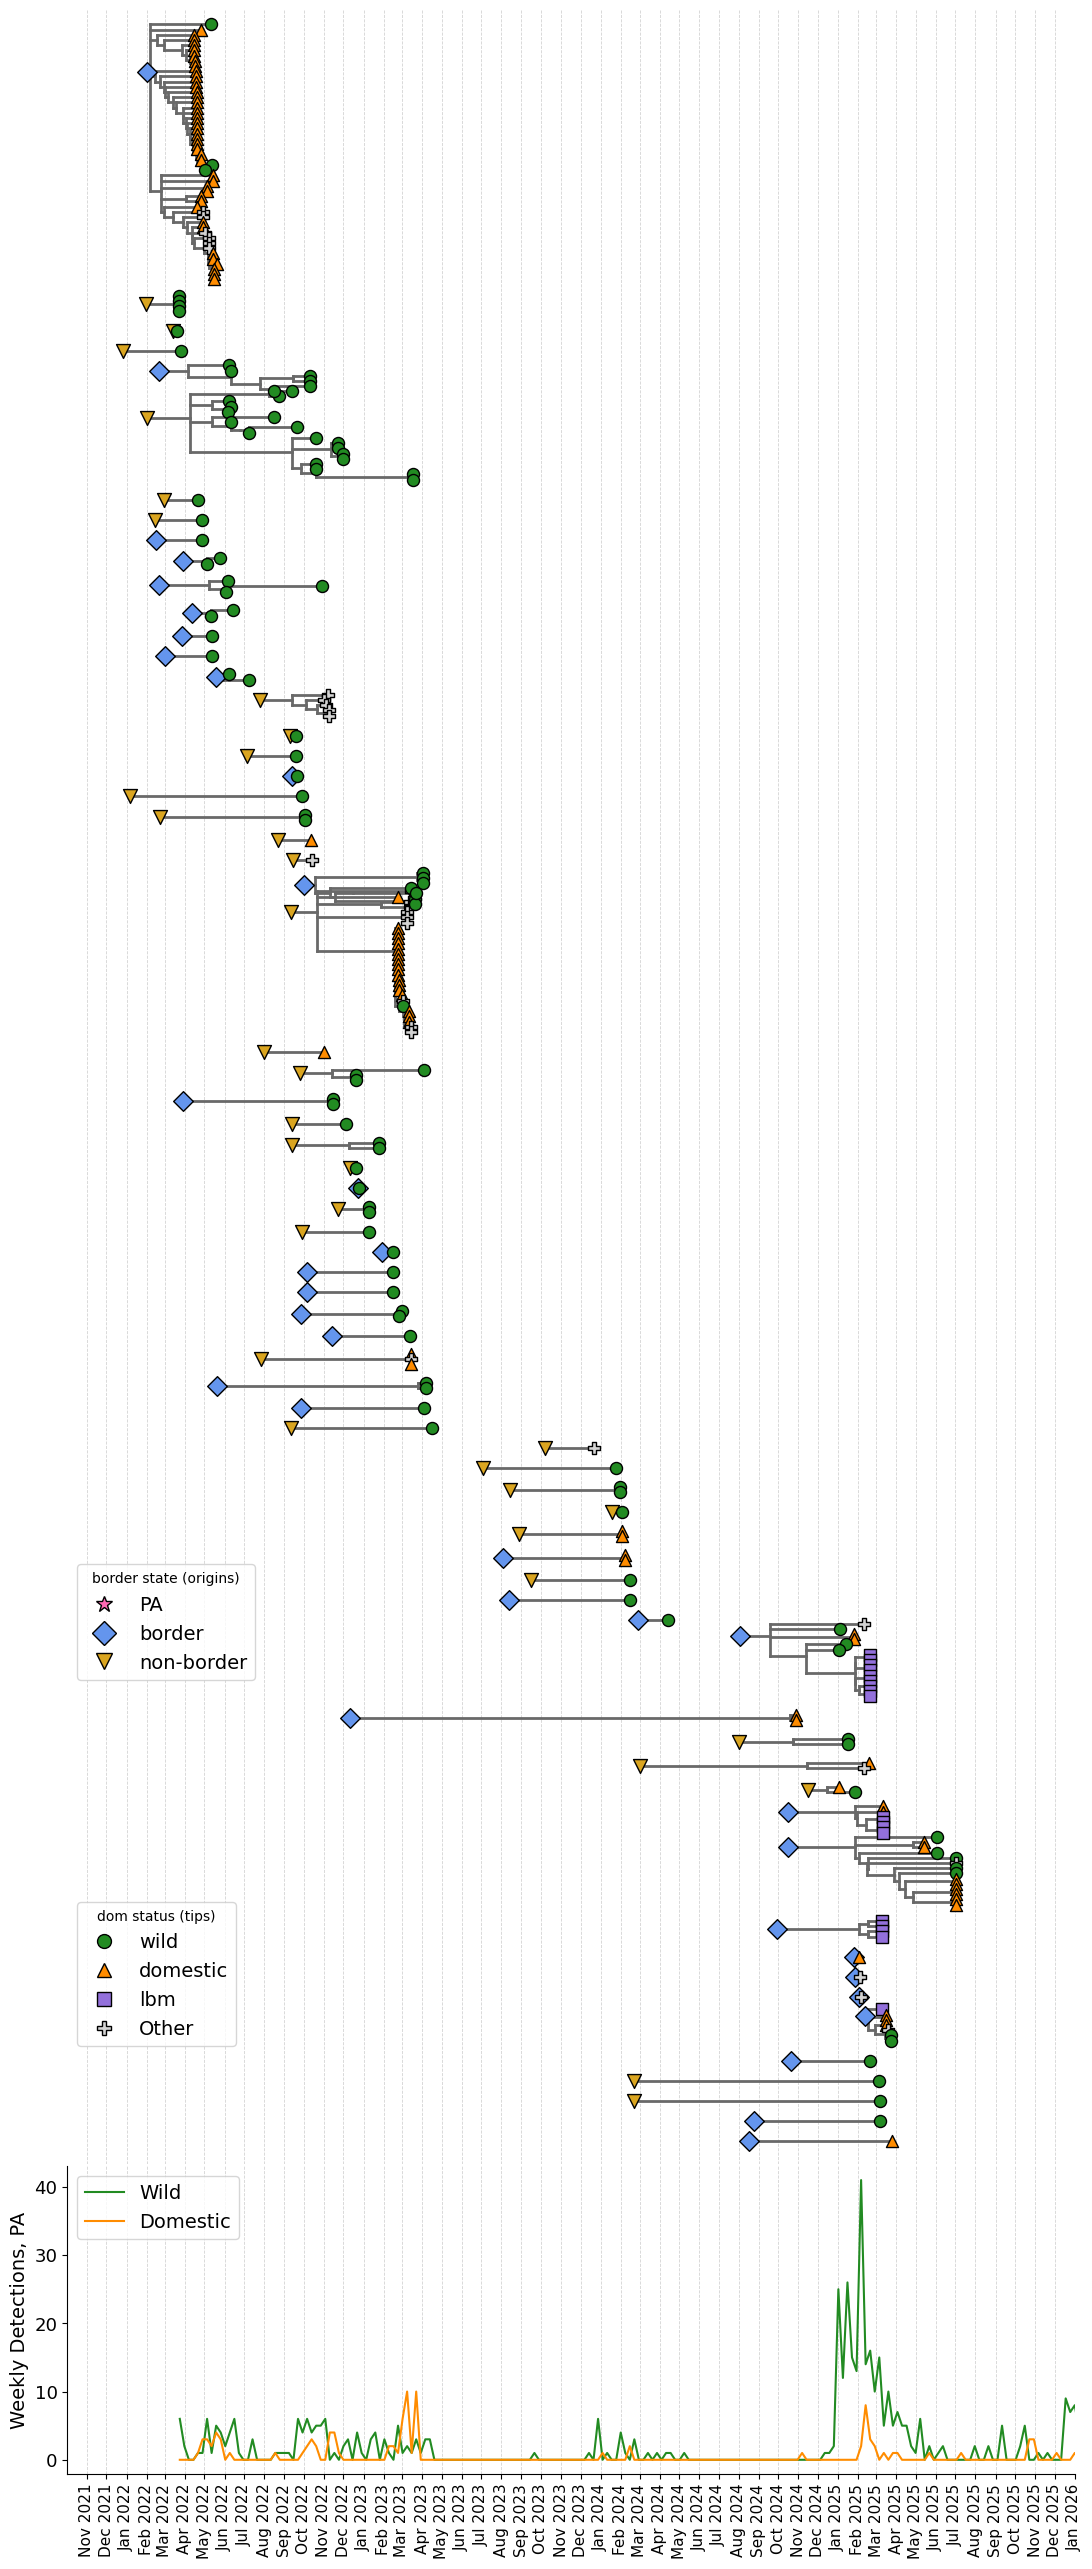

In [81]:
##without defining which tree it is not necessarily going to do HA, so want to explicitly define here!
tree_name = 'treeh5nx_ha'   # or whichever tree you want
tree = trees[tree_name]

plot_tree_with_cases(
    tree_name, tree, tree_strings, subtype_trees, traitName,
    wild_pivot, comm_pivot,
    xlim=(2021.75, 2026),
    tree_height=28,
    cases_height=4,
)

oriX=2024.6260  root.absoluteTime=2025.2290  root.length=0.6030  origin=border  subtree_trait=PA
oriX=2025.1170  root.absoluteTime=2025.1280  root.length=0.0110  origin=border  subtree_trait=PA
oriX=2025.0670  root.absoluteTime=2025.0890  root.length=0.0220  origin=border  subtree_trait=PA
oriX=2024.7430  root.absoluteTime=2025.0890  root.length=0.3460  origin=border  subtree_trait=PA
oriX=2024.7920  root.absoluteTime=2025.0750  root.length=0.2830  origin=border  subtree_trait=PA
oriX=2024.7920  root.absoluteTime=2025.0720  root.length=0.2800  origin=border  subtree_trait=PA
oriX=2024.8730  root.absoluteTime=2024.9550  root.length=0.0820  origin=non-border  subtree_trait=PA
oriX=2024.1650  root.absoluteTime=2024.8690  root.length=0.7040  origin=non-border  subtree_trait=PA
oriX=2022.9420  root.absoluteTime=2024.8000  root.length=1.8580  origin=border  subtree_trait=PA
oriX=2024.5860  root.absoluteTime=2024.7140  root.length=0.1280  origin=border  subtree_trait=PA
oriX=2023.5880  root.a

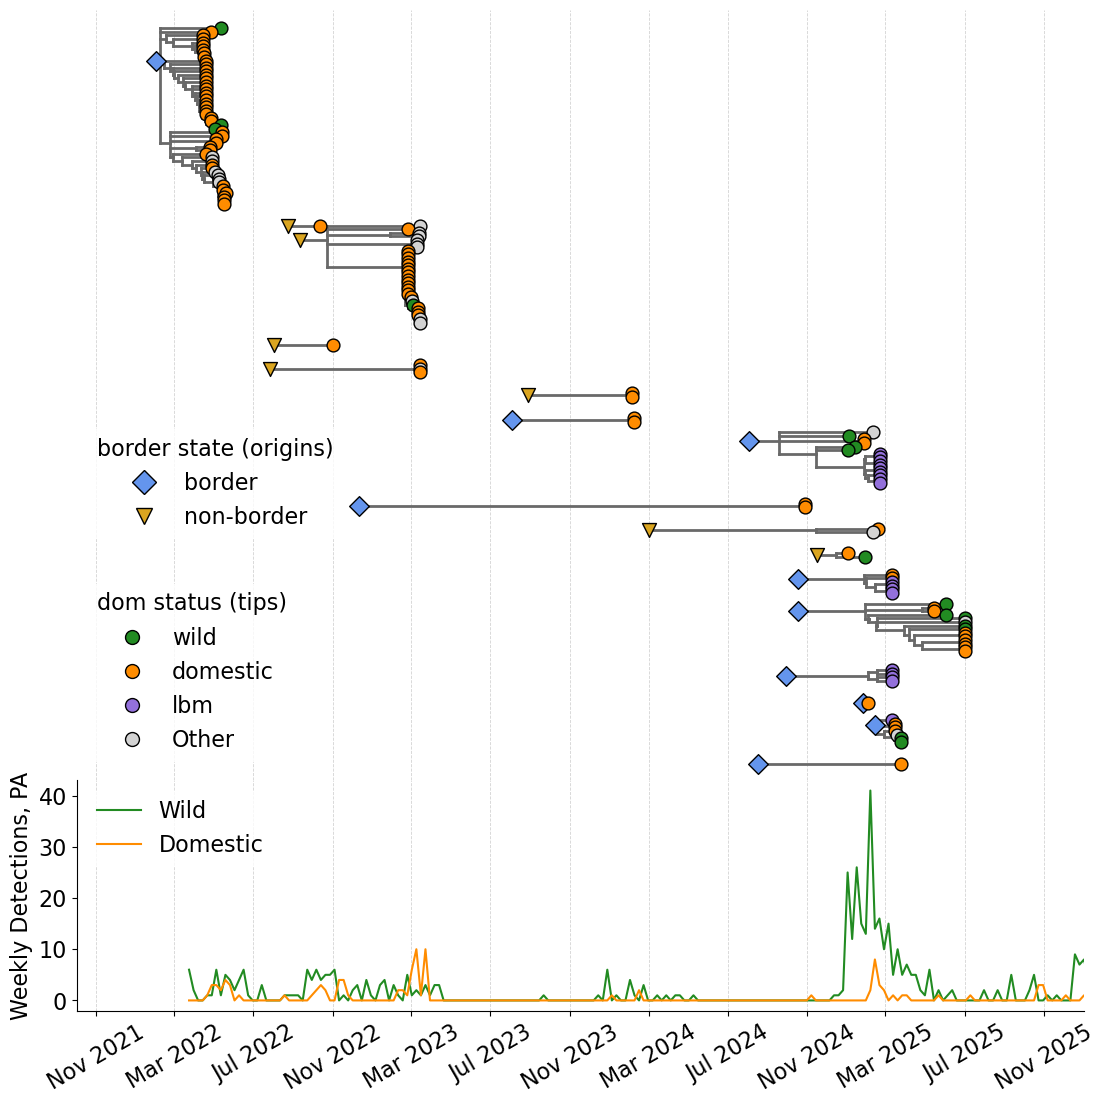

In [82]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from datetime import datetime


# ── HELPER FUNCTIONS ──────────────────────────────────────────────────────────

def date_to_decimal_year(dt):
    """Convert a datetime/Timestamp to a decimal year float."""
    if isinstance(dt, str):
        dt = pd.to_datetime(dt)
    if hasattr(dt, 'to_pydatetime'):
        dt = dt.to_pydatetime()
    year  = dt.year
    start = datetime(year, 1, 1)
    end   = datetime(year + 1, 1, 1)
    return year + (dt - start).total_seconds() / (end - start).total_seconds()


def monthly_decimal_ticks(xlim):
    """Generate decimal-year tick positions and labels for every month in xlim."""
    ticks, labels = [], []
    start_year = int(xlim[0])
    for year in range(start_year, int(xlim[1]) + 2):
        for month in range(1, 13):
            dt = datetime(year, month, 1)
            dy = date_to_decimal_year(dt)
            if xlim[0] <= dy <= xlim[1]:
                ticks.append(dy)
                labels.append(dt.strftime('%b %Y'))
    return ticks, labels


def get_tip_color(node):
    if hasattr(node, 'metadata') and 'wild_dom_lbm' in node.metadata:
        return tip_color_mapping.get(node.metadata['wild_dom_lbm'], tip_color_mapping['Other'])
    return tip_color_mapping['Other']


def get_marker_shape(node):
    if hasattr(node, 'metadata') and 'wild_dom_lbm' in node.metadata:
        return shape_mapping.get(node.metadata['wild_dom_lbm'], shape_mapping['Other'])
    return shape_mapping['Other']


# ── COLOR / SHAPE MAPPINGS ────────────────────────────────────────────────────

tip_color_mapping = {
    'wild':     'forestgreen',
    'domestic': 'darkorange',
    'lbm':      'mediumpurple',
    'Other':    'lightgray'
}

shape_mapping = {
    'wild':     'o',
    'domestic': 'o',
    'lbm':      'o',
    'Other':    'o'
}

origin_shape_mapping = {
    'PA':         '*',
    'border':     'D',
    'non-border': 'v',
    'ancestor':   'o'
}

origin_color_mapping = {
    'PA':         'hotpink',
    'border':     'cornflowerblue',
    'non-border': 'goldenrod',
    'ancestor':   'dimgrey'
}


# ── MAIN PLOT FUNCTION ────────────────────────────────────────────────────────

def plot_tree_with_cases_nowild(tree_name, tree, tree_strings, subtype_trees, traitName,
                         wild_pivot, comm_pivot,
                         xlim=(2021.75, 2026),
                         tree_height=28,
                         cases_height=4,
                         max_cases=None):

    # 1. case bar x-values in decimal years
    full_range   = pd.to_datetime(wild_pivot.index)
    bar_width    = 7 / 365.25
    week_decimal = np.array([
        date_to_decimal_year(d + pd.Timedelta(days=3))
        for d in full_range
    ])
    wild_vals = wild_pivot.sum(axis=1).values
    comm_vals = comm_pivot.sum(axis=1).values

    # 2. figure layout
    fig = plt.figure(figsize=(13, tree_height + cases_height), facecolor='w')
    gs  = gridspec.GridSpec(2, 1,
                            height_ratios=[tree_height, cases_height],
                            hspace=0.001) ##gap between trees and cases
    ax_tree  = fig.add_subplot(gs[0])
    ax_cases = fig.add_subplot(gs[1], sharex=ax_tree)

    # 3. draw subtrees
    tipSize      = 85
    oriSize      = 100
    cumulative_y = 0.05

    for subtype in ['PA', 'border', 'non-border']:
        for tr in sorted(subtype_trees[subtype],
                         key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects))):
            origin, loc_tree = tr
        
            leaf_nodes = [node for node in loc_tree.Objects if node.branchType == "leaf"]
            
            # Get dom_stat values for all tips
            tip_statuses = [
                node.metadata.get("wild_dom_lbm")
                for node in leaf_nodes
                if hasattr(node, "metadata")
            ]

    # If ALL tips are wild → skip this subtree
            # if len(tip_statuses) > 0 and (all(status == "wild" for status in tip_statuses) or all(status == "unknown" for status in tip_statuses)):
       
    # Skip subtree if it does NOT contain at least one lbm or domestic tip
            if not any(status in {"lbm", "domestic"} for status in tip_statuses):
                continue

        

            subtree_trait = loc_tree.root.traits.get(traitName)
            unwanted_pairs = {
                ('non-border', 'border'), ('border', 'non-border'),
                ('PA', 'border'), ('PA', 'non-border'),
                ('PA', 'non_PA')
            }
            if origin == "ancestor" or (origin, subtree_trait) in unwanted_pairs:
                continue

            y_attr = lambda k, cy=cumulative_y: (k.y * 1.3) + cy

            loc_tree.plotTree(ax_tree,
                              x_attr=lambda k: k.absoluteTime,
                              y_attr=y_attr,
                              colour=lambda k: 'dimgray')

            for node in loc_tree.Objects:
                if node.branchType == "leaf":
                    ax_tree.scatter(node.absoluteTime, y_attr(node),
                                    s=tipSize,
                                    facecolor=get_tip_color(node),
                                    edgecolor='black',
                                    marker=get_marker_shape(node),
                                    zorder=150)

            parent_trait = (loc_tree.root.parent.traits.get(traitName)
                            if loc_tree.root.parent is not None else None)
            ori_trait  = parent_trait if parent_trait in origin_shape_mapping else 'ancestor'
            ori_marker = origin_shape_mapping.get(ori_trait, 'o')
            ori_color  = origin_color_mapping.get(ori_trait, 'dimgrey')

            oriX = loc_tree.root.absoluteTime - loc_tree.root.length
            oriY = y_attr(loc_tree.root)
###DEBUG TEST
            print(f"oriX={oriX:.4f}  root.absoluteTime={loc_tree.root.absoluteTime:.4f}  root.length={loc_tree.root.length:.4f}  origin={origin}  subtree_trait={subtree_trait}")

            
            ax_tree.scatter(oriX, oriY, s=oriSize, facecolor=ori_color,
                            edgecolor='black', marker=ori_marker, lw=1, zorder=100)

            cumulative_y += loc_tree.ySpan + 7 ##i think this is space bw subtrees

    # 4. tree axis styling
    ax_tree.set_xlim(xlim)
    ax_tree.set_ylim(-5, cumulative_y + 14)
    ax_tree.set_yticklabels([])
    ax_tree.tick_params(axis='y', size=0)
    ax_tree.tick_params(axis='x', labelbottom=False, size=0)
    [ax_tree.spines[s].set_visible(False) for s in ['top', 'right', 'left', 'bottom']]
    ax_tree.set_title('', fontsize=16)

    # 5. gridlines on both panels
    month_ticks, month_labels = monthly_decimal_ticks(xlim)
    # for t in month_ticks:
    for t in month_ticks[::4]: ##this should just slice to every 4 months
        ax_tree.axvline(t,  color='lightgrey', lw=0.6, ls='--', zorder=1)
        ax_cases.axvline(t, color='lightgrey', lw=0.6, ls='--', zorder=1)

    # 6. tree legends
    tip_handles = [
        mlines.Line2D([0], [0], marker=shape_mapping[lbl], color='w', label=lbl,
                      markerfacecolor=tip_color_mapping[lbl],
                      markeredgecolor='black', markersize=10)
        for lbl in ['wild', 'domestic', 'lbm', 'Other']
    ]
    ori_handles = [
        mlines.Line2D([0], [0], marker=origin_shape_mapping[lbl], color='w', label=lbl,
                      markerfacecolor=origin_color_mapping[lbl],
                      markeredgecolor='black', markersize=12)
        for lbl in ['PA', 'border', 'non-border']
    ]
    tip_leg = ax_tree.legend(handles=tip_handles, title='dom status (tips)',title_fontsize=16,
                             loc='lower left', bbox_to_anchor=(0, 0.01), fontsize=16, edgecolor='white')
    ax_tree.add_artist(tip_leg)

    filtered_handles = [h for h in ori_handles if h.get_label() != 'PA'] ##removing PA from origin legend bc there are none
    
    ax_tree.legend(handles=filtered_handles, title='border state (origins)', title_fontsize=16,
                   loc='lower left', bbox_to_anchor=(0, 0.3), fontsize=16, edgecolor='white')

    
    # ax_tree.legend(handles=ori_handles, title='border state (origins)',
    #                loc='lower left', bbox_to_anchor=(0, 0.22), fontsize=16, edgecolor='white')

    # # 7. case count bars
    # ax_cases.bar(week_decimal, wild_vals,
    #              width=bar_width, color='forestgreen', label='Wild', align='center')
    # ax_cases.bar(week_decimal, comm_vals,
    #              width=bar_width, bottom=wild_vals,
    #              color='darkorange', label='Domestic', align='center')

    
    # 7. case count line
    ax_cases.plot(week_decimal, wild_vals,
                 color='forestgreen', label='Wild')
    ax_cases.plot(week_decimal, comm_vals,
                 color='darkorange', label='Domestic')
    if max_cases:
        ax_cases.set_ylim(0, max_cases)
    ax_cases.set_ylabel('Weekly Detections, PA', fontsize=16)
    ax_cases.tick_params(axis='y', labelsize=16)
    ax_cases.legend(fontsize=16, loc='upper left', edgecolor='white')
    [ax_cases.spines[s].set_visible(False) for s in ['top', 'right']]

    # 8. shared x-axis ticks
    # ax_cases.xaxis.set_major_locator(mticker.FixedLocator(month_ticks))
    # ax_cases.xaxis.set_major_formatter(mticker.FixedFormatter(month_labels))
    ax_cases.xaxis.set_major_locator(mticker.FixedLocator(month_ticks[::4])) ##every 4 months
    ax_cases.xaxis.set_major_formatter(mticker.FixedFormatter(month_labels[::4]))
    ax_cases.tick_params(axis='x', labelsize=16, rotation=30)

    # 9. save
    output_filename = f"../output_plots/comonly_{tree_name}_{todays_date}.png"
    plt.savefig(output_filename, bbox_inches='tight', pad_inches=0.1)
    plt.show()


# ── LOOP ──────────────────────────────────────────────────────────────────────

# for tree_name, tree in trees.items():
#     print(f"Processing and plotting subtrees for {tree_name}")
#     tree_strings, subtype_trees, tip_counts, transitions = process_tree(tree, traitName)

#     df_counts     = pd.DataFrame(tip_counts, columns=['origin_trait', 'tip_trait', 'count'])
#     unique_counts = df_counts.groupby(['origin_trait', 'tip_trait', 'count']).size().reset_index(name='frequency')
#     unique_counts_dict[tree_name] = unique_counts
#     transitions_dict[tree_name]   = transitions

#     for subtype in ['PA', 'border', 'non-border']:
#         for tr in sorted(subtype_trees[subtype],
#                          key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects))):
#             origin, loc_tree = tr
#             oriX = loc_tree.root.absoluteTime - loc_tree.root.length
#             oriX_values[tree_name][(origin, subtype)].append(oriX)
#             latest_tip_dates[tree_name][(origin, subtype)].append(return_newest_tip(loc_tree))

#     plot_tree_with_cases(
#         tree_name, tree, tree_strings, subtype_trees, traitName,
#         wild_pivot, comm_pivot,
#         xlim=(2020, 2026),
#         tree_height=28,
#         cases_height=4,
#     )


# plot_tree_with_cases_nowild(
#     tree_name, tree, tree_strings, subtype_trees, traitName,
#     wild_pivot, comm_pivot,
#     xlim=(2020, 2026),
#     tree_height=10,
#     cases_height=3,
# )
tree_name = 'treeh5nx_ha'   # or whichever tree you want
tree = trees[tree_name]
# tree_strings, subtype_trees, tip_counts, transitions = process_tree(tree, traitName)

plot_tree_with_cases_nowild(
    tree_name, tree, tree_strings, subtype_trees, traitName,
    wild_pivot, comm_pivot,
    xlim=(2021.75, 2026),
    tree_height=10,
    cases_height=3,
)

In [22]:
# wild_pivot = pd.read_csv('../output_dfs/wild_pivot.csv', index_col=0,)
comm_nolbm_pivot = pd.read_csv('../output_dfs/comm_nolbm_pivot.csv', index_col=0,)
# comm_pivot = pd.read_csv('../output_dfs/comm_pivot.csv', index_col=0,)

lbm_pivot = pd.read_csv('../output_dfs/lbm_pivot.csv', index_col=0,)

In [23]:
lbm_pivot

,Pennsylvania
2022-03-21,0.0
2022-03-28,0.0
2022-04-04,0.0
2022-04-11,0.0
2022-04-18,0.0
...,...
2026-03-09,0.0
2026-03-16,0.0
2026-03-23,0.0
2026-03-30,0.0


In [24]:
pa_comm_nolbm = pd.read_csv('../../comm-pa/output_dfs/pa_comm_nolbm.csv')
pa_wild = pd.read_csv('../../comm-pa/output_dfs/pa_wild.csv')
pa_lbm = pd.read_csv('../../comm-pa/output_dfs/pa_lbm.csv')
pa_lbm

,Unnamed: 0,Special ID,County Name,State,Production,Collection Date,Control Area Released,Unnamed: 6
0,143,Philadelphia 04,Philadelphia,Pennsylvania,Live Bird Market,2026-02-02,NaN,60
1,144,Philadelphia 05,Philadelphia,Pennsylvania,Live Bird Market,2026-02-02,NaN,440
2,179,Philadelphia 03,Philadelphia,Pennsylvania,Live Bird Market,2026-01-09,NaN,"2,100"
3,182,Lehigh 09,Lehigh,Pennsylvania,Live Bird Market,2026-01-08,NaN,600
4,503,Lehigh 08,Lehigh,Pennsylvania,Live Bird Market,2025-03-13,NaN,350
5,509,Philadelphia 02,Philadelphia,Pennsylvania,Live Bird Market,2025-03-12,NaN,420
6,542,Philadelphia 01,Philadelphia,Pennsylvania,Live Bird Market,2025-02-24,NaN,"1,100"


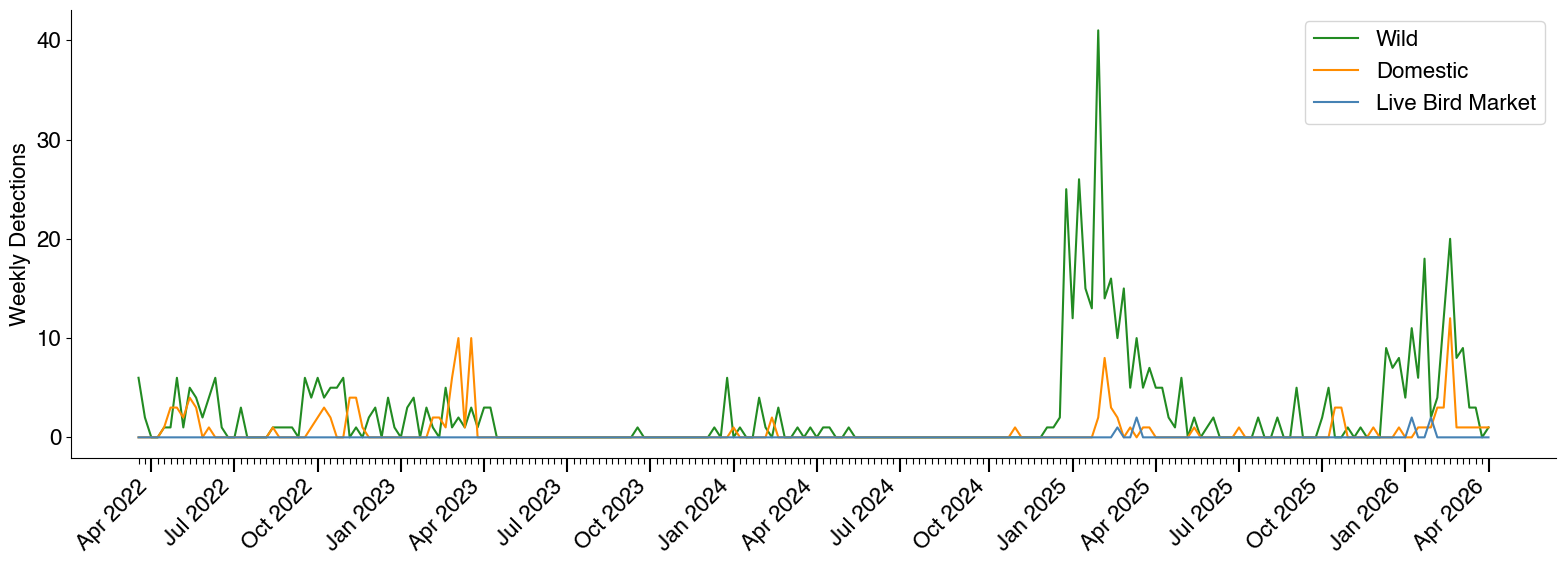

In [25]:
###making version with comm split up to lbm and comm(no lbm)
pa_comm_nolbm['Collection Date'] = pd.to_datetime(pa_comm_nolbm['Collection Date'], errors='coerce')
pa_wild['Collection Date'] = pd.to_datetime(pa_wild['Collection Date'], errors='coerce')
pa_lbm['Collection Date'] = pd.to_datetime(pa_lbm['Collection Date'], errors='coerce')


def make_weekly_pivot(df):
    weekly = (
        df.groupby(['State', pd.Grouper(key='Collection Date', freq='W-MON')])
        .size()
        .reset_index(name='cases')
    )
    pivot = weekly.pivot_table(index='Collection Date', columns='State', values='cases', fill_value=0)
    return pivot

wild_pivot = make_weekly_pivot(pa_wild)
comm_pivot = make_weekly_pivot(pa_comm_nolbm)
lbm_pivot  = make_weekly_pivot(pa_lbm)

# Align all three to the same full date range
full_range = pd.date_range(
    start=min(wild_pivot.index.min(), comm_pivot.index.min(), lbm_pivot.index.min()),
    end=max(wild_pivot.index.max(), comm_pivot.index.max(), lbm_pivot.index.max()),
    freq='W-MON'
)
wild_pivot = wild_pivot.reindex(full_range, fill_value=0)
comm_pivot = comm_pivot.reindex(full_range, fill_value=0)
lbm_pivot  = lbm_pivot.reindex(full_range, fill_value=0)

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(range(len(full_range)), wild_pivot.sum(axis=1).values, color='forestgreen', label='Wild')
ax.plot(range(len(full_range)), comm_pivot.sum(axis=1).values, color='darkorange',  label='Domestic')
ax.plot(range(len(full_range)), lbm_pivot.sum(axis=1).values,  color='steelblue',   label='Live Bird Market')

# --- Quarterly x-axis ticks ---
major_positions, major_labels = [], []
seen_months = set()
for i, d in enumerate(full_range):
    month_key = (d.year, d.month)
    if month_key not in seen_months and d.month in {1, 4, 7, 10}:
        seen_months.add(month_key)
        major_positions.append(i)
        major_labels.append(d.strftime('%b %Y'))

ax.set_xticks(major_positions)
ax.set_xticklabels(major_labels, rotation=45, ha='right', fontsize=16)
ax.set_xticks(range(len(full_range)), minor=True)
ax.set_xticklabels([], minor=True)
ax.tick_params(axis='x', which='major', length=10, width=1.5)
ax.tick_params(axis='x', which='minor', length=4, width=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='y', labelsize=16)
ax.set_ylabel('Weekly Detections', fontsize=16)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()

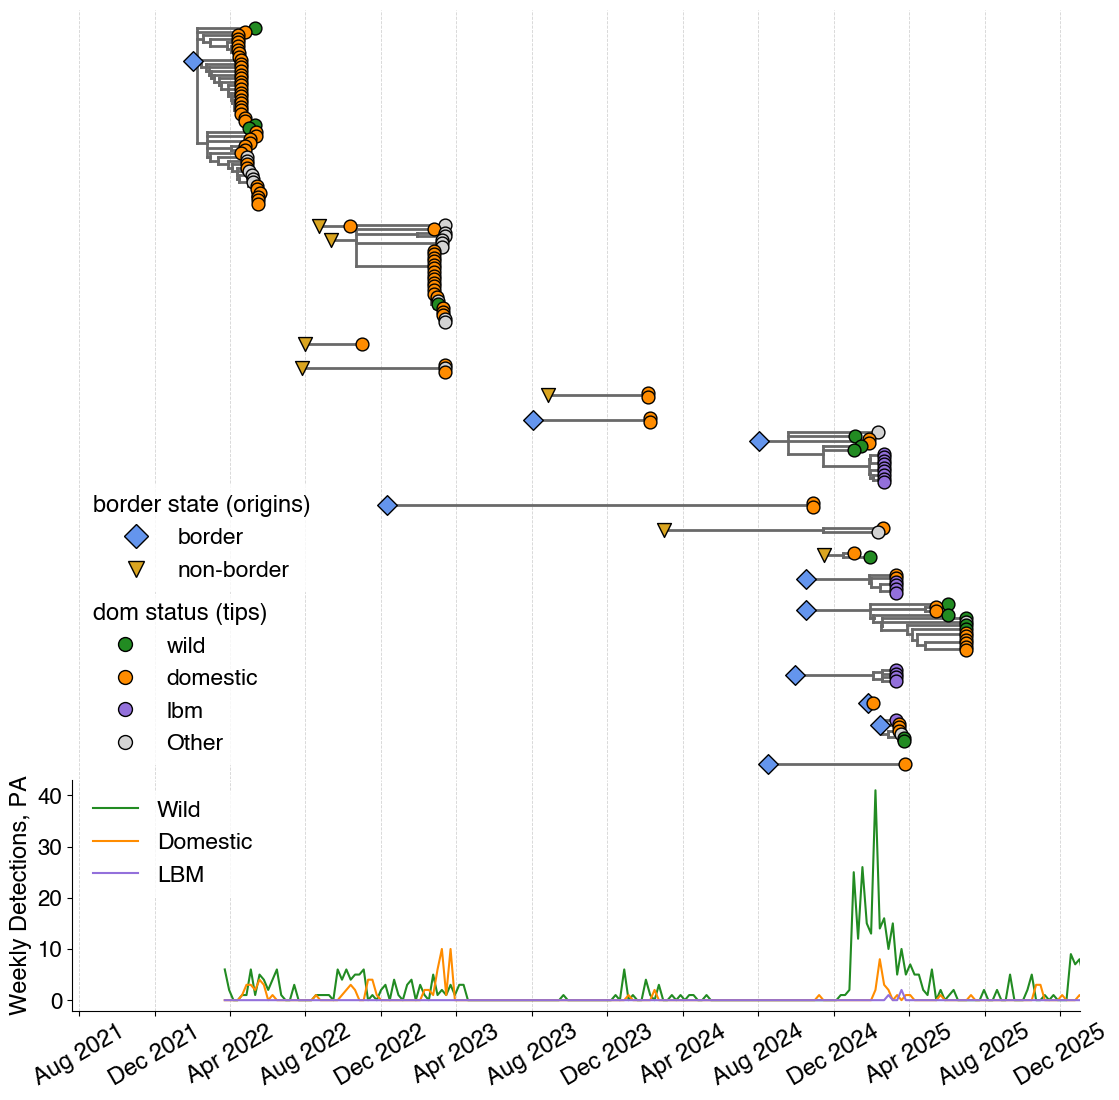

In [32]:
##trying to make this work with LBM cases too
import matplotlib.ticker as mticker

# ── HELPER FUNCTIONS ──────────────────────────────────────────────────────────

def date_to_decimal_year(dt):
    """Convert a datetime/Timestamp to a decimal year float."""
    if isinstance(dt, str):
        dt = pd.to_datetime(dt)
    if hasattr(dt, 'to_pydatetime'):
        dt = dt.to_pydatetime()
    year  = dt.year
    start = datetime(year, 1, 1)
    end   = datetime(year + 1, 1, 1)
    return year + (dt - start).total_seconds() / (end - start).total_seconds()


def monthly_decimal_ticks(xlim):
    """Generate decimal-year tick positions and labels for every month in xlim."""
    ticks, labels = [], []
    start_year = int(xlim[0])
    for year in range(start_year, int(xlim[1]) + 2):
        for month in range(1, 13):
            dt = datetime(year, month, 1)
            dy = date_to_decimal_year(dt)
            if xlim[0] <= dy <= xlim[1]:
                ticks.append(dy)
                labels.append(dt.strftime('%b %Y'))
    return ticks, labels


def get_tip_color(node):
    if hasattr(node, 'metadata') and 'wild_dom_lbm' in node.metadata:
        return tip_color_mapping.get(node.metadata['wild_dom_lbm'], tip_color_mapping['Other'])
    return tip_color_mapping['Other']


def get_marker_shape(node):
    if hasattr(node, 'metadata') and 'wild_dom_lbm' in node.metadata:
        return shape_mapping.get(node.metadata['wild_dom_lbm'], shape_mapping['Other'])
    return shape_mapping['Other']


# ── COLOR / SHAPE MAPPINGS ────────────────────────────────────────────────────

tip_color_mapping = {
    'wild':     'forestgreen',
    'domestic': 'darkorange',
    'lbm':      'mediumpurple',
    'Other':    'lightgray'
}

shape_mapping = {
    'wild':     'o',
    'domestic': 'o',
    'lbm':      'o',
    'Other':    'o'
}

origin_shape_mapping = {
    'PA':         '*',
    'border':     'D',
    'non-border': 'v',
    'ancestor':   'o'
}

origin_color_mapping = {
    'PA':         'hotpink',
    'border':     'cornflowerblue',
    'non-border': 'goldenrod',
    'ancestor':   'dimgrey'
}


# ── MAIN PLOT FUNCTION ────────────────────────────────────────────────────────

def plot_tree_with_cases_nowild(tree_name, tree, tree_strings, subtype_trees, traitName,
                         wild_pivot, comm_pivot, lbm_pivot,
                         xlim=(2021.75, 2026),
                         tree_height=28,
                         cases_height=4,
                         max_cases=None):

    # 1. case bar x-values in decimal years
    full_range   = pd.to_datetime(wild_pivot.index)
    bar_width    = 7 / 365.25
    week_decimal = np.array([
        date_to_decimal_year(d + pd.Timedelta(days=3))
        for d in full_range
    ])
    wild_vals = wild_pivot.sum(axis=1).values
    comm_vals = comm_pivot.sum(axis=1).values
    lbm_vals  = lbm_pivot.sum(axis=1).values

    # 2. figure layout
    fig = plt.figure(figsize=(13, tree_height + cases_height), facecolor='w')
    gs  = gridspec.GridSpec(2, 1,
                            height_ratios=[tree_height, cases_height],
                            hspace=0.001) ##gap between trees and cases
    ax_tree  = fig.add_subplot(gs[0])
    ax_cases = fig.add_subplot(gs[1], sharex=ax_tree)

    # 3. draw subtrees
    tipSize      = 85
    oriSize      = 100
    cumulative_y = 0.05

    for subtype in ['PA', 'border', 'non-border']:
        for tr in sorted(subtype_trees[subtype],
                         key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects))):
            origin, loc_tree = tr
        
            leaf_nodes = [node for node in loc_tree.Objects if node.branchType == "leaf"]
            
            # Get dom_stat values for all tips
            tip_statuses = [
                node.metadata.get("wild_dom_lbm")
                for node in leaf_nodes
                if hasattr(node, "metadata")
            ]

    # If ALL tips are wild → skip this subtree
            # if len(tip_statuses) > 0 and (all(status == "wild" for status in tip_statuses) or all(status == "unknown" for status in tip_statuses)):
       
    # Skip subtree if it does NOT contain at least one lbm or domestic tip
            if not any(status in {"lbm", "domestic"} for status in tip_statuses):
                continue

        

            subtree_trait = loc_tree.root.traits.get(traitName)
            unwanted_pairs = {
                ('non-border', 'border'), ('border', 'non-border'),
                ('PA', 'border'), ('PA', 'non-border'),
                ('PA', 'non_PA')
            }
            if origin == "ancestor" or (origin, subtree_trait) in unwanted_pairs:
                continue

            y_attr = lambda k, cy=cumulative_y: (k.y * 1.3) + cy

            loc_tree.plotTree(ax_tree,
                              x_attr=lambda k: k.absoluteTime,
                              y_attr=y_attr,
                              colour=lambda k: 'dimgray')

            for node in loc_tree.Objects:
                if node.branchType == "leaf":
                    ax_tree.scatter(node.absoluteTime, y_attr(node),
                                    s=tipSize,
                                    facecolor=get_tip_color(node),
                                    edgecolor='black',
                                    marker=get_marker_shape(node),
                                    zorder=150)

            parent_trait = (loc_tree.root.parent.traits.get(traitName)
                            if loc_tree.root.parent is not None else None)
            ori_trait  = parent_trait if parent_trait in origin_shape_mapping else 'ancestor'
            ori_marker = origin_shape_mapping.get(ori_trait, 'o')
            ori_color  = origin_color_mapping.get(ori_trait, 'dimgrey')

            oriX = loc_tree.root.absoluteTime - loc_tree.root.length
            oriY = y_attr(loc_tree.root)
            ax_tree.scatter(oriX, oriY, s=oriSize, facecolor=ori_color,
                            edgecolor='black', marker=ori_marker, lw=1, zorder=100)

            cumulative_y += loc_tree.ySpan + 7 ##i think this is space bw subtrees

    # 4. tree axis styling
    ax_tree.set_xlim(xlim)
    ax_tree.set_ylim(-5, cumulative_y + 14)
    ax_tree.set_yticklabels([])
    ax_tree.tick_params(axis='y', size=0)
    ax_tree.tick_params(axis='x', labelbottom=False, size=0)
    [ax_tree.spines[s].set_visible(False) for s in ['top', 'right', 'left', 'bottom']]
    ax_tree.set_title('', fontsize=16)

    # 5. gridlines on both panels
    month_ticks, month_labels = monthly_decimal_ticks(xlim)
    # for t in month_ticks:
    for t in month_ticks[::4]: ##this should just slice to every 4 months
        ax_tree.axvline(t,  color='lightgrey', lw=0.6, ls='--', zorder=1)
        ax_cases.axvline(t, color='lightgrey', lw=0.6, ls='--', zorder=1)

    # 6. tree legends
    tip_handles = [
        mlines.Line2D([0], [0], marker=shape_mapping[lbl], color='w', label=lbl,
                      markerfacecolor=tip_color_mapping[lbl],
                      markeredgecolor='black', markersize=10)
        for lbl in ['wild', 'domestic', 'lbm', 'Other']
    ]
    ori_handles = [
        mlines.Line2D([0], [0], marker=origin_shape_mapping[lbl], color='w', label=lbl,
                      markerfacecolor=origin_color_mapping[lbl],
                      markeredgecolor='black', markersize=12)
        for lbl in ['PA', 'border', 'non-border']
    ]
    tip_leg = ax_tree.legend(handles=tip_handles, title='dom status (tips)',title_fontsize=17,
                             loc='lower left', bbox_to_anchor=(0, 0.005), fontsize=16.5, edgecolor='white')
    ax_tree.add_artist(tip_leg)

    filtered_handles = [h for h in ori_handles if h.get_label() != 'PA'] ##removing PA from origin legend bc there are none
    
    ax_tree.legend(handles=filtered_handles, title='border state (origins)', title_fontsize=17,
                   loc='lower left', bbox_to_anchor=(0, 0.23), fontsize=16.5, edgecolor='white')

    
    # ax_tree.legend(handles=ori_handles, title='border state (origins)',
    #                loc='lower left', bbox_to_anchor=(0, 0.22), fontsize=16, edgecolor='white')

    # # 7. case count bars
    # ax_cases.bar(week_decimal, wild_vals,
    #              width=bar_width, color='forestgreen', label='Wild', align='center')
    # ax_cases.bar(week_decimal, comm_vals,
    #              width=bar_width, bottom=wild_vals,
    #              color='darkorange', label='Domestic', align='center')

    
    # 7. case count line
    ax_cases.plot(week_decimal, wild_vals,
                 color='forestgreen', label='Wild')
    ax_cases.plot(week_decimal, comm_vals,
                 color='darkorange', label='Domestic')
    ax_cases.plot(week_decimal, lbm_vals,
                 color='mediumpurple', label='LBM')
    if max_cases:
        ax_cases.set_ylim(0, max_cases)
    ax_cases.set_ylabel('Weekly Detections, PA', fontsize=17)
    ax_cases.tick_params(axis='y', labelsize=16)
    ax_cases.legend(fontsize=16.5, loc='upper left', edgecolor='white')
    [ax_cases.spines[s].set_visible(False) for s in ['top', 'right']]

    # 8. shared x-axis ticks
    # ax_cases.xaxis.set_major_locator(mticker.FixedLocator(month_ticks))
    # ax_cases.xaxis.set_major_formatter(mticker.FixedFormatter(month_labels))
    ax_cases.xaxis.set_major_locator(mticker.FixedLocator(month_ticks[::4])) ##every 4 months
    ax_cases.xaxis.set_major_formatter(mticker.FixedFormatter(month_labels[::4]))
    ax_cases.tick_params(axis='x', labelsize=17, rotation=30)

    # 9. save
    output_filename = f"../output_plots/comonly_wildcommlbmcases_{tree_name}_{todays_date}.png"
    plt.savefig(output_filename, bbox_inches='tight', pad_inches=0.1)
    plt.show()


# ── LOOP ──────────────────────────────────────────────────────────────────────

# for tree_name, tree in trees.items():
#     print(f"Processing and plotting subtrees for {tree_name}")
#     tree_strings, subtype_trees, tip_counts, transitions = process_tree(tree, traitName)

#     df_counts     = pd.DataFrame(tip_counts, columns=['origin_trait', 'tip_trait', 'count'])
#     unique_counts = df_counts.groupby(['origin_trait', 'tip_trait', 'count']).size().reset_index(name='frequency')
#     unique_counts_dict[tree_name] = unique_counts
#     transitions_dict[tree_name]   = transitions

#     for subtype in ['PA', 'border', 'non-border']:
#         for tr in sorted(subtype_trees[subtype],
#                          key=lambda x: (-x[1].root.absoluteTime, len(x[1].Objects))):
#             origin, loc_tree = tr
#             oriX = loc_tree.root.absoluteTime - loc_tree.root.length
#             oriX_values[tree_name][(origin, subtype)].append(oriX)
#             latest_tip_dates[tree_name][(origin, subtype)].append(return_newest_tip(loc_tree))

#     plot_tree_with_cases(
#         tree_name, tree, tree_strings, subtype_trees, traitName,
#         wild_pivot, comm_pivot,
#         xlim=(2020, 2026),
#         tree_height=28,
#         cases_height=4,
#     )

tree_name = 'treeh5nx_ha'   # or whichever tree you want
tree = trees[tree_name]

plot_tree_with_cases_nowild(
    tree_name, tree, tree_strings, subtype_trees, traitName,
    wild_pivot, comm_pivot, lbm_pivot,
    xlim=(2021.55, 2026),
    tree_height=10,
    cases_height=3,
)

In [103]:
lbm_pivot

,Pennsylvania
2022-03-21,0.0
2022-03-28,0.0
2022-04-04,0.0
2022-04-11,0.0
2022-04-18,0.0
...,...
2026-03-09,0.0
2026-03-16,0.0
2026-03-23,0.0
2026-03-30,0.0


In [101]:
print(lbm_pivot.shape)
print(lbm_pivot.sum(axis=1).sum())   # should be > 0
print(lbm_pivot.index[:3])           # check index type/format
print(comm_pivot.index[:3])          # compare to the others
print(wild_pivot.index[:3])

(212, 1)
7.0
Index(['2022-03-21', '2022-03-28', '2022-04-04'], dtype='object')
Index(['2022-03-21', '2022-03-28', '2022-04-04'], dtype='object')
Index(['2022-03-07', '2022-03-14', '2022-03-21'], dtype='object')


In [120]:
pa_clust = combined_tip_counts_df[(combined_tip_counts_df["source_tree"] == "h5nx_ha") & (combined_tip_counts_df["border_state"] == "PA")]
pa_clust

,subtree_name,leaf_count,origin_date,origin,pa_status,wild_dom_lbm,border_state,source_tree,last_tip_date,subtree_duration_days
0,PA_0,1,2022-09-14,non-border,Pennsylvania,wild,PA,h5nx_ha,2023-04-16,214
1,PA_1,1,2022-11-09,border,Pennsylvania,wild,PA,h5nx_ha,2023-03-13,124
2,PA_10,1,2022-08-22,non-border,Pennsylvania,NaN,PA,h5nx_ha,2022-10-13,52
3,PA_11,2,2022-12-01,non-border,Pennsylvania,wild,PA,h5nx_ha,2023-01-09,39
4,PA_12,3,2022-10-07,non-border,Pennsylvania,wild,PA,h5nx_ha,2023-04-03,178
...,...,...,...,...,...,...,...,...,...,...
63,PA_55,3,2022-08-08,non-border,Pennsylvania,NaN,PA,h5nx_ha,2023-03-14,218
64,PA_6,1,2022-09-12,border,Pennsylvania,wild,PA,h5nx_ha,2022-09-20,8
65,PA_7,1,2022-04-10,non-border,Pennsylvania,wild,PA,h5nx_ha,2022-04-27,17
66,PA_8,1,2022-08-12,non-border,Pennsylvania,domestic,PA,h5nx_ha,2022-10-31,80


In [73]:
combined_tip_counts_df.tail(5)

,subtree_name,leaf_count,origin_date,origin,pa_status,wild_dom_lbm,source_tree,last_tip_date,subtree_duration_days
102,non_PA_5,1,2024-12-12,Pennsylvania,non_PA,wild,northam_ha,2025-01-16,35
103,non_PA_6,1,2024-12-11,Pennsylvania,non_PA,NaN,northam_ha,2025-01-28,48
104,non_PA_7,1,2024-12-21,Pennsylvania,non_PA,domestic,northam_ha,2025-02-03,44
105,non_PA_8,1,2024-12-25,Pennsylvania,non_PA,domestic,northam_ha,2025-03-06,71
106,non_PA_9,1,2025-03-19,Pennsylvania,non_PA,domestic,northam_ha,2025-03-31,12


In [121]:
from datetime import datetime, timedelta

def decimal_year_to_date(decimal_year):
    year = int(decimal_year)
    remainder = decimal_year - year
    # handle leap years
    days_in_year = 366 if (year % 400 == 0 or (year % 100 != 0 and year % 4 == 0)) else 365
    return datetime(year, 1, 1) + timedelta(days=remainder * days_in_year)

# Convert your columns
combined_df["origin_date_dt"] = combined_df["origin_date"].apply(decimal_year_to_date)
combined_df["tip_date_dt"] = combined_df["num_date"].apply(decimal_year_to_date)
combined_df

,branchType,absoluteTime,length,origin,origin_date,subtree_name,name,branch_attrs,divergence,num_date,...,host,originating_lab,division,order,domestic_status,domestic_status_confidence,county,source_tree,origin_date_dt,tip_date_dt
0,node,2021.756,0.000,ancestor,2021.756,non-border_0,NODE_0000000,{'mutations': {}},0.00000,2021.756,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,h5nx_ha,2021-10-03 22:33:36.000003,2021-10-03 22:33:36.000003
1,node,2022.249,0.493,ancestor,2021.756,non-border_0,NODE_0001757,"{'mutations': {'nuc': ['C488T', 'A654G', 'G157...",0.00222,2022.249,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,h5nx_ha,2021-10-03 22:33:36.000003,2022-04-01 21:14:24.000001
2,leaf,2023.084,0.835,ancestor,2021.756,non-border_0,A/CanadaGoose/PE/FAV00681/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00560,2023.084,...,Avian,"Atlantic Veterinary College, University Of Pri...",Prince Edward Island,anseriformes,NaN,NaN,NaN,h5nx_ha,2021-10-03 22:33:36.000003,2023-01-31 15:50:24.000002
3,node,2022.565,0.316,ancestor,2021.756,non-border_0,NODE_0001758,"{'mutations': {'nuc': ['G161A', 'A239C', 'T854...",0.00388,2022.565,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,h5nx_ha,2021-10-03 22:33:36.000003,2022-07-26 05:24:00.000002
4,leaf,2023.221,0.656,ancestor,2021.756,non-border_0,A/CanadaGoose/NS/FAV01224/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00618,2023.221,...,Avian,"Atlantic Veterinary College, University Of Pri...",Nova Scotia,anseriformes,NaN,NaN,NaN,h5nx_ha,2021-10-03 22:33:36.000003,2023-03-22 15:57:36.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11861,leaf,2022.360,0.627,non-border,2021.733,PA_2,A/turkeyvulture/Pennsylvania/22016661001/2022,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00747,2022.360,...,Avian,"Usda, Aphis, Veterinary Services, Diagnostic V...",Pennsylvania,accipitriformes,wild,{'wild': 1.0},NaN,mini_ha,2021-09-25 13:04:47.999998,2022-05-12 09:35:59.999997
11862,leaf,2022.319,0.525,non-border,2021.794,PA_3,A/baldeagle/Pennsylvania/22021649001/2022,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00862,2022.319,...,Avian,"Usda, Aphis, Veterinary Services, Diagnostic V...",Pennsylvania,accipitriformes,wild,{'wild': 1.0},NaN,mini_ha,2021-10-17 19:26:24.000003,2022-04-27 10:26:23.999999
11863,leaf,2022.832,0.546,non-border,2022.286,PA_4,A/chicken/Pennsylvania/22034995001original/2022,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00862,2022.832,...,Avian,National Veterinary Services Laboratories Usda,Pennsylvania,galliformes,domestic,{'domestic': 1.0},NaN,mini_ha,2022-04-15 09:21:36.000002,2022-10-31 16:19:12.000003
11864,leaf,2023.884,0.636,non-border,2023.248,border_0,A/chicken/Maryland/23036657001original/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00690,2023.884,...,Avian,National Veterinary Services Laboratories Usda,Maryland,galliformes,domestic,{'domestic': 1.0},NaN,mini_ha,2023-04-01 12:28:48.000001,2023-11-19 15:50:24.000000


In [122]:
df_leaves = combined_df[combined_df["branchType"] == "leaf"].copy()
def closest_tip(group):
    origin = group["origin_date_dt"].iloc[0]
    # compute absolute difference from origin
    group["diff"] = (group["tip_date_dt"] - origin).abs()
    # pick tip with smallest difference
    return group.loc[group["diff"].idxmin(), "tip_date_dt"]

earliest_tips = df_leaves.groupby("subtree_name").apply(closest_tip).reset_index()
earliest_tips.rename(columns={0: "earliest_tip"}, inplace=True)
df_leaves = df_leaves.merge(earliest_tips, on="subtree_name", how="left")
df_leaves["earliest_tip"] = pd.to_datetime(df_leaves["earliest_tip"]).dt.date
df_leaves["origin_date_dt"] = pd.to_datetime(df_leaves["origin_date_dt"]).dt.date

df_leaves

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_61408/3255202994.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  earliest_tips = df_leaves.groupby("subtree_name").apply(closest_tip).reset_index()


,branchType,absoluteTime,length,origin,origin_date,subtree_name,name,branch_attrs,divergence,num_date,...,originating_lab,division,order,domestic_status,domestic_status_confidence,county,source_tree,origin_date_dt,tip_date_dt,earliest_tip
0,leaf,2023.084,0.835,ancestor,2021.756,non-border_0,A/CanadaGoose/PE/FAV00681/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00560,2023.084,...,"Atlantic Veterinary College, University Of Pri...",Prince Edward Island,anseriformes,NaN,NaN,NaN,h5nx_ha,2021-10-03,2023-01-31 15:50:24.000002,2021-12-02
1,leaf,2023.221,0.656,ancestor,2021.756,non-border_0,A/CanadaGoose/NS/FAV01224/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00618,2023.221,...,"Atlantic Veterinary College, University Of Pri...",Nova Scotia,anseriformes,NaN,NaN,NaN,h5nx_ha,2021-10-03,2023-03-22 15:57:36.000000,2021-12-02
2,leaf,2022.801,0.236,ancestor,2021.756,non-border_0,A/CommonGoldeneye/QC/FAV14533/2022,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00501,2022.801,...,Laboratoire De Santé Animale Ministère De L'ag...,Quebec,anseriformes,NaN,NaN,NaN,h5nx_ha,2021-10-03,2022-10-20 08:45:35.999998,2021-12-02
3,leaf,2022.930,0.287,ancestor,2021.756,non-border_0,A/SnowGoose/ON/FAV16721/2022,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00499,2022.930,...,"Ontario Veterinary College, University Of Guelph",Ontario,anseriformes,wild,{'wild': 1.0},NaN,h5nx_ha,2021-10-03,2022-12-06 10:48:00.000002,2021-12-02
4,leaf,2023.275,0.586,ancestor,2021.756,non-border_0,A/Chicken/QC/FAV01464/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00723,2023.275,...,Canadian Food Inspection Agency,Quebec,galliformes,domestic,{'domestic': 1.0},NaN,h5nx_ha,2021-10-03,2023-04-11 09:00:00.000003,2021-12-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6727,leaf,2022.360,0.627,non-border,2021.733,PA_2,A/turkeyvulture/Pennsylvania/22016661001/2022,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00747,2022.360,...,"Usda, Aphis, Veterinary Services, Diagnostic V...",Pennsylvania,accipitriformes,wild,{'wild': 1.0},NaN,mini_ha,2021-09-25,2022-05-12 09:35:59.999997,2022-10-12
6728,leaf,2022.319,0.525,non-border,2021.794,PA_3,A/baldeagle/Pennsylvania/22021649001/2022,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00862,2022.319,...,"Usda, Aphis, Veterinary Services, Diagnostic V...",Pennsylvania,accipitriformes,wild,{'wild': 1.0},NaN,mini_ha,2021-10-17,2022-04-27 10:26:23.999999,2023-01-24
6729,leaf,2022.832,0.546,non-border,2022.286,PA_4,A/chicken/Pennsylvania/22034995001original/2022,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00862,2022.832,...,National Veterinary Services Laboratories Usda,Pennsylvania,galliformes,domestic,{'domestic': 1.0},NaN,mini_ha,2022-04-15,2022-10-31 16:19:12.000003,2022-10-31
6730,leaf,2023.884,0.636,non-border,2023.248,border_0,A/chicken/Maryland/23036657001original/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00690,2023.884,...,National Veterinary Services Laboratories Usda,Maryland,galliformes,domestic,{'domestic': 1.0},NaN,mini_ha,2023-04-01,2023-11-19 15:50:24.000000,2023-01-13


In [123]:
pa_all = df_leaves[(df_leaves["source_tree"] == "h5nx_ha") & (df_leaves["border_state"] == "PA")& (df_leaves["branchType"] == "leaf")]
pa_all

,branchType,absoluteTime,length,origin,origin_date,subtree_name,name,branch_attrs,divergence,num_date,...,originating_lab,division,order,domestic_status,domestic_status_confidence,county,source_tree,origin_date_dt,tip_date_dt,earliest_tip
6431,leaf,2023.289,0.586,non-border,2022.703,PA_0,A/redfox/Pennsylvania/rf_w1/2023,"{'mutations': {'nuc': ['G455A', 'T467C', 'G173...",0.00830,2023.289,...,UPENN,Pennsylvania,carnivora,wild,{'wild': 1.0},Poconos_unknown,h5nx_ha,2022-09-14,2023-04-16 11:38:24.000000,2023-04-16
6432,leaf,2023.196,0.341,border,2022.855,PA_1,A/baldeagle/Pennsylvania/23015074001original/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'T3N', 'A...",0.00947,2023.196,...,National Veterinary Services Laboratories Usda,Pennsylvania,accipitriformes,wild,{'wild': 1.0},NaN,h5nx_ha,2022-11-09,2023-03-13 12:57:35.999997,2023-03-13
6433,leaf,2022.779,0.175,non-border,2022.604,PA_2,A/rhea/Pennsylvania/22032402001original/2022,"{'mutations': {'nuc': ['T1N', 'T2N', 'T3N', 'A...",0.00835,2022.779,...,National Veterinary Services Laboratories Usda,Pennsylvania,rheiformes,domestic,{'domestic': 1.0},NaN,h5nx_ha,2022-08-09,2022-10-12 08:02:24.000000,2022-10-12
6434,leaf,2023.064,0.111,non-border,2022.703,PA_3,A/redtailedhawk/Pennsylvania/23003061001/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'T3N', 'A...",0.00944,2023.064,...,"Usda, Aphis, Veterinary Services, Diagnostic V...",Pennsylvania,accipitriformes,wild,{'wild': 1.0},NaN,h5nx_ha,2022-09-14,2023-01-24 08:38:24.000002,2023-01-24
6435,leaf,2023.064,0.111,non-border,2022.703,PA_3,A/redtailedhawk/Pennsylvania/23003061002/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'T3N', 'A...",0.00944,2023.064,...,"Usda, Aphis, Veterinary Services, Diagnostic V...",Pennsylvania,accipitriformes,wild,{'wild': 1.0},NaN,h5nx_ha,2022-09-14,2023-01-24 08:38:24.000002,2023-01-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6657,leaf,2023.199,0.000,non-border,2022.701,PA_54,A/Muscovyduck/Pennsylvania/23008369002original...,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00887,2023.199,...,National Veterinary Services Laboratories Usda,Pennsylvania,anseriformes,wild,{'wild': 1.0},NaN,h5nx_ha,2022-09-13,2023-03-14 15:14:24.000002,2023-02-23
6658,leaf,2023.199,0.000,non-border,2022.701,PA_54,A/Muscovyduck/Pennsylvania/23008369003original...,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00887,2023.199,...,National Veterinary Services Laboratories Usda,Pennsylvania,anseriformes,wild,{'wild': 1.0},NaN,h5nx_ha,2022-09-13,2023-03-14 15:14:24.000002,2023-02-23
6659,leaf,2023.199,0.000,non-border,2022.601,PA_55,A/chicken/Pennsylvania/23008247001original/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.01110,2023.199,...,National Veterinary Services Laboratories Usda,Pennsylvania,galliformes,domestic,{'domestic': 1.0},NaN,h5nx_ha,2022-08-08,2023-03-14 15:14:24.000002,2023-03-14
6660,leaf,2023.199,0.000,non-border,2022.601,PA_55,A/silkiechicken/Pennsylvania/23008247002origin...,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.01110,2023.199,...,National Veterinary Services Laboratories Usda,Pennsylvania,galliformes,NaN,NaN,NaN,h5nx_ha,2022-08-08,2023-03-14 15:14:24.000002,2023-03-14


In [79]:
pa_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   branchType                  239 non-null    object        
 1   absoluteTime                239 non-null    float64       
 2   length                      239 non-null    float64       
 3   origin                      239 non-null    object        
 4   origin_date                 239 non-null    float64       
 5   subtree_name                239 non-null    object        
 6   name                        239 non-null    object        
 7   branch_attrs                239 non-null    object        
 8   divergence                  239 non-null    float64       
 9   num_date                    239 non-null    float64       
 10  num_date_confidence         239 non-null    object        
 11  domestic_status             208 non-null    object        

In [147]:
# pa_all.loc[pa_all["species_group"] == "Raptor", "dom_stat"] = "wild"
# pa_all.loc[pa_all["name"] == "A/white-wingedscoter/Pennsylvania/wws_w1/2022", "dom_stat"] = "wild"
# pa_all.loc[pa_all["name"] == "A/Whitewingedscoter/Pennsylvania/22041774001/2022", "dom_stat"] = "wild"
# pa_all.loc[pa_all["order"] == "gruiformes", "dom_stat"] = "wild"
# pa_all.loc[pa_all["name"].str.contains("Muscovy", case=False, na=False), "dom_stat"] = "domestic"
# pa_all.loc[pa_all["name"].str.contains("chicken", case=False, na=False), "dom_stat"] = "domestic"
# pa_all.loc[pa_all["name"].str.contains("Campbell", case=False, na=False), "dom_stat"] = "domestic"


In [87]:
counts

wild_dom_lbm,domestic,lbm,other,wild
subtree_name,,,,
Pennsylvania_0,7,0,4,3
Pennsylvania_1,5,9,2,0
Pennsylvania_10,0,0,0,1
Pennsylvania_11,0,0,0,2
Pennsylvania_12,4,0,0,0
Pennsylvania_13,0,0,0,1
Pennsylvania_14,0,0,0,1
Pennsylvania_15,0,0,0,4
Pennsylvania_16,0,0,1,0


In [124]:
import pandas as pd

# Step 1: normalize to lowercase
pa_all["wild_dom_lbm"] = pa_all["wild_dom_lbm"].str.lower()

# Step 2: bucket into wild/domestic/other
pa_all["wild_dom_lbm"] = pa_all["wild_dom_lbm"].where(pa_all["wild_dom_lbm"].isin(["wild", "domestic", "lbm"]), "other")

# Step 3: count per cluster
counts = (
    pa_all.groupby("subtree_name")["wild_dom_lbm"]
      .value_counts()
      .unstack(fill_value=0)   # wide format, one column per domstat
)

# Step 4: ensure all categories exist as columns
for cat in ["wild", "domestic", "lbm", "other"]:
    if cat not in counts.columns:
        counts[cat] = 0

# Step 5: merge back to original df
pa_all = pa_all.merge(counts, on="subtree_name", how="left")


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_61408/2689877345.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pa_all["wild_dom_lbm"] = pa_all["wild_dom_lbm"].str.lower()
/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_61408/2689877345.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pa_all["wild_dom_lbm"] = pa_all["wild_dom_lbm"].where(pa_all["wild_dom_lbm"].isin(["wild", "domestic", "lbm"]), "other")


In [125]:
pa_all

,branchType,absoluteTime,length,origin,origin_date,subtree_name,name,branch_attrs,divergence,num_date,...,domestic_status_confidence,county,source_tree,origin_date_dt,tip_date_dt,earliest_tip,domestic,lbm,other,wild
0,leaf,2023.289,0.586,non-border,2022.703,PA_0,A/redfox/Pennsylvania/rf_w1/2023,"{'mutations': {'nuc': ['G455A', 'T467C', 'G173...",0.00830,2023.289,...,{'wild': 1.0},Poconos_unknown,h5nx_ha,2022-09-14,2023-04-16 11:38:24.000000,2023-04-16,0,0,0,1
1,leaf,2023.196,0.341,border,2022.855,PA_1,A/baldeagle/Pennsylvania/23015074001original/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'T3N', 'A...",0.00947,2023.196,...,{'wild': 1.0},NaN,h5nx_ha,2022-11-09,2023-03-13 12:57:35.999997,2023-03-13,0,0,0,1
2,leaf,2022.779,0.175,non-border,2022.604,PA_2,A/rhea/Pennsylvania/22032402001original/2022,"{'mutations': {'nuc': ['T1N', 'T2N', 'T3N', 'A...",0.00835,2022.779,...,{'domestic': 1.0},NaN,h5nx_ha,2022-08-09,2022-10-12 08:02:24.000000,2022-10-12,1,0,0,0
3,leaf,2023.064,0.111,non-border,2022.703,PA_3,A/redtailedhawk/Pennsylvania/23003061001/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'T3N', 'A...",0.00944,2023.064,...,{'wild': 1.0},NaN,h5nx_ha,2022-09-14,2023-01-24 08:38:24.000002,2023-01-24,0,0,0,2
4,leaf,2023.064,0.111,non-border,2022.703,PA_3,A/redtailedhawk/Pennsylvania/23003061002/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'T3N', 'A...",0.00944,2023.064,...,{'wild': 1.0},NaN,h5nx_ha,2022-09-14,2023-01-24 08:38:24.000002,2023-01-24,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,leaf,2023.199,0.000,non-border,2022.701,PA_54,A/Muscovyduck/Pennsylvania/23008369002original...,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00887,2023.199,...,{'wild': 1.0},NaN,h5nx_ha,2022-09-13,2023-03-14 15:14:24.000002,2023-02-23,18,0,3,7
227,leaf,2023.199,0.000,non-border,2022.701,PA_54,A/Muscovyduck/Pennsylvania/23008369003original...,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00887,2023.199,...,{'wild': 1.0},NaN,h5nx_ha,2022-09-13,2023-03-14 15:14:24.000002,2023-02-23,18,0,3,7
228,leaf,2023.199,0.000,non-border,2022.601,PA_55,A/chicken/Pennsylvania/23008247001original/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.01110,2023.199,...,{'domestic': 1.0},NaN,h5nx_ha,2022-08-08,2023-03-14 15:14:24.000002,2023-03-14,2,0,1,0
229,leaf,2023.199,0.000,non-border,2022.601,PA_55,A/silkiechicken/Pennsylvania/23008247002origin...,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.01110,2023.199,...,NaN,NaN,h5nx_ha,2022-08-08,2023-03-14 15:14:24.000002,2023-03-14,2,0,1,0


In [126]:
def classify_cluster(row):
    # get which categories are nonzero
    nonzero = [cat for cat in ["wild", "domestic","lbm",  "other"] if row[cat] > 0]
    if len(nonzero) == 1:
        return nonzero[0]       # only one category present
    else:
        return "mixed"          # more than one present

pa_all["cluster_stat"] = pa_all.apply(classify_cluster, axis=1)
pa_all

,branchType,absoluteTime,length,origin,origin_date,subtree_name,name,branch_attrs,divergence,num_date,...,county,source_tree,origin_date_dt,tip_date_dt,earliest_tip,domestic,lbm,other,wild,cluster_stat
0,leaf,2023.289,0.586,non-border,2022.703,PA_0,A/redfox/Pennsylvania/rf_w1/2023,"{'mutations': {'nuc': ['G455A', 'T467C', 'G173...",0.00830,2023.289,...,Poconos_unknown,h5nx_ha,2022-09-14,2023-04-16 11:38:24.000000,2023-04-16,0,0,0,1,wild
1,leaf,2023.196,0.341,border,2022.855,PA_1,A/baldeagle/Pennsylvania/23015074001original/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'T3N', 'A...",0.00947,2023.196,...,NaN,h5nx_ha,2022-11-09,2023-03-13 12:57:35.999997,2023-03-13,0,0,0,1,wild
2,leaf,2022.779,0.175,non-border,2022.604,PA_2,A/rhea/Pennsylvania/22032402001original/2022,"{'mutations': {'nuc': ['T1N', 'T2N', 'T3N', 'A...",0.00835,2022.779,...,NaN,h5nx_ha,2022-08-09,2022-10-12 08:02:24.000000,2022-10-12,1,0,0,0,domestic
3,leaf,2023.064,0.111,non-border,2022.703,PA_3,A/redtailedhawk/Pennsylvania/23003061001/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'T3N', 'A...",0.00944,2023.064,...,NaN,h5nx_ha,2022-09-14,2023-01-24 08:38:24.000002,2023-01-24,0,0,0,2,wild
4,leaf,2023.064,0.111,non-border,2022.703,PA_3,A/redtailedhawk/Pennsylvania/23003061002/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'T3N', 'A...",0.00944,2023.064,...,NaN,h5nx_ha,2022-09-14,2023-01-24 08:38:24.000002,2023-01-24,0,0,0,2,wild
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,leaf,2023.199,0.000,non-border,2022.701,PA_54,A/Muscovyduck/Pennsylvania/23008369002original...,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00887,2023.199,...,NaN,h5nx_ha,2022-09-13,2023-03-14 15:14:24.000002,2023-02-23,18,0,3,7,mixed
227,leaf,2023.199,0.000,non-border,2022.701,PA_54,A/Muscovyduck/Pennsylvania/23008369003original...,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.00887,2023.199,...,NaN,h5nx_ha,2022-09-13,2023-03-14 15:14:24.000002,2023-02-23,18,0,3,7,mixed
228,leaf,2023.199,0.000,non-border,2022.601,PA_55,A/chicken/Pennsylvania/23008247001original/2023,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.01110,2023.199,...,NaN,h5nx_ha,2022-08-08,2023-03-14 15:14:24.000002,2023-03-14,2,0,1,0,mixed
229,leaf,2023.199,0.000,non-border,2022.601,PA_55,A/silkiechicken/Pennsylvania/23008247002origin...,"{'mutations': {'nuc': ['T1N', 'T2N', 'C3N', 'A...",0.01110,2023.199,...,NaN,h5nx_ha,2022-08-08,2023-03-14 15:14:24.000002,2023-03-14,2,0,1,0,mixed


In [127]:
pa_all.to_csv('../phylo_scripts_analysis/output_dfs/03-17-pa_all_clusterinfo.tsv', sep='\t', index=False)

In [128]:
cluster_stat_map = pa_all[["subtree_name", "earliest_tip", "cluster_stat"]].drop_duplicates()

# Step 2: merge ONLY that column
pa_clust = pa_clust.merge(cluster_stat_map, on="subtree_name", how="left")
pa_clust

,subtree_name,leaf_count,origin_date,origin,pa_status,wild_dom_lbm,border_state,source_tree,last_tip_date,subtree_duration_days,earliest_tip,cluster_stat
0,PA_0,1,2022-09-14,non-border,Pennsylvania,wild,PA,h5nx_ha,2023-04-16,214,2023-04-16,wild
1,PA_1,1,2022-11-09,border,Pennsylvania,wild,PA,h5nx_ha,2023-03-13,124,2023-03-13,wild
2,PA_10,1,2022-08-22,non-border,Pennsylvania,NaN,PA,h5nx_ha,2022-10-13,52,2022-10-13,other
3,PA_11,2,2022-12-01,non-border,Pennsylvania,wild,PA,h5nx_ha,2023-01-09,39,2023-01-09,wild
4,PA_12,3,2022-10-07,non-border,Pennsylvania,wild,PA,h5nx_ha,2023-04-03,178,2022-12-19,wild
...,...,...,...,...,...,...,...,...,...,...,...,...
63,PA_55,3,2022-08-08,non-border,Pennsylvania,NaN,PA,h5nx_ha,2023-03-14,218,2023-03-14,mixed
64,PA_6,1,2022-09-12,border,Pennsylvania,wild,PA,h5nx_ha,2022-09-20,8,2022-09-20,wild
65,PA_7,1,2022-04-10,non-border,Pennsylvania,wild,PA,h5nx_ha,2022-04-27,17,2022-04-27,wild
66,PA_8,1,2022-08-12,non-border,Pennsylvania,domestic,PA,h5nx_ha,2022-10-31,80,2022-10-31,domestic


In [129]:
# Make sure both columns are datetime
pa_clust["origin_date"] = pd.to_datetime(pa_clust["origin_date"])
pa_clust["earliest_tip"] = pd.to_datetime(pa_clust["earliest_tip"])

# Calculate time to earliest tip in days
pa_clust["days_to_earliest_tip"] = (pa_clust["earliest_tip"] - pa_clust["origin_date"]).dt.days


In [95]:
pa_clust.to_csv('../phylo_scripts_analysis/output_dfs/02-26-cluster-durations-pa.tsv', sep='\t', index=False)

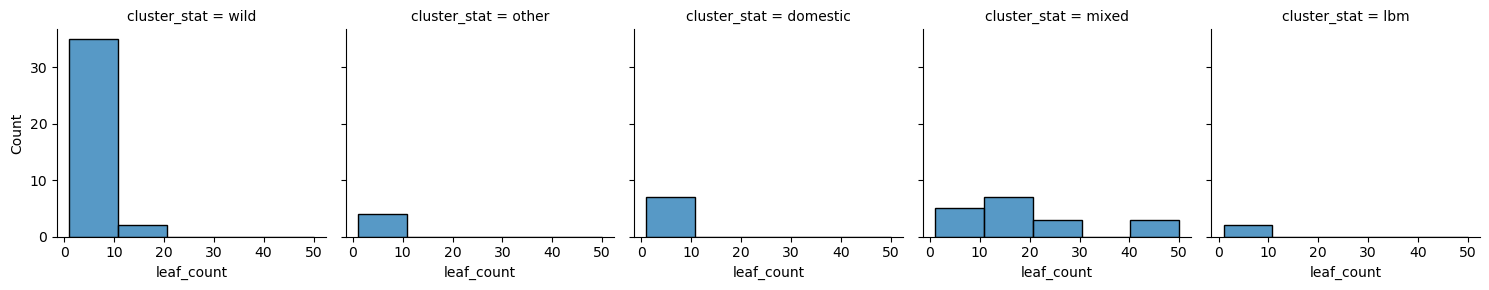

In [130]:
import seaborn as sns
# sns.histplot(data=pa_clust, x="leaf_count", hue="cluster_stat", multiple='layer')
sns.displot(
    pa_clust, x="leaf_count", col="cluster_stat",
    binwidth=10, height=3, facet_kws=dict(margin_titles=True),
)

In [155]:
pa_clust

,subtree_name,leaf_count,origin_date,origin,PA_status,border_states,source_tree,last_tip_date,subtree_duration_days,earliest_tip,cluster_stat,days_to_earliest_tip
0,PA_0,1,2022-09-22,non-border,PA,PA,h5nx_ha_big,2023-04-16,206,2023-04-16,wild,206
1,PA_1,1,2022-11-03,border,PA,PA,h5nx_ha_big,2023-03-13,130,2023-03-13,wild,130
2,PA_10,1,2022-08-11,non-border,PA,PA,h5nx_ha_big,2022-10-31,81,2022-09-28,domestic,48
3,PA_11,1,2022-08-18,non-border,PA,PA,h5nx_ha_big,2022-10-13,56,2022-10-13,other,56
4,PA_12,2,2022-11-20,non-border,PA,PA,h5nx_ha_big,2023-01-09,50,2022-10-10,wild,-41
5,PA_13,1,2022-06-26,non-border,PA,PA,h5nx_ha_big,2022-09-19,85,2022-09-19,other,85
6,PA_14,5,2022-07-26,non-border,PA,PA,h5nx_ha_big,2022-11-09,106,2022-10-19,other,85
7,PA_15,1,2022-12-15,non-border,PA,PA,h5nx_ha_big,2022-12-19,4,2022-12-19,wild,4
8,PA_16,1,2022-02-28,non-border,PA,PA,h5nx_ha_big,2022-04-27,58,2022-04-27,wild,58
9,PA_17,1,2022-02-28,non-border,PA,PA,h5nx_ha_big,2022-04-20,51,2022-04-20,wild,51


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_61408/2780277790.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(
/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_61408/2780277790.py:18: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_61408/2780277790.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


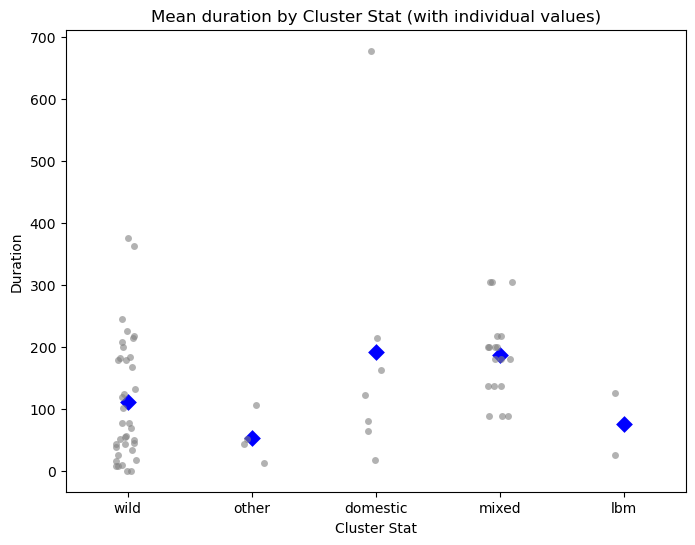

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# base figure
plt.figure(figsize=(8, 6))

# 1. individual points (jitter helps spread them out)
sns.stripplot(
    data=pa_clust,
    x="cluster_stat",
    y="subtree_duration_days",
    jitter=True,
    alpha=0.6,
    color="gray"
)

# 2. mean values as bigger markers
sns.pointplot(
    data=pa_clust,
    x="cluster_stat",
    y="subtree_duration_days",
    estimator="mean",
    ci=None,
    join=False,
    markers="D",   # diamond marker for mean
    color="blue",
    scale=1.2
)

plt.title("Mean duration by Cluster Stat (with individual values)")
plt.ylabel("Duration")
plt.xlabel("Cluster Stat")
plt.show()


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_36613/2077737905.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


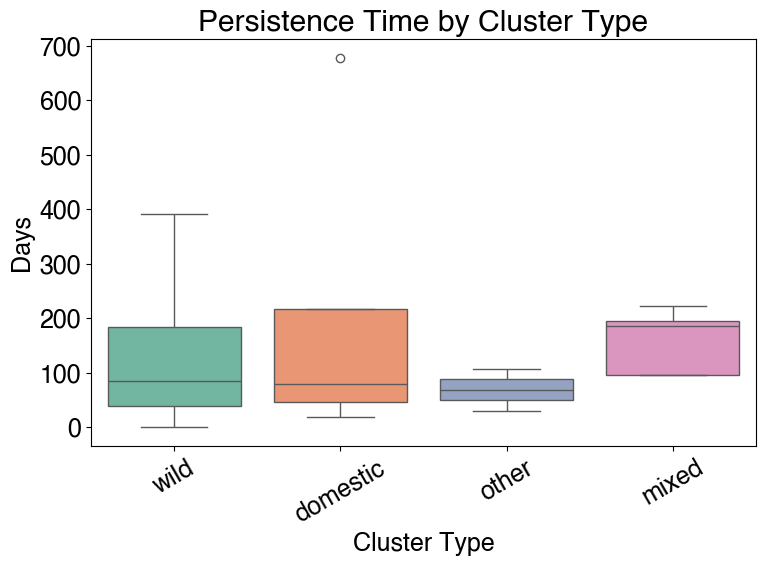

In [83]:
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text', usetex='false') 
plt.rcParams.update({'font.size': 18})
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Boxplot
sns.boxplot(
    data=pa_clust,
    x="cluster_stat",          # replace with your column name for cluster type
    y="subtree_duration_days",
    palette="Set2"
)

# # Optional: overlay individual points
# sns.stripplot(
#     data=pa_clust,
#     x="cluster_stat",
#     y="days_to_earliest_tip",
#     color="k",
#     size=4,
#     jitter=True,
#     alpha=0.5
# )

plt.title("Persistence Time by Cluster Type")
plt.ylabel("Days")
plt.xlabel("Cluster Type")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_61408/4033474987.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(
/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_61408/4033474987.py:18: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_61408/4033474987.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


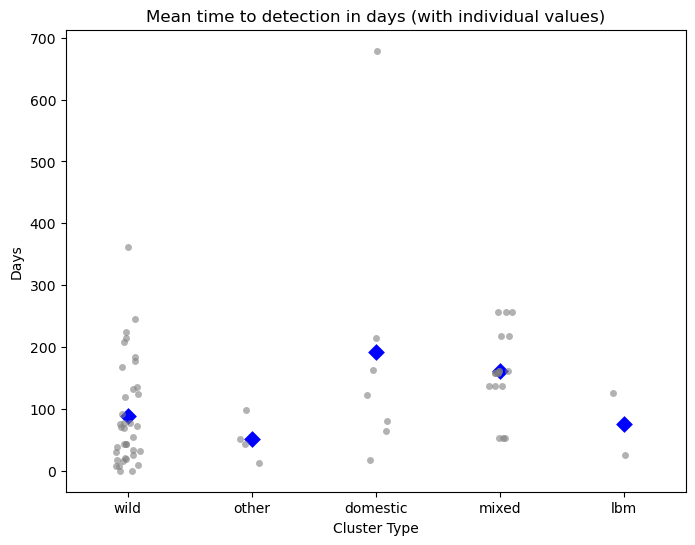

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

# base figure
plt.figure(figsize=(8, 6))

# 1. individual points (jitter helps spread them out)
sns.stripplot(
    data=pa_clust,
    x="cluster_stat",
    y="days_to_earliest_tip",
    jitter=True,
    alpha=0.6,
    color="gray"
)

# 2. mean values as bigger markers
sns.pointplot(
    data=pa_clust,
    x="cluster_stat",
    y="days_to_earliest_tip",
    estimator="mean",
    ci=None,
    join=False,
    markers="D",   # diamond marker for mean
    color="blue",
    scale=1.2
)

plt.title("Mean time to detection in days (with individual values)")
plt.ylabel("Days")
plt.xlabel("Cluster Type")
plt.show()


/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_36613/4158242170.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


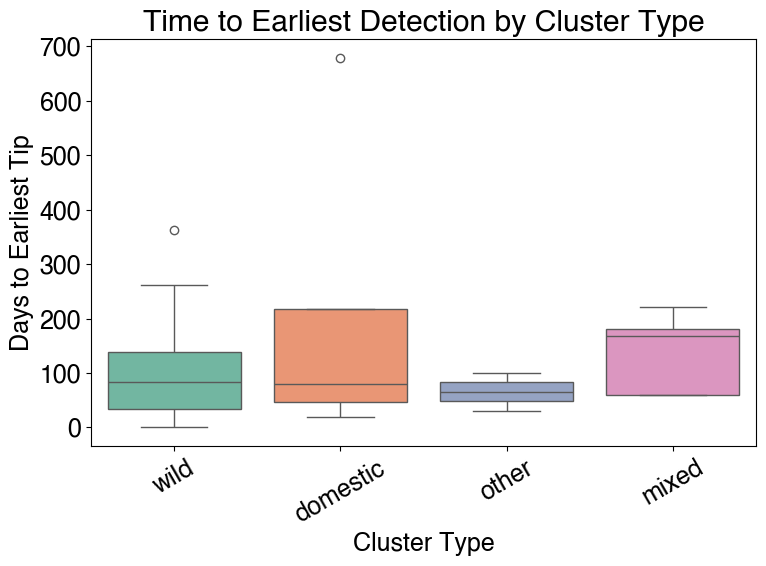

In [85]:
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text', usetex='false') 
plt.rcParams.update({'font.size': 18})
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Boxplot
sns.boxplot(
    data=pa_clust,
    x="cluster_stat",          # replace with your column name for cluster type
    y="days_to_earliest_tip",
    palette="Set2"
)

# # Optional: overlay individual points
# sns.stripplot(
#     data=pa_clust,
#     x="cluster_stat",
#     y="days_to_earliest_tip",
#     color="k",
#     size=4,
#     jitter=True,
#     alpha=0.5
# )

plt.title("Time to Earliest Detection by Cluster Type")
plt.ylabel("Days to Earliest Tip")
plt.xlabel("Cluster Type")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [86]:
combined_transitions_df

,Transition,Count,source_tree
0,ancestor_non-border,1,1017_h5nx_ha
1,non-border_border,134,1017_h5nx_ha
2,non-border_PA,33,1017_h5nx_ha
3,border_PA,18,1017_h5nx_ha
4,border_non-border,49,1017_h5nx_ha
5,PA_non-border,4,1017_h5nx_ha
6,PA_border,10,1017_h5nx_ha


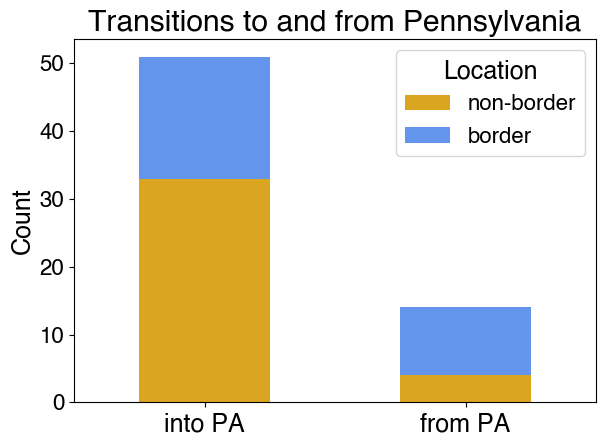

In [87]:
import matplotlib.pyplot as plt
import pandas as pd

# Original data
data = {
    'non-border_PA': 33,
    'border_PA':18,
    'PA_border':10,
    'PA_non-border':4
}

# Categorize into groups
grouped_data = {
    'into PA': {
        'non-border': data.get('non-border_PA', 0),
        'border': data.get('border_PA', 0)
    },
    'from PA': {
        'non-border': data.get('PA_non-border', 0),
        'border': data.get('PA_border', 0)
    }
}

# Convert to DataFrame for easier plotting
df = pd.DataFrame(grouped_data)

# Plot
ax = df.T.plot(kind='bar', stacked=True, color=['goldenrod', 'cornflowerblue'])

# Labeling
ax.set_ylabel("Count", fontsize=18)
ax.set_title("Transitions to and from Pennsylvania")
ax.legend(title="Location", fontsize=16)
plt.xticks(rotation=0, fontsize=18)
plt.yticks(fontsize=16)
plt.tight_layout()

plt.savefig('../phylo_scripts_analysis/output_figs/2025_11_03-transitions_plot_PA_bigha.png', format='png')

plt.show()


In [111]:
pwd

'/Users/asjaeger/Desktop/project_source/hpai_PA/phylo/analysis_phylo'

In [32]:
df_duration

,tree,transition_type,origin_date,latest_tip_date,subtree_duration_days
0,treeh5nx_ha,non-border_PA,2023.707,2024.122,151.6
1,treeh5nx_ha,non-border_PA,2023.791,2024.122,120.9
2,treeh5nx_ha,non-border_PA,2023.869,2024.092,81.5
3,treeh5nx_ha,non-border_PA,2023.875,2024.089,78.2
4,treeh5nx_ha,non-border_PA,2023.798,2024.083,104.1
...,...,...,...,...,...
362,treeh5nx_ha_big,PA_non-border,2022.813,2023.185,135.9
363,treeh5nx_ha_big,PA_non-border,2023.100,2023.100,0.0
364,treeh5nx_ha_big,PA_non-border,2022.432,2022.495,23.0
365,treeh5nx_ha_big,PA_non-border,2022.219,2022.338,43.5


,origin_trait,tip_trait,count
0,ancestor,non-border,6655
1,non-border,border,1
2,non-border,border,9
3,non-border,border,2
4,non-border,PA,1
...,...,...,...
246,non-border,border,1
247,non-border,border,13
248,border,non-border,32
249,non-border,border,1
